<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Project Objectives**

## **(I) Problem Definition**

Using an ensamble ML to predict BTC per forward log return at a horizon to be determined after EDA

In [1]:
# Install packages
# !pip install -q yfinance
!pip -q install arch
!pip -q install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.1 MB/s eta 0:00:00


In [2]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf

# Operational packages
import os, io, sys, zipfile
import time
import requests
import importlib
from datetime import datetime
from pathlib import Path
from google.colab import userdata

# stat packages
from arch import arch_model

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

# load the api keys
gn_api = userdata.get("gn_api")

Mounted at /content/drive


## **(II) Data Extraction, Data Cleaning and Point-in-Time Alignment**

This section constructs a point-in-time-consistent hourly predictor dataset from four complementary data families. Glassnode is used to capture on-chain valuation, profitability, positioning and market-participant behaviour; centralised-exchange data provide spot and perpetual-market price, volume, funding and microstructure information; Deribit futures supply contract-level term-structure and basis measures; and Yahoo Finance adds broader cross-asset market conditions through equity, volatility, interest-rate and US dollar proxies.

Each source is processed independently through four stages: extraction, data-quality checks, cleaning and point-in-time alignment where required. Only after these steps are complete are the final source files merged on the common UTC hourly index. This ensures that the combined modelling matrix is both operationally clean and consistent with the information that would have been observable at each prediction timestamp.

### Point-in-Time Alignment Policy

Point-in-time alignment is applied separately for each data source according to its timestamp convention, publication timing and data frequency. The following source-level rules are applied during extraction and cleaning so that the files entering the final hourly merge are already aligned to the information available at each modelling timestamp.

| Data source / family | General PIT lag |
|---|---:|
| Glassnode — 1-hour resolution endpoints | \(T+2\) hours |
| Glassnode — 24-hour resolution endpoints | \(T+2\) days |
| Deribit hourly futures data | \(T+1\) hour |
| Cross-asset market data | \(T+1\) day |
| CEX hourly market data | \(T+0\) |

### a) **Glassnode**
<p>
Step 1: Data Extraction
</p>


*   Extract data from 19 glassnode endpoint containing on-chain data
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [11]:
# data extraction from glassnode - on-chain metrics
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

# Data extraction window
start_date = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",            "endpoint": "market/mvrv_z_score",                              "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",              "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum","interval": "1h", "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",    "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",          "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month","interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                            "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",            "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {"a": "BTC", "i": item["interval"], "s": start_unix, "api_key": gn_api}

    # extracting glassnode endpoints with currency label
    if item["currency"] is not None:
        params["c"] = item["currency"]

    response = requests.get(
        f"https://api.glassnode.com/v1/metrics/{item['endpoint']}",
        params=params)

    response.raise_for_status()
    series = pd.DataFrame(response.json())

    # extracting glassnode endpoints with no metric keys
    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        # extracting glassnode endpoints with metric keys
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    series = series.set_index("timestamp")[[item["name"]]]

    glassnode_series.append(series)

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")

df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480738.547683
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


<p>
Step 2: Data Quality Check
</p>


In [16]:
# Glassnode data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_glassnode.shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"Duplicate timestamps: {df_glassnode.index.duplicated().sum()}")

glassnode_check_cols = ["pct_supply_profit", "oi_perp", "liq_long", "liq_short", "opt_skew_1w", "opt_skew_1m", "atm_iv_1m", "inv_loss_seller"]

gn_nan_summary = []

for col in glassnode_check_cols:
    series = df_glassnode[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    gn_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

gn_nan_summary = pd.DataFrame(gn_nan_summary).set_index("series")

print(f"Total missing values across checked endpoints: {int(gn_nan_summary['missing_count'].sum())}")
print(f"Endpoints with internal NaN values: {int(gn_nan_summary['has_internal_nan'].sum())}")

gn_nan_summary

Shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked endpoints: 75814
Endpoints with internal NaN values: 2


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
pct_supply_profit,168,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,168,True
oi_perp,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_long,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_short,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1w,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
atm_iv_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
inv_loss_seller,62974,2019-01-01 00:00:00+00:00,2026-06-30 00:00:00+00:00,65689,62951,True


Observations from this data quality check:


*   oi_perp, liq_long, liq_short, opt_skew_1w, opt_skew_1m, atm_iv_1m - has start date later than 2019-01-01 data extraction date. This issue will be addressed at final data merge, where realistic data start date will be determined
*   inv_loss_seller - suspected internal nan is due to endpoint is only available at 24 hour resolution. Further investigation required
*   pct_supply_profit - further investigation required to determine the treatment of the 168 missing bars

<p>
Step 3: Data Cleaning
</p>


3.1: inv_loss_seller

This is a native 24 hour resolution endpoint, we'll first examine if there are nan based on the endpoint's original resolution

In [7]:
# Native 24-hour series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Check spacing between consecutive observations
daily_spacing = inv_loss_daily.index.to_series().diff()

print("Observation count:", len(inv_loss_daily))
print("First valid timestamp:", inv_loss_daily.index.min())
print("Last valid timestamp:", inv_loss_daily.index.max())

# check for gaps in data series
irregular_spacing = daily_spacing[daily_spacing.ne(pd.Timedelta(days=1)) & daily_spacing.notna()]

if irregular_spacing.empty:
    print("All native observations are spaced exactly 24 hours apart.")
else:
    print("Irregular native-frequency spacing detected:")
    print(irregular_spacing)

Observation count: 2738
First valid timestamp: 2019-01-01 00:00:00+00:00
Last valid timestamp: 2026-06-30 00:00:00+00:00
All native observations are spaced exactly 24 hours apart.


We can determine there is no missing data within this series, however, for this endpoint to be able to merge with other 1 hour resolution based endpoint, clean up is still required by applying point-in-time alignment policy and forward filling empty cells.

In [18]:
# Separate and PIT-align the daily inverse-loss endpoint
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()
inv_loss_daily_lagged = inv_loss_daily.shift(2)
inv_loss_daily_1h_pit_aligned = inv_loss_daily_lagged.reindex(df_glassnode.index).ffill().to_frame("inv_loss_seller")

# Remove the daily endpoint from the native 1-hour Glassnode dataset
df_glassnode = df_glassnode.drop(columns=["inv_loss_seller"])

# Save the native hourly endpoints and the separately PIT-aligned daily endpoint
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")
inv_loss_daily_1h_pit_aligned.to_csv("inv_loss_daily_1h_pit_aligned.csv", index_label="timestamp")

# Validation
assert "inv_loss_seller" not in df_glassnode.columns
assert inv_loss_daily_1h_pit_aligned.columns.tolist() == ["inv_loss_seller"]
assert inv_loss_daily_1h_pit_aligned.index.equals(df_glassnode.index)
assert not inv_loss_daily_1h_pit_aligned.index.duplicated().any()

print(f"Native hourly Glassnode shape: {df_glassnode.shape}")
print(f"Inverse-loss hourly shape: {inv_loss_daily_1h_pit_aligned.shape}")
print(f"Inverse-loss missing values after conversion: {inv_loss_daily_1h_pit_aligned['inv_loss_seller'].isna().sum()}")

Native hourly Glassnode shape: (65712, 18)
Inverse-loss hourly shape: (65712, 1)
Inverse-loss missing values after conversion: 50


Step 3.2: pct_supply_profit

Previous data audit is showing we are missing 168 bars of data, which roughly aggregates to 7 calendar days. Our initial point of investigation is to understand the pattern of the missing data

In [19]:
# Audit missing timestamps within Percent Supply in Profit
col = "pct_supply_profit"
pct_supply_missing_timestamps = df_glassnode.index[df_glassnode[col].isna()]

print(f"Missing bars: {len(pct_supply_missing_timestamps)}")
display(pd.DataFrame({"missing_timestamp": pct_supply_missing_timestamps}))

Missing bars: 168


,missing_timestamp
0,2026-03-29 00:00:00+00:00
1,2026-03-29 01:00:00+00:00
2,2026-03-29 02:00:00+00:00
3,2026-03-29 03:00:00+00:00
4,2026-03-29 04:00:00+00:00
...,...
163,2026-04-04 19:00:00+00:00
164,2026-04-04 20:00:00+00:00
165,2026-04-04 21:00:00+00:00
166,2026-04-04 22:00:00+00:00


Examining the nan pattern, this is one contiguous 168-hour vendor blackout from 29 March to 4 April 2026.

*   Simple ffill is rejected without further investigation, as this is a full 7 calendar day of missing bars, and on a 1 hour resolution data series, this is a risk of distorting the data
*   Simple linear interpolation is also rejected before further investigation as we are unsure of the data relationship and shape, this method may also introduce look-ahead bias.

Further investigative work will be done to determine what kind of reconstruction methods are available, or if the data series whould be dropped as a feature. As this series examines percentage profits to BTC, we will first examine if the relationship between the 2 contains identifiable trend which we can mirror for filling the nans.

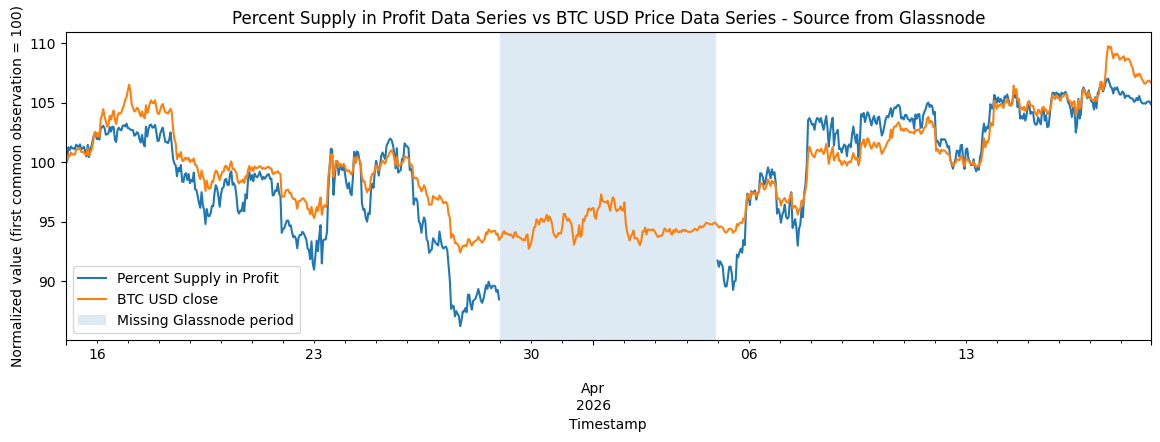

In [25]:
# Comparison window around the missing timestamps
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode for comparison
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine and normalize the two series
comparison = pd.concat([df_glassnode["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common = comparison.dropna()
normalized = comparison.divide(common.iloc[0]).multiply(100)

# Plot
ax = normalized.plot(figsize=(14, 4), title="Percent Supply in Profit Data Series vs BTC USD Price Data Series - Source from Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Missing Glassnode period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit", "BTC USD close", "Missing Glassnode period"])
plt.show()

The Percent Supply in Profit series and BTC price both fluctuate materially around the missing interval, there is no stable trend to justfiy just mirroring. Next step is to identify if we can rebuild the data series in an alternative manner.

**Percent Supply in Profit: Calculation methodology and proposed treatment**

Glassnode’s supply/profit_relative metric is calculated based on BTC supply currently in profit divided by circulating supply. The seven-day outage is caused by the hourly supply/profit_sum numerator, and the corresponding loss-side of the series being unavailable, supply/current remains complete. This determines the missing hourly values cannot be reconstructed from the 1-hour component endpoints.

The same supply/profit_relative metric remains fully populated though at 24-hour resolution during the affected week. We will therefore use the daily series to re-create a daily-resolution reconstruction of the same metric, but it does have limitation as it loses intraday nuances.

Our methodology is to reconstruct the economic series at its observation timestamp, and then apply PIT availability rules afterward.

In [26]:
# Reconstruct Percent Supply in Profit using the complete 24-hour version of the same metric
pct_supply_col = "pct_supply_profit"
pct_supply_missing_mask = df_glassnode[pct_supply_col].isna()
pct_supply_original = df_glassnode[pct_supply_col].copy()

params = {"a": "BTC", "i": "24h", "s": int(df_glassnode.index.min().timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/supply/profit_relative", params=params)
response.raise_for_status()

pct_supply_daily = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": pct_supply_col})
pct_supply_daily["timestamp"] = pd.to_datetime(pct_supply_daily["timestamp"], unit="s", utc=True)
pct_supply_daily = pct_supply_daily.set_index("timestamp")[[pct_supply_col]].sort_index()
pct_supply_daily = pct_supply_daily.loc[~pct_supply_daily.index.duplicated(keep="first")]
pct_supply_daily = pct_supply_daily.loc[df_glassnode.index.min().floor("D"):df_glassnode.index.max().ceil("D")]

# Expand the daily series to the common hourly index
pct_supply_daily_1h = pct_supply_daily.reindex(df_glassnode.index).ffill()

# Replace only missing native-hourly observations
pct_supply_profit_1h_clean = pct_supply_original.to_frame()
pct_supply_profit_1h_clean.loc[pct_supply_missing_mask, pct_supply_col] = pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col]
pct_supply_profit_1h_clean["daily_patch_flag"] = pct_supply_missing_mask.astype(int)

# Validation
valid_native_mask = ~pct_supply_missing_mask
unchanged_native = pct_supply_profit_1h_clean.loc[valid_native_mask, pct_supply_col].equals(pct_supply_original.loc[valid_native_mask])

assert int(pct_supply_missing_mask.sum()) == 168
assert pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col].notna().all()
assert pct_supply_profit_1h_clean[pct_supply_col].notna().all()
assert int(pct_supply_profit_1h_clean["daily_patch_flag"].sum()) == 168
assert unchanged_native, "Valid native-hourly observations were altered."

pct_supply_profit_1h_clean.to_csv("pct_supply_profit_1h_clean.csv", index_label="timestamp")

print(f"Native hourly missing bars: {int(pct_supply_missing_mask.sum())}")
print(f"Daily observations used: {pct_supply_daily.loc[pct_supply_missing_timestamps.min().floor('D'):pct_supply_missing_timestamps.max().floor('D')].shape[0]}")
print(f"Hourly bars patched: {int(pct_supply_profit_1h_clean['daily_patch_flag'].sum())}")
print(f"Missing values after reconstruction: {int(pct_supply_profit_1h_clean[pct_supply_col].isna().sum())}")
print(f"Valid native-hourly observations unchanged: {unchanged_native}")
print("Saved reconstructed series to: pct_supply_profit_1h_clean.csv")

Native hourly missing bars: 168
Daily observations used: 7
Hourly bars patched: 168
Missing values after reconstruction: 0
Valid native-hourly observations unchanged: True
Saved reconstructed series to: pct_supply_profit_1h_clean.csv


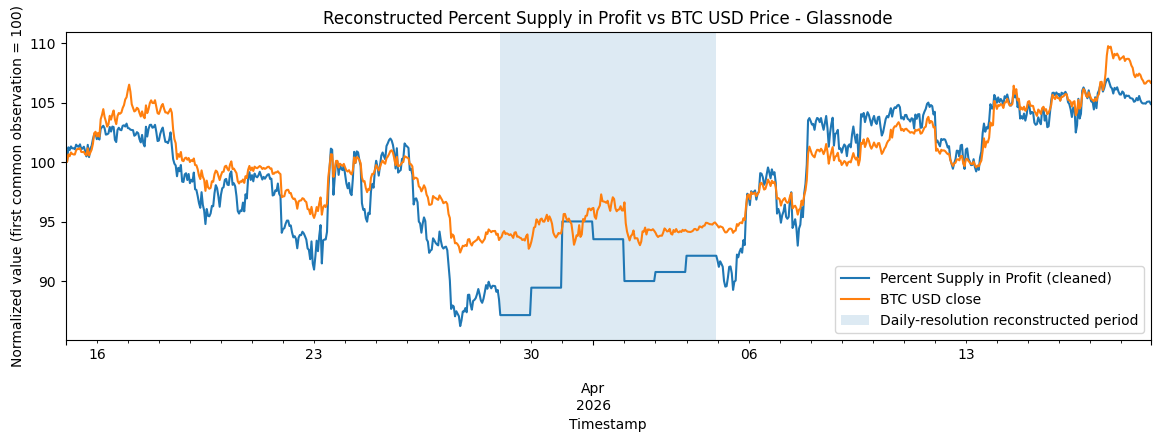

In [28]:
# Plot the reconstructed Percent Supply in Profit series against BTC price
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine the cleaned series with BTC price and normalize both to 100
comparison_clean = pd.concat([pct_supply_profit_1h_clean["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common_start = comparison_clean.dropna().iloc[0]
normalized_clean = comparison_clean.divide(common_start).multiply(100)

# Plot and retain the shaded reconstructed interval
ax = normalized_clean.plot(figsize=(14, 4), title="Reconstructed Percent Supply in Profit vs BTC USD Price - Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Daily-resolution reconstructed period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit (cleaned)", "BTC USD close", "Daily-resolution reconstructed period"])

plt.show()

<p>
Step 4: Merging all Glassnode Endpoints in a Point-In-Time Aligned Data File
</p>


In [29]:
# Load the cleaned native-timestamp Glassnode files
glassnode_raw = pd.read_csv("raw_glassnode.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
pct_supply_clean = pd.read_csv("pct_supply_profit_1h_clean.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
inv_loss_pit = pd.read_csv("inv_loss_daily_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

# Standardize all indices to UTC
glassnode_raw.index = pd.to_datetime(glassnode_raw.index, utc=True)
pct_supply_clean.index = pd.to_datetime(pct_supply_clean.index, utc=True)
inv_loss_pit.index = pd.to_datetime(inv_loss_pit.index, utc=True)

# Remove separately treated endpoints from the raw Glassnode file
glassnode_raw = glassnode_raw.drop(columns=["pct_supply_profit", "inv_loss_seller"], errors="ignore")

# Retain only the reconstructed Percent Supply in Profit values
pct_supply_clean = pct_supply_clean[["pct_supply_profit"]]

# Validate indices before combining
assert glassnode_raw.index.equals(pct_supply_clean.index), "Glassnode and Percent Supply in Profit indices do not match."
assert glassnode_raw.index.equals(inv_loss_pit.index), "Glassnode and inverse-loss indices do not match."
assert not glassnode_raw.index.duplicated().any(), "Duplicate timestamps found in raw Glassnode data."
assert not pct_supply_clean.index.duplicated().any(), "Duplicate timestamps found in Percent Supply in Profit data."
assert not inv_loss_pit.index.duplicated().any(), "Duplicate timestamps found in inverse-loss data."

# Merge the cleaned Percent Supply in Profit series into the native hourly Glassnode dataset
glassnode_1h_clean = glassnode_raw.join(pct_supply_clean, how="left")

# Apply the two-hour PIT lag to all completed 1-hour Glassnode endpoints
glassnode_1h_pit_aligned = glassnode_1h_clean.shift(2)

# Merge the separately two-day-lagged and hourly-expanded inverse-loss endpoint
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(inv_loss_pit[["inv_loss_seller"]], how="left")

# Final validation
assert glassnode_1h_pit_aligned.index.is_monotonic_increasing, "Final Glassnode index is not sorted."
assert not glassnode_1h_pit_aligned.index.duplicated().any(), "Duplicate timestamps found in final Glassnode data."
assert "pct_supply_profit" in glassnode_1h_pit_aligned.columns, "Percent Supply in Profit is missing."
assert "inv_loss_seller" in glassnode_1h_pit_aligned.columns, "Inverse Loss Seller is missing."
assert glassnode_1h_pit_aligned.columns.duplicated().sum() == 0, "Duplicate column names found."

# Save the final PIT-aligned Glassnode dataset
glassnode_1h_pit_aligned.to_csv("glassnode_1h_pit_aligned.csv", index_label="timestamp")

print(f"Final shape: {glassnode_1h_pit_aligned.shape}")
print(f"Date range: {glassnode_1h_pit_aligned.index.min()} to {glassnode_1h_pit_aligned.index.max()}")
print(f"Duplicate timestamps: {glassnode_1h_pit_aligned.index.duplicated().sum()}")
print(f"Duplicate columns: {glassnode_1h_pit_aligned.columns.duplicated().sum()}")
print(f"Percent Supply in Profit missing values: {glassnode_1h_pit_aligned['pct_supply_profit'].isna().sum()}")
print(f"Inverse Loss Seller missing values: {glassnode_1h_pit_aligned['inv_loss_seller'].isna().sum()}")
print("Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv")

Final shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicate columns: 0
Percent Supply in Profit missing values: 2
Inverse Loss Seller missing values: 50
Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv


### b) **US Dollar Index, S&P500 Index, VIX, 10 Year US Treasury Yield**

<p>
Step 1: Data Extraction
</p>


*   Extract cross-asset benchmark data from yfinance
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [30]:
# extract cross asset data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

cross_asset_tickers = {
    "DX-Y.NYB": "dxy",
    "^GSPC": "spx",
    "^VIX": "vix",
    "^TNX": "us10y"}

df_cross_asset = (yf.download(list(cross_asset_tickers),
     start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False)["Close"]
    .rename(columns=cross_asset_tickers)
    .sort_index())

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_csv("raw_cross_asset.csv", index_label="timestamp")
df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


<p>
Step 2: Data Quality Check
</p>


In [31]:
# Cross-asset data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset.index.duplicated().sum()}")

cross_asset_check_cols = ["dxy", "spx", "vix", "us10y"]

cross_asset_nan_summary = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    cross_asset_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

cross_asset_nan_summary = pd.DataFrame(cross_asset_nan_summary).set_index("series")

print(f"Total missing values across checked series: {int(cross_asset_nan_summary['missing_count'].sum())}")
print(f"Series with internal NaN values: {int(cross_asset_nan_summary['has_internal_nan'].sum())}")

cross_asset_nan_summary

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked series: 9
Series with internal NaN values: 4


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
dxy,1,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,1,True
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2,True
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True


<p>
Step 3: Data Cleaning
</p>

In here, data cleaning comprises of 2 parts
*   Examining the NaN profile and handling policy
*   Handling real life data delays, ensure there's no look ahead bias/ data leakage. These data are only available at 24hour horizon and market close, so bars needed to be shifted to ensure no look ahead bias



In [32]:
# Isolate every internal NaN timestamp for each investigated cross-asset series
cross_asset_internal_nan_dates = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]
    missing_dates = active_series.index[active_series.isna()]

    for missing_date in missing_dates:
        cross_asset_internal_nan_dates.append({
            "series": col,
            "missing_timestamp": missing_date
        })

cross_asset_internal_nan_dates = pd.DataFrame(cross_asset_internal_nan_dates)

if not cross_asset_internal_nan_dates.empty:
    cross_asset_internal_nan_dates = cross_asset_internal_nan_dates.sort_values(
        ["series", "missing_timestamp"]
    ).reset_index(drop=True)

cross_asset_internal_nan_dates

,series,missing_timestamp
0,dxy,2026-05-25 00:00:00+00:00
1,spx,2025-01-09 00:00:00+00:00
2,spx,2025-05-26 00:00:00+00:00
3,spx,2026-05-25 00:00:00+00:00
4,us10y,2025-01-09 00:00:00+00:00
5,us10y,2025-05-26 00:00:00+00:00
6,us10y,2026-05-25 00:00:00+00:00
7,vix,2025-01-09 00:00:00+00:00
8,vix,2025-05-26 00:00:00+00:00


Missing data are all evolved around 2 specific dates, upon further investigation it suggested that both 9 Jan 2025 and 26 May 2025 were US stock markets were closure, naturally no data is available and the handling policy is just to forward fill the missing data.

In [36]:
# Forward-fill internal missing values in the native daily cross-asset series
df_cross_asset = df_cross_asset.ffill()
print(f"Missing values after forward-fill: {df_cross_asset.isna().sum().sum()}")

Missing values after forward-fill: 0


Step 4: Creating Point-In-Time Aligned Data File

In [37]:
# Apply the T+1-calendar-day PIT lag and expand the daily series to an hourly spine
df_cross_asset_pit_daily = df_cross_asset.copy()
df_cross_asset_pit_daily.index = df_cross_asset_pit_daily.index + pd.Timedelta(days=1)

cross_asset_hourly_index = pd.date_range(
    start=df_cross_asset_pit_daily.index.min(),
    end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"),
    freq="1h")

df_cross_asset_1h_pit = df_cross_asset_pit_daily.reindex(cross_asset_hourly_index).ffill()
df_cross_asset_1h_pit.index.name = "timestamp"

print(f"Shape: {df_cross_asset_1h_pit.shape}")
print(f"Date range: {df_cross_asset_1h_pit.index.min()} to {df_cross_asset_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_cross_asset_1h_pit.isna().sum().sum())}")

df_cross_asset_1h_pit.to_csv("cross_asset_1h_pit_aligned.csv", index_label="timestamp")
df_cross_asset_1h_pit.head()

Shape: (65664, 4)
Date range: 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


Ticker,dxy,spx,us10y,vix
timestamp,,,,
2019-01-03 00:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 01:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 02:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 03:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 04:00:00+00:00,96.82,2510.030029,2.661,23.219999


### c) **CEX Data**

**i) Binance K-line data** </br>

Step 1: Data extraction

In [38]:
# Binance USD-M perpetual-futures kline extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")
kline_columns = ["open_time", "open", "high", "low", "close", "volume", "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]
binance_kline_data = {}

for endpoint in binance_kline_endpoints:
    monthly_frames = []
    months = pd.period_range(start=endpoint["start_month"], end="2026-06", freq="M")

    for month in months:
        month = str(month)
        url = f"https://data.binance.vision/data/futures/um/monthly/klines/{endpoint['symbol']}/{endpoint['interval']}/{endpoint['symbol']}-{endpoint['interval']}-{month}.zip"
        response = requests.get(url, timeout=30)

        if response.status_code == 404:
            print(f"No archive found: {endpoint['symbol']} {month}")
            continue

        response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            with archive.open(archive.namelist()[0]) as file:
                monthly_frames.append(pd.read_csv(file, header=None, names=kline_columns))

    if not monthly_frames:
        raise ValueError(f"No kline data returned for {endpoint['symbol']}")

    asset_data = pd.concat(monthly_frames, ignore_index=True)
    open_time_numeric = pd.to_numeric(asset_data["open_time"], errors="coerce")
    open_time_ms = open_time_numeric.where(open_time_numeric < 1e14, open_time_numeric / 1000)
    asset_data["timestamp"] = pd.to_datetime(open_time_ms, unit="ms", utc=True, errors="coerce")

    invalid_timestamp_rows = int(asset_data["timestamp"].isna().sum())
    asset_data = asset_data.dropna(subset=["timestamp"])
    asset_data = asset_data.loc[asset_data["timestamp"] < analysis_end]
    asset_data = asset_data.drop(columns=["open_time", "close_time", "ignore"])

    duplicate_rows = int(asset_data.duplicated().sum())
    asset_data = asset_data.drop_duplicates()
    asset_data = asset_data.set_index("timestamp").sort_index()

    duplicated_timestamp_rows = int(asset_data.index.duplicated(keep=False).sum())
    asset_data = asset_data.loc[~asset_data.index.duplicated(keep=False)]
    asset_data = asset_data.apply(pd.to_numeric, errors="coerce")
    asset_data.columns = [f"{endpoint['name']}_{col}" for col in asset_data.columns]

    print(f"{endpoint['symbol']} invalid timestamp rows removed: {invalid_timestamp_rows}")
    print(f"{endpoint['symbol']} exact duplicate rows removed: {duplicate_rows}")
    print(f"{endpoint['symbol']} duplicated timestamp rows removed: {duplicated_timestamp_rows}")

    binance_kline_data[endpoint["name"]] = asset_data

df_binance_klines = pd.concat([binance_kline_data["btc"], binance_kline_data["eth"]], axis=1).sort_index()
df_binance_klines.to_csv("raw_binance_klines.csv", index_label="timestamp")

df_binance_klines.head()

No archive found: BTCUSDT 2019-09
No archive found: BTCUSDT 2019-10
No archive found: BTCUSDT 2019-11
No archive found: BTCUSDT 2019-12
BTCUSDT invalid timestamp rows removed: 54
BTCUSDT exact duplicate rows removed: 0
BTCUSDT duplicated timestamp rows removed: 0
No archive found: ETHUSDT 2019-11
No archive found: ETHUSDT 2019-12
ETHUSDT invalid timestamp rows removed: 54
ETHUSDT exact duplicate rows removed: 0
ETHUSDT duplicated timestamp rows removed: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume
timestamp,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,129.12,128.62,128.82,14947.691,1.925644e+06,1249,7707.625,9.928838e+05
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,130.61,128.76,130.57,34755.256,4.514484e+06,3116,19928.267,2.588555e+06
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,130.97,130.30,130.80,21864.946,2.857378e+06,1807,10299.172,1.345962e+06
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,130.82,129.88,130.09,16823.171,2.190835e+06,1448,7580.536,9.869013e+05
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,130.63,130.09,130.15,11357.239,1.480319e+06,1065,5204.925,6.783015e+05


<p>
Step 2: Data Quality Check
</p>


In [39]:
# Binance kline data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"Duplicate timestamps: {df_binance_klines.index.duplicated().sum()}")

binance_kline_check_cols = df_binance_klines.columns.tolist()
binance_kline_nan_summary = []

for col in binance_kline_check_cols:
    series = df_binance_klines[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_kline_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_kline_nan_summary = pd.DataFrame(binance_kline_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_kline_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_kline_nan_summary['has_internal_nan'].sum())}")

binance_kline_nan_summary

Shape: (56952, 18)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_num_trades,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


ii) Binance perpetual premium-index data </br>

Step 1: Data extraction

Binance perpetual premium-index data had data quality issues retrieving from binance archive. There's a version available and usable. However, it requires futures REST access and was unavailable from the hosted Google Colab runtime due to an HTTP 451 geographic/IP restriction. Therefore, the premium-index extraction was implemented as a standalone reproducible Python module and executed once from an unrestricted local network. The resulting raw CSV was versioned and frozen for the submitted analysis. The notebook imports the extraction module for code transparency and validates the saved dataset’s schema, coverage, timestamp continuity and integrity before use.

In [49]:
# Load and standardize the Binance BTC perpetual premium-index series

raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)
premium_source_path = f"{raw_data_dir}/raw_binance_perp_premium.csv"

df_binance_premium = pd.read_csv(premium_source_path, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium.index = pd.to_datetime(df_binance_premium.index, utc=True)

df_binance_premium = df_binance_premium.loc[(df_binance_premium.index >= pd.Timestamp("2020-01-01 00:00:00", tz="UTC")) & (df_binance_premium.index < analysis_end)]

premium_cols = ["btc_perp_premium_open", "btc_perp_premium_high", "btc_perp_premium_low", "btc_perp_premium_close"]
missing_columns = [col for col in premium_cols if col not in df_binance_premium.columns]

if missing_columns: raise ValueError(f"Missing Binance premium-index columns: {missing_columns}")

df_binance_premium = df_binance_premium[premium_cols].apply(pd.to_numeric, errors="coerce")
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

df_binance_premium.head()

,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close
timestamp,,,,
2020-01-01 00:00:00+00:00,-0.000777,-0.000443,-0.001206,-0.000809
2020-01-01 01:00:00+00:00,-0.000818,-0.000100,-0.001015,-0.000801
2020-01-01 02:00:00+00:00,-0.000445,-0.000445,-0.001063,-0.000554
2020-01-01 03:00:00+00:00,-0.000412,-0.000295,-0.001005,-0.000627
2020-01-01 04:00:00+00:00,-0.000523,-0.000296,-0.000887,-0.000517


<p>
Step 2: Data Quality Check
</p>


In [50]:
# Binance premium-index data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"Duplicate timestamps: {df_binance_premium.index.duplicated().sum()}")

binance_premium_check_cols = df_binance_premium.columns.tolist()
binance_premium_nan_summary = []

for col in binance_premium_check_cols:
    series = df_binance_premium[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_premium_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_premium_nan_summary = pd.DataFrame(binance_premium_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_premium_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_premium_nan_summary['has_internal_nan'].sum())}")

binance_premium_nan_summary

Shape: (56951, 4)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_perp_premium_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False


In [51]:
# Check for missing hourly timestamps in the Binance premium-index series
premium_expected_index = pd.date_range(start=df_binance_premium.index.min(), end=df_binance_premium.index.max(), freq="h")
premium_missing_timestamps = premium_expected_index.difference(df_binance_premium.index)

print(f"Missing hourly timestamps: {len(premium_missing_timestamps)}")
premium_missing_timestamps

Missing hourly timestamps: 1


DatetimeIndex(['2020-12-01 23:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')

<p>
Step 3: Data Cleaning
</p>

In [52]:
# Forward-fill the single missing Binance premium-index hour

premium_full_index = pd.date_range(start=df_binance_premium.index.min(), end=analysis_end - pd.Timedelta(hours=1), freq="h")

df_binance_premium = df_binance_premium.reindex(premium_full_index)
df_binance_premium.index.name = "timestamp"

missing_before = int(df_binance_premium.isna().all(axis=1).sum())
df_binance_premium = df_binance_premium.ffill(limit=1)
missing_after = int(df_binance_premium.isna().all(axis=1).sum())

print(f"Missing premium rows before forward-fill: {missing_before}")
print(f"Missing premium rows after forward-fill: {missing_after}")

Missing premium rows before forward-fill: 1
Missing premium rows after forward-fill: 0


In [53]:
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

iii) Binance funding rate endpoint </br>

Step 1: Data extraction

In [54]:
# Binance BTC funding-rate extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_funding_endpoint = {"name": "btc_funding", "symbol": "BTCUSDT", "start_month": "2019-09"}
funding_monthly_frames = []
funding_months = pd.period_range(start=binance_funding_endpoint["start_month"], end="2026-06", freq="M")

for month in funding_months:
    month = str(month)
    url = f"https://data.binance.vision/data/futures/um/monthly/fundingRate/{binance_funding_endpoint['symbol']}/{binance_funding_endpoint['symbol']}-fundingRate-{month}.zip"
    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: {binance_funding_endpoint['symbol']} funding {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        with archive.open(archive.namelist()[0]) as file:
            funding_monthly_frames.append(pd.read_csv(file))

if not funding_monthly_frames: raise ValueError("No Binance BTC funding-rate data returned")

df_binance_funding = pd.concat(funding_monthly_frames, ignore_index=True)
df_binance_funding.columns = [str(col).strip() for col in df_binance_funding.columns]
df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_binance_funding["timestamp"].isna().sum())
df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])
df_binance_funding = df_binance_funding.loc[df_binance_funding["timestamp"] < analysis_end]
df_binance_funding = df_binance_funding.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_binance_funding.index.duplicated(keep=False).sum())
df_binance_funding = df_binance_funding.loc[~df_binance_funding.index.duplicated(keep=False)]

df_binance_funding = df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"})
df_binance_funding["btc_funding"] = pd.to_numeric(df_binance_funding["btc_funding"], errors="coerce")

print(f"BTC funding invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"BTC funding duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_binance_funding.to_csv("raw_binance_funding.csv", index_label="timestamp")
df_binance_funding.head()

No archive found: BTCUSDT funding 2019-09
No archive found: BTCUSDT funding 2019-10
No archive found: BTCUSDT funding 2019-11
No archive found: BTCUSDT funding 2019-12
BTC funding invalid timestamp rows removed: 0
BTC funding duplicated timestamp rows removed: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


<p>
Step 2: Data Quality Check
</p>


In [55]:
# Binance funding-rate data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding.index.duplicated().sum()}")

binance_funding_check_cols = df_binance_funding.columns.tolist()
binance_funding_nan_summary = []

for col in binance_funding_check_cols:
    series = df_binance_funding[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_funding_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_funding_nan_summary = pd.DataFrame(binance_funding_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_funding_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_funding_nan_summary['has_internal_nan'].sum())}")
binance_funding_nan_summary

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_funding,0,2020-01-01 00:00:00+00:00,2026-06-30 16:00:00.005000+00:00,7119,0,False


<p>
Step 3: Data Cleaning
</p>

There are no missing value to be handled in this data series, however the initial header display is showing an odd index which requires investigation/ cleaning - 2020-01-02 00:00:00.002000+00:00



In [56]:
# Find funding timestamps that are not exactly aligned to the hour
funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [57]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [58]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


<p>
Step 4: Creating Point-In-Time Aligned Data File
</p>

BTC funding rate settles every 8 hours, as such we need to transform this series into a point-in-time aligned data towards the one hour resolution level.



In [59]:
# Expand the T+0 Binance funding-rate series from its native 8-hour cadence to an hourly spine

funding_hourly_index = pd.date_range(start=df_binance_funding.index.min(), end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"), freq="1h")

df_binance_funding_1h_pit = df_binance_funding.reindex(funding_hourly_index).ffill()
df_binance_funding_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_funding_1h_pit.shape}")
print(f"Date range: {df_binance_funding_1h_pit.index.min()} to {df_binance_funding_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_binance_funding_1h_pit.isna().sum().sum())}")

df_binance_funding_1h_pit.to_csv("binance_funding_1h_pit_aligned.csv", index_label="timestamp")
df_binance_funding_1h_pit.head()

Shape: (56952, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 01:00:00+00:00,-0.000124
2020-01-01 02:00:00+00:00,-0.000124
2020-01-01 03:00:00+00:00,-0.000124
2020-01-01 04:00:00+00:00,-0.000124


**Merge all binance endpoint into a single csv file**

In [60]:
# Load the completed Binance source files for the final source-level merge
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_binance_klines_merge = pd.read_csv("raw_binance_klines.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium_merge = pd.read_csv("raw_binance_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_funding_merge = pd.read_csv("binance_funding_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

for df in [df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge]:
    df.index = pd.to_datetime(df.index, utc=True)

df_binance_1h_pit = pd.concat([df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge], axis=1).sort_index()
df_binance_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_1h_pit.shape}")
print(f"Date range: {df_binance_1h_pit.index.min()} to {df_binance_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_1h_pit.index.duplicated().sum()}")
print(f"Total missing values: {int(df_binance_1h_pit.isna().sum().sum())}")

df_binance_1h_pit.to_csv("binance_1h_pit_aligned.csv", index_label="timestamp")
df_binance_1h_pit.head()

Shape: (56952, 23)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,...,14947.691,1.925644e+06,1249,7707.625,9.928838e+05,-0.000777,-0.000443,-0.001206,-0.000809,-0.000124
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,...,34755.256,4.514484e+06,3116,19928.267,2.588555e+06,-0.000818,-0.000100,-0.001015,-0.000801,-0.000124
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,...,21864.946,2.857378e+06,1807,10299.172,1.345962e+06,-0.000445,-0.000445,-0.001063,-0.000554,-0.000124
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,...,16823.171,2.190835e+06,1448,7580.536,9.869013e+05,-0.000412,-0.000295,-0.001005,-0.000627,-0.000124
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,...,11357.239,1.480319e+06,1065,5204.925,6.783015e+05,-0.000523,-0.000296,-0.000887,-0.000517,-0.000124


**iv) Coinbase BTC USD spot price** </br>

Step 1: Data extraction

In [4]:
# Coinbase BTC-USD hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

coinbase_endpoint = {
    "name": "coinbase_btc_close",
    "url": "https://api.exchange.coinbase.com/products/BTC-USD/candles",
    "granularity": 3600,
    "start": "2019-01-01",
    "end": "2026-07-01"
}

coinbase_rows = []
start_time = pd.Timestamp(coinbase_endpoint["start"], tz="UTC")
end_time = pd.Timestamp(coinbase_endpoint["end"], tz="UTC")

while start_time < end_time:
    window_end = min(start_time + pd.Timedelta(hours=300), end_time)
    params = {"granularity": coinbase_endpoint["granularity"], "start": start_time.isoformat(), "end": window_end.isoformat()}
    response = requests.get(coinbase_endpoint["url"], params=params, headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()
    data = response.json()

    if not isinstance(data, list): raise ValueError(f"Coinbase returned an unexpected response: {data}")

    coinbase_rows.extend(data)
    start_time = window_end
    time.sleep(0.1)

df_coinbase = pd.DataFrame(coinbase_rows, columns=["timestamp", "low", "high", "open", "close", "volume"])
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_coinbase["timestamp"].isna().sum())
df_coinbase = df_coinbase.dropna(subset=["timestamp"])
df_coinbase = df_coinbase.loc[df_coinbase["timestamp"] < end_time]
df_coinbase = df_coinbase.set_index("timestamp").sort_index()

exact_duplicate_rows = int(df_coinbase.duplicated().sum())
df_coinbase = df_coinbase.drop_duplicates()

duplicate_timestamp_rows = int(df_coinbase.index.duplicated(keep=False).sum())
df_coinbase = df_coinbase.loc[~df_coinbase.index.duplicated(keep=False)]

df_coinbase = df_coinbase[["close"]].rename(columns={"close": coinbase_endpoint["name"]})
df_coinbase["coinbase_btc_close"] = pd.to_numeric(df_coinbase["coinbase_btc_close"], errors="coerce")
df_coinbase.index.name = "timestamp"

print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_coinbase.to_csv("coinbase_1h_pit_aligned.csv", index_label="timestamp")
df_coinbase.head()

Invalid timestamp rows removed: 0
Exact duplicate rows removed: 219
Duplicated timestamp rows removed: 0


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


<p>
Step 2: Data Quality Check
</p>


In [5]:
# Coinbase data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"Duplicate timestamps: {df_coinbase.index.duplicated().sum()}")

coinbase_check_cols = df_coinbase.columns.tolist()
coinbase_nan_summary = []

for col in coinbase_check_cols:
    series = df_coinbase[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    coinbase_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

coinbase_nan_summary = pd.DataFrame(coinbase_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(coinbase_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(coinbase_nan_summary['has_internal_nan'].sum())}")
coinbase_nan_summary

Shape: (65693, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
coinbase_btc_close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65693,0,False


v) OKX BTC Perp endpoint </br>

Step 1: Data extraction

In [6]:
# OKX BTC-USDT perpetual hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

okx_endpoint = {"name": "okx_btc_close", "instrument": "BTC-USDT-SWAP", "bar": "1H", "url": "https://www.okx.com/api/v5/market/history-candles", "limit": 300}
okx_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
okx_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

okx_rows = []
after = None

while True:
    params = {"instId": okx_endpoint["instrument"], "bar": okx_endpoint["bar"], "limit": okx_endpoint["limit"]}

    if after is not None: params["after"] = after

    response = requests.get(okx_endpoint["url"], params=params, timeout=30)
    response.raise_for_status()
    body = response.json()

    if body.get("code") != "0": raise ValueError(f"OKX returned code {body.get('code')}: {body.get('msg')}")

    data = body.get("data", [])

    if not data: break

    okx_rows.extend(data)
    oldest_timestamp_ms = min(int(row[0]) for row in data)
    oldest_timestamp = pd.to_datetime(oldest_timestamp_ms, unit="ms", utc=True)

    if oldest_timestamp <= okx_start_time: break

    if after is not None and oldest_timestamp_ms >= int(after):
        print("OKX pagination stopped because the cursor did not move backward.")
        break

    after = oldest_timestamp_ms
    time.sleep(0.1)

if not okx_rows: raise ValueError("No OKX BTC hourly candle data returned")

okx_columns = ["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"]
df_okx = pd.DataFrame(okx_rows, columns=okx_columns)

exact_duplicate_rows = int(df_okx.duplicated().sum())
df_okx = df_okx.drop_duplicates()

df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_okx["timestamp"].isna().sum())
df_okx = df_okx.dropna(subset=["timestamp"])

unconfirmed_rows = int((df_okx["confirm"].astype(str) != "1").sum())
df_okx = df_okx.loc[df_okx["confirm"].astype(str) == "1"]
df_okx = df_okx.loc[(df_okx["timestamp"] >= okx_start_time) & (df_okx["timestamp"] <= okx_end_time)]
df_okx = df_okx.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_okx.index.duplicated(keep=False).sum())
df_okx = df_okx.loc[~df_okx.index.duplicated(keep=False)]

df_okx = df_okx[["close"]].rename(columns={"close": okx_endpoint["name"]})
df_okx["okx_btc_close"] = pd.to_numeric(df_okx["okx_btc_close"], errors="coerce")
df_okx.index.name = "timestamp"

print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Unconfirmed rows removed: {unconfirmed_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_okx.to_csv("okx_1h_pit_aligned.csv", index_label="timestamp")
df_okx.head()

Exact duplicate rows removed: 0
Invalid timestamp rows removed: 0
Unconfirmed rows removed: 1
Duplicated timestamp rows removed: 0


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


<p>
Step 2: Data Quality Check
</p>


In [7]:
# OKX data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"Duplicate timestamps: {df_okx.index.duplicated().sum()}")

okx_check_cols = df_okx.columns.tolist()
okx_nan_summary = []

for col in okx_check_cols:
    series = df_okx[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    okx_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

okx_nan_summary = pd.DataFrame(okx_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(okx_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(okx_nan_summary['has_internal_nan'].sum())}")
okx_nan_summary

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
okx_btc_close,0,2019-12-16 06:00:00+00:00,2026-06-30 23:00:00+00:00,57330,0,False


**vi) Deribit endpoints**</br>

Step 1: Data extraction

In [9]:
# Deribit BTC perpetual and quarterly futures extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

deribit_endpoint = {"name": "deribit_btc_futures", "url": "https://www.deribit.com/api/v2/public/get_tradingview_chart_data", "resolution": "60"}
deribit_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
deribit_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

def last_friday(year, month):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

    while month_end.dayofweek != 4:
        month_end -= pd.Timedelta(days=1)

    return month_end

deribit_instruments = [{
    "instrument_name": "BTC-PERPETUAL",
    "instrument_family": "perpetual",
    "settlement_period": "perpetual",
    "expiration_timestamp_ms": pd.NA,
    "expiration_timestamp": pd.NaT
}]

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:
        expiry_date = last_friday(year, month)
        expiry_timestamp = pd.Timestamp(year=year, month=month, day=expiry_date.day, hour=8, tz="UTC")
        instrument_name = f"BTC-{expiry_timestamp.day}{expiry_timestamp.strftime('%b').upper()}{expiry_timestamp.strftime('%y')}"

        deribit_instruments.append({
            "instrument_name": instrument_name,
            "instrument_family": "quarterly",
            "settlement_period": "month",
            "expiration_timestamp_ms": int(expiry_timestamp.timestamp() * 1000),
            "expiration_timestamp": expiry_timestamp
        })

df_deribit_instruments = pd.DataFrame(deribit_instruments)

print(f"Deribit candidate instruments: {len(df_deribit_instruments)}")
display(df_deribit_instruments.head())

deribit_frames = []
deribit_unavailable_instruments = []

for instrument in deribit_instruments:
    instrument_name = instrument["instrument_name"]
    expiration_timestamp = instrument["expiration_timestamp"]
    instrument_end_time = min(deribit_end_time, expiration_timestamp) if pd.notna(expiration_timestamp) else deribit_end_time

    if instrument_end_time < deribit_start_time:
        continue

    window_start = deribit_start_time
    instrument_returned_data = False
    instrument_request_failed = False

    while window_start < instrument_end_time:
        window_end = min(window_start + pd.Timedelta(days=30), instrument_end_time)

        params = {
            "instrument_name": instrument_name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": deribit_endpoint["resolution"]
        }

        response = requests.get(deribit_endpoint["url"], params=params, timeout=30)

        if response.status_code == 400:
            instrument_request_failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            instrument_request_failed = True
            break

        result = body.get("result", {})
        ticks = result.get("ticks", [])

        if result.get("status") == "ok" and ticks:
            candle_count = len(ticks)

            candle_frame = pd.DataFrame({
                "timestamp_ms": ticks,
                "open": result.get("open", [None] * candle_count),
                "high": result.get("high", [None] * candle_count),
                "low": result.get("low", [None] * candle_count),
                "close": result.get("close", [None] * candle_count),
                "volume": result.get("volume", [None] * candle_count),
                "cost": result.get("cost", [None] * candle_count)
            })

            candle_frame["instrument_name"] = instrument_name
            candle_frame["instrument_family"] = instrument["instrument_family"]
            candle_frame["settlement_period"] = instrument["settlement_period"]
            candle_frame["expiration_timestamp_ms"] = instrument["expiration_timestamp_ms"]
            candle_frame["expiration_timestamp"] = instrument["expiration_timestamp"]

            deribit_frames.append(candle_frame)
            instrument_returned_data = True

        window_start = window_end
        time.sleep(0.1)

    if instrument_request_failed or not instrument_returned_data:
        deribit_unavailable_instruments.append(instrument_name)

if not deribit_frames:
    raise ValueError("No Deribit BTC futures candle data returned")

print(f"Deribit instruments returning data: {len(deribit_instruments) - len(deribit_unavailable_instruments)}")
print(f"Deribit candidate instruments without returned data: {len(deribit_unavailable_instruments)}")

if deribit_unavailable_instruments:
    print(deribit_unavailable_instruments)

df_deribit_futures = pd.concat(deribit_frames, ignore_index=True)

df_deribit_futures["timestamp"] = pd.to_datetime(pd.to_numeric(df_deribit_futures["timestamp_ms"], errors="coerce"), unit="ms", utc=True, errors="coerce")
df_deribit_futures["expiration_timestamp"] = pd.to_datetime(df_deribit_futures["expiration_timestamp"], utc=True, errors="coerce")

deribit_numeric_cols = ["open", "high", "low", "close", "volume", "cost"]
df_deribit_futures[deribit_numeric_cols] = df_deribit_futures[deribit_numeric_cols].apply(pd.to_numeric, errors="coerce")

df_deribit_futures = df_deribit_futures.loc[(df_deribit_futures["timestamp"] >= deribit_start_time) & (df_deribit_futures["timestamp"] <= deribit_end_time)]
df_deribit_futures = df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

df_deribit_futures.to_csv("raw_deribit_btc_futures.csv", index=False)
df_deribit_futures.head()

Deribit candidate instruments: 37


,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp
0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT
1,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00
2,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00
3,BTC-27SEP19,quarterly,month,1569571200000,2019-09-27 08:00:00+00:00
4,BTC-27DEC19,quarterly,month,1577433600000,2019-12-27 08:00:00+00:00


Deribit instruments returning data: 35
Deribit candidate instruments without returned data: 2
['BTC-24SEP27', 'BTC-31DEC27']


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


<p>
Step 2: Data Quality Check
</p>


In [11]:
# Deribit data quality checks: panel structure, duplicates, invalid timestamps, post-expiry rows and missing values
print(f"Shape: {df_deribit_futures.shape}")
print(f"Date range: {df_deribit_futures['timestamp'].min()} to {df_deribit_futures['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures['instrument_name'].nunique()}")

exact_duplicate_rows = int(df_deribit_futures.duplicated().sum())
invalid_timestamp_rows = int(df_deribit_futures["timestamp"].isna().sum())

duplicate_contract_timestamp_rows = int(
    df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False).sum()
)

post_expiry_mask = (
    df_deribit_futures["expiration_timestamp"].notna()
    & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"])
)

post_expiry_rows = int(post_expiry_mask.sum())

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Invalid timestamp rows: {invalid_timestamp_rows}")
print(f"Duplicated instrument-timestamp rows: {duplicate_contract_timestamp_rows}")
print(f"Post-expiry rows: {post_expiry_rows}")

deribit_check_cols = ["open", "high", "low", "close", "volume", "cost"]
deribit_nan_summary = []

for col in deribit_check_cols:
    series = df_deribit_futures[col]
    first_valid = df_deribit_futures.loc[series.notna(), "timestamp"].min()
    last_valid = df_deribit_futures.loc[series.notna(), "timestamp"].max()

    deribit_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "has_missing_values": bool(series.isna().any())
    })

deribit_nan_summary = pd.DataFrame(deribit_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(deribit_nan_summary['missing_count'].sum())}")
print(f"Fields with missing values: {int(deribit_nan_summary['has_missing_values'].sum())}")
deribit_nan_summary

Shape: (298630, 13)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Instruments: 35
Exact duplicate rows: 415
Invalid timestamp rows: 0
Duplicated instrument-timestamp rows: 830
Post-expiry rows: 0
Total missing values across checked fields: 0
Fields with missing values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,has_missing_values
series,,,,
open,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
high,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
low,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
volume,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
cost,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False


In [13]:
# Check missing hourly timestamps within each Deribit contract's active observed period
deribit_missing_summary = []
deribit_missing_timestamps = []

for instrument_name, instrument_data in df_deribit_futures.groupby("instrument_name"):
    instrument_data = instrument_data.sort_values("timestamp")
    first_timestamp = instrument_data["timestamp"].min()
    last_timestamp = instrument_data["timestamp"].max()
    expected_index = pd.date_range(start=first_timestamp, end=last_timestamp, freq="1h")
    observed_index = pd.DatetimeIndex(instrument_data["timestamp"])
    missing_index = expected_index.difference(observed_index)

    deribit_missing_summary.append({
        "instrument_name": instrument_name,
        "first_timestamp": first_timestamp,
        "last_timestamp": last_timestamp,
        "observed_rows": len(instrument_data),
        "expected_rows": len(expected_index),
        "missing_hour_count": len(missing_index),
        "has_missing_hours": bool(len(missing_index))
    })

    for missing_timestamp in missing_index:
        deribit_missing_timestamps.append({
            "instrument_name": instrument_name,
            "missing_timestamp": missing_timestamp
        })

deribit_missing_summary = pd.DataFrame(deribit_missing_summary).set_index("instrument_name").sort_index()
deribit_missing_timestamps = pd.DataFrame(deribit_missing_timestamps)

print(f"Contracts with missing hours: {int(deribit_missing_summary['has_missing_hours'].sum())}")
print(f"Total missing contract-hours: {int(deribit_missing_summary['missing_hour_count'].sum())}")
deribit_missing_summary

Contracts with missing hours: 0
Total missing contract-hours: 0


,first_timestamp,last_timestamp,observed_rows,expected_rows,missing_hour_count,has_missing_hours
instrument_name,,,,,,
BTC-24JUN22,2021-06-25 13:00:00+00:00,2022-06-24 08:00:00+00:00,8732,8732,0,False
BTC-24SEP21,2020-12-25 08:00:00+00:00,2021-09-24 08:00:00+00:00,6553,6553,0,False
BTC-25DEC20,2020-04-24 08:00:00+00:00,2020-12-25 08:00:00+00:00,5881,5881,0,False
BTC-25DEC26,2025-12-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,4480,4480,0,False
BTC-25JUN21,2020-09-25 08:00:00+00:00,2021-06-25 08:00:00+00:00,6553,6553,0,False
BTC-25JUN27,2026-06-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,112,112,0,False
BTC-25MAR22,2021-04-19 12:00:00+00:00,2022-03-25 08:00:00+00:00,8157,8157,0,False
BTC-25SEP20,2020-03-02 08:00:00+00:00,2020-09-25 08:00:00+00:00,4969,4969,0,False
BTC-25SEP26,2025-09-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,6664,6664,0,False


<p>
Step 3: Data Cleaning
</p>


In [12]:
# Remove exact duplicate rows from the Deribit contract panel

rows_before = len(df_deribit_futures)
df_deribit_futures = df_deribit_futures.drop_duplicates().sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
rows_after = len(df_deribit_futures)

print(f"Exact duplicate rows removed: {rows_before - rows_after}")
print(f"Remaining duplicated instrument-timestamp rows: {df_deribit_futures.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Cleaned shape: {df_deribit_futures.shape}")

df_deribit_futures.to_csv("deribit_btc_futures_clean.csv", index=False)
df_deribit_futures.head()

Exact duplicate rows removed: 415
Remaining duplicated instrument-timestamp rows: 0
Cleaned shape: (298215, 13)


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


<p>
Step 4: Creating Point-In-Time Aligned Data File
</p>


In [14]:
# Apply the T+1-hour PIT lag to the cleaned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = df_deribit_futures.copy()
df_deribit_futures_pit["timestamp"] = df_deribit_futures_pit["timestamp"] + pd.Timedelta(hours=1)
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Missing values in market fields: {int(df_deribit_futures_pit[['open', 'high', 'low', 'close', 'volume', 'cost']].isna().sum().sum())}")

df_deribit_futures_pit.to_csv("deribit_btc_futures_pit_aligned.csv", index=False)
df_deribit_futures_pit.head()

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Duplicated instrument-timestamp rows: 0
Missing values in market fields: 0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 01:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 02:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 02:00:00+00:00


## **(III) Raw Data Merge & Data Set Partitioning**

### **a) Load Cleaned Raw Data**

i) Deribit data - already cleaned and point in time aligned

In [15]:
# Load the PIT-aligned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = pd.read_csv("deribit_btc_futures_pit_aligned.csv", parse_dates=["timestamp", "expiration_timestamp"])
df_deribit_futures_pit["timestamp"] = pd.to_datetime(df_deribit_futures_pit["timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit["expiration_timestamp"] = pd.to_datetime(df_deribit_futures_pit["expiration_timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Invalid timestamps: {df_deribit_futures_pit['timestamp'].isna().sum()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(['timestamp', 'instrument_name']).sum()}")

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Invalid timestamps: 0
Duplicated instrument-timestamp rows: 0


ii) Glassnode, yfinance, CEX data - already cleaned and point in time aligned

In [16]:
# Load the completed PIT-aligned hourly source files
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

hourly_source_files = {
    "binance": "binance_1h_pit_aligned.csv",
    "coinbase": "coinbase_1h_pit_aligned.csv",
    "okx": "okx_1h_pit_aligned.csv",
    "glassnode": "glassnode_1h_pit_aligned.csv",
    "cross_asset": "cross_asset_1h_pit_aligned.csv"}

hourly_sources = {}

for source_name, filename in hourly_source_files.items():
    source_df = pd.read_csv(filename, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
    source_df.index = pd.to_datetime(source_df.index, utc=True)
    source_df.index.name = "timestamp"
    hourly_sources[source_name] = source_df

    print(f"{source_name}: {source_df.shape} | {source_df.index.min()} to {source_df.index.max()} | duplicates: {source_df.index.duplicated().sum()}")

binance: (56952, 23) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
coinbase: (65693, 1) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
cross_asset: (65664, 4) | 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0


### **b) Merge Hourly Data Sources**

In [21]:
# Merge all finalized PIT-aligned one-row-per-hour source files
df_merged_1h_pit = pd.concat([
    hourly_sources["binance"],
    hourly_sources["coinbase"],
    hourly_sources["okx"],
    hourly_sources["glassnode"],
    hourly_sources["cross_asset"]
], axis=1, join="outer").sort_index()

df_merged_1h_pit.index.name = "timestamp"
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **c) Post-Merge Data Audit**

In [22]:
# Check merged PIT-aligned column names, timestamp structure and missing-value ranges
print(f"Shape: {df_merged_1h_pit.shape}")
print(f"Date range: {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_merged_1h_pit.index.duplicated().sum()}")

duplicated_column_names = df_merged_1h_pit.columns[df_merged_1h_pit.columns.duplicated(keep=False)]
print(f"Duplicated merged column names: {duplicated_column_names.tolist()}")

merged_nan_summary = []

for col_position, column_name in enumerate(df_merged_1h_pit.columns):
    series = df_merged_1h_pit.iloc[:, col_position]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    merged_nan_summary.append({
        "column_position": col_position,
        "series": column_name,
        "missing_count": int(series.isna().sum()),
        "missing_pct": float(series.isna().mean() * 100),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

merged_nan_summary = pd.DataFrame(merged_nan_summary).set_index("column_position")
merged_nan_summary = merged_nan_summary.sort_values(["internal_nan_count", "missing_count"], ascending=False)

print(f"Columns with internal NaN values: {int(merged_nan_summary['has_internal_nan'].sum())}")
print(f"Total internal NaN values: {int(merged_nan_summary['internal_nan_count'].sum())}")

with pd.option_context("display.max_rows", None):
    display(merged_nan_summary)

Shape: (65712, 48)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicated merged column names: []
Columns with internal NaN values: 1
Total internal NaN values: 19


,series,missing_count,missing_pct,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
column_position,,,,,,,,
23,coinbase_btc_close,19,0.028914,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,19,True
0,btc_open,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
1,btc_high,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
2,btc_low,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
3,btc_close,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
4,btc_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
5,btc_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
6,btc_num_trades,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
7,btc_taker_buy_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


### **d) Post-Merge Data Cleaning**

In [23]:
# Isolate Coinbase rows with missing hourly close values
coinbase_nan_rows = df_merged_1h_pit.loc[df_merged_1h_pit["coinbase_btc_close"].isna(), ["coinbase_btc_close"]]
print(f"Coinbase missing rows: {len(coinbase_nan_rows)}")
coinbase_nan_rows

Coinbase missing rows: 19


,coinbase_btc_close
timestamp,
2019-04-11 13:00:00+00:00,NaN
2019-06-20 15:00:00+00:00,NaN
2019-10-31 20:00:00+00:00,NaN
2020-01-30 17:00:00+00:00,NaN
2020-09-04 23:00:00+00:00,NaN
2020-10-20 20:00:00+00:00,NaN
2023-03-04 18:00:00+00:00,NaN
2023-03-04 19:00:00+00:00,NaN
2023-03-04 20:00:00+00:00,NaN


Coinbase contained no null values within the observations returned by the API, but alignment to the complete hourly master index revealed 19 absent timestamps. These gaps were isolated and short, with a maximum duration of five hours. The missing observations were therefore treated using a bounded forward-fill of at most five hours. This is a causal treatment because each missing value is replaced only with the most recently observed price, avoiding the use of future information. The limit prevents stale prices from being propagated through any materially longer outage.

In [24]:
# Forward-fill internal Coinbase hourly gaps

coinbase_missing_before = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())
df_merged_1h_pit["coinbase_btc_close"] = df_merged_1h_pit["coinbase_btc_close"].ffill()
coinbase_missing_after = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())

print(f"Coinbase missing values before forward-fill: {coinbase_missing_before}")
print(f"Coinbase missing values after forward-fill: {coinbase_missing_after}")

Coinbase missing values before forward-fill: 19
Coinbase missing values after forward-fill: 0


**Save all the merged, cleaned point in time aligned file**

In [26]:
df_merged_1h_pit.to_csv("df_merged_1h_pit_aligned.csv", index_label="timestamp")
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **e) Train/Test Split and Data Partition**

A realistic start date for this entire 1 hour point in time aligned data set is 2020-01-01 onwards despite selected data series are availble in 2019. 2020 onwards is where the principal market and derivatives dataset are available.

This start date also preserves a broad range of market regimes, including halving cycles, COVID-19 shock, the 2020–2021 expansion, the 2022 crypto deleveraging cycle, FTX and Luna crash,  subsequent recovery and the spot-ETF era. The resulting window therefore provides both improved cross-source coverage and meaningful regime diversity.


i) Determining data period for the model

In [27]:
# Load the finalized PIT-aligned hourly dataset and define the modelling period
merged_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data/df_merged_1h_pit_aligned.csv"
df_merged_1h_pit = pd.read_csv(merged_filepath, parse_dates=["timestamp"])
df_merged_1h_pit["timestamp"] = pd.to_datetime(df_merged_1h_pit["timestamp"], utc=True)

model_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
model_end_exclusive = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

df_model = df_merged_1h_pit.loc[
    (df_merged_1h_pit["timestamp"] >= model_start)
    & (df_merged_1h_pit["timestamp"] < model_end_exclusive)].copy()

df_model = df_model.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df_model.shape}")
print(f"Model period: {df_model['timestamp'].min()} to {df_model['timestamp'].max()}")
print(f"Duplicate timestamps: {df_model['timestamp'].duplicated().sum()}")
df_model.head()

Shape: (56952, 49)
Model period: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0


,timestamp,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
0,2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688.0,996.198,7.149371e+06,...,56.370404,35663.0,914402.460343,67836.430362,0.566500,751544.467678,96.389999,3230.780029,1.919,13.78
1,2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635.0,2340.878,1.686029e+07,...,56.359585,19676.0,913497.024339,68074.168011,0.563163,751544.467678,96.389999,3230.780029,1.919,13.78
2,2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120.0,1774.145,1.281847e+07,...,56.701741,31702.0,912980.597888,68116.832643,0.559747,584679.994118,96.389999,3230.780029,1.919,13.78
3,2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143.0,1245.065,8.996219e+06,...,56.566660,27746.0,912959.046096,68030.985756,0.569033,584679.994118,96.389999,3230.780029,1.919,13.78
4,2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966.0,586.864,4.236084e+06,...,56.484484,33691.0,911383.975577,67992.998860,0.579686,584679.994118,96.389999,3230.780029,1.919,13.78


ii) Creating all forward log return targets

Multiple forward-return horizons are created so the prediction horizon is not fixed in advance. The final horizon will be selected using the training data by comparing the strength, stability, and consistency of feature–target signals across horizons, so the modelling target reflects the period over which the available predictors are most informative.

In [29]:
# Create forward log return targets from the finalized PIT-aligned modelling dataset
target_horizons = [1, 4, 6, 8, 12, 24]
df_targets = df_model[["timestamp", "btc_close"]].copy()

for horizon in target_horizons:
    df_targets[f"fwd_logret_{horizon}h"] = np.log(df_targets["btc_close"].shift(-horizon) / df_targets["btc_close"])

target_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv"
df_targets.to_csv(target_filepath, index=False)

print(f"Shape: {df_targets.shape}")
print(f"Date range: {df_targets['timestamp'].min()} to {df_targets['timestamp'].max()}")
print(f"Saved to: {target_filepath}")
df_targets.head()

Shape: (56952, 8)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv


,timestamp,btc_close,fwd_logret_1h,fwd_logret_4h,fwd_logret_6h,fwd_logret_8h,fwd_logret_12h,fwd_logret_24h
0,2020-01-01 00:00:00+00:00,7171.55,0.005380,0.005882,0.006872,0.003298,0.006833,0.005110
1,2020-01-01 01:00:00+00:00,7210.24,0.003841,0.001396,-0.000691,-0.003583,0.000735,-0.002988
2,2020-01-01 02:00:00+00:00,7237.99,-0.002260,-0.002350,-0.005924,-0.005645,-0.002932,-0.009918
3,2020-01-01 03:00:00+00:00,7221.65,-0.001079,-0.002272,-0.005164,-0.004024,0.001085,-0.013152
4,2020-01-01 04:00:00+00:00,7213.86,0.000894,-0.002584,-0.002305,0.000950,0.003881,-0.010381


iii_ Creating 80/20 Train-Test Split

In [30]:
# Chronological 80/20 train-test split
split_row = int(len(df_model) * 0.80)

X_train = df_model.iloc[:split_row].copy()
X_test = df_model.iloc[split_row:].copy()

targets_train = df_targets.iloc[:split_row].copy()
targets_test = df_targets.iloc[split_row:].copy()

print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training period: 2020-01-01 00:00:00+00:00 to 2025-03-13 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows: 45,561
Test rows: 11,391


In [31]:
# Apply a 24-hour purge between the training and test sets, then save
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

purge_hours = max(target_horizons)

X_train_purged = X_train.iloc[:-purge_hours].copy()
targets_train_purged = targets_train.iloc[:-purge_hours].copy()

X_train_purged.to_csv("X_train_1h.csv", index=False)
X_test.to_csv("X_test_1h.csv", index=False)

targets_train_purged.to_csv("targets_train_1h.csv", index=False)
targets_test.to_csv("targets_test_1h.csv", index=False)

print(f"Purge period: {purge_hours} hours")
print(f"Training period: {X_train_purged['timestamp'].min()} to {X_train_purged['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows after purge: {len(X_train_purged):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train-target alignment: {X_train_purged['timestamp'].equals(targets_train_purged['timestamp'])}")
print(f"Test-target alignment: {X_test['timestamp'].equals(targets_test['timestamp'])}")

Purge period: 24 hours
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows after purge: 45,537
Test rows: 11,391
Train-target alignment: True
Test-target alignment: True


In [32]:
# Partition and save the PIT-aligned Deribit panel using the purged train-test boundaries
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

train_start = X_train_purged["timestamp"].min()
train_end = X_train_purged["timestamp"].max()
test_start = X_test["timestamp"].min()
test_end = X_test["timestamp"].max()

deribit_train_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(train_start, train_end)].copy()

deribit_test_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(test_start, test_end)].copy()

deribit_train_panel.to_csv("deribit_train_panel.csv", index=False)
deribit_test_panel.to_csv("deribit_test_panel.csv", index=False)

print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit test period: {deribit_test_panel['timestamp'].min()} to {deribit_test_panel['timestamp'].max()}")
print(f"Deribit training rows: {len(deribit_train_panel):,}")
print(f"Deribit test rows: {len(deribit_test_panel):,}")
print(f"Boundary gap: {test_start - train_end}")

Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit training rows: 214,352
Deribit test rows: 56,961
Boundary gap: 1 days 01:00:00


## **(IV) EDA**

**Part I — Hourly Modelling Dataset EDA**

This part analyses a fixed-dimensional hourly matrix where each row is one timestamp and each column is already a stable candidate predictor.

**a) EDA Scope and Methodology**

The exploratory analysis uses only the purged training partition, while the test sample remains untouched until the modelling methodology and model specification have been finalised. The analysis evaluates the statistical properties of the raw source variables and candidate targets, including coverage, missingness, zero-value concentration, skewness, excess kurtosis, class balance, temporal behaviour and cross-variable dependence. Its purpose is to identify non-stationarity, heavy-tailed or event-driven variables, redundant raw measurements and characteristics requiring transformation during feature engineering. No model fitting, feature selection or test-set analysis is performed at this stage. </br>

**b) Training Data Structure**

In [33]:
# Load the purged training partitions used for all EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

X_train = pd.read_csv("X_train_1h.csv", parse_dates=["timestamp"])
targets_train = pd.read_csv("targets_train_1h.csv", parse_dates=["timestamp"])

X_train["timestamp"] = pd.to_datetime(X_train["timestamp"], utc=True)
targets_train["timestamp"] = pd.to_datetime(targets_train["timestamp"], utc=True)

assert X_train["timestamp"].equals(targets_train["timestamp"])
assert X_train["timestamp"].is_monotonic_increasing
assert X_train["timestamp"].duplicated().sum() == 0

print(f"Training predictors: {X_train.shape}")
print(f"Training targets: {targets_train.shape}")
print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Timestamp alignment: {X_train['timestamp'].equals(targets_train['timestamp'])}")

Training predictors: (45537, 49)
Training targets: (45537, 8)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Timestamp alignment: True


**c) Descriptive Statistics**

In [34]:
# Descriptive statistics for raw predictor variables
pd.options.display.float_format = "{:,.4f}".format

X_train_numeric = X_train.drop(columns="timestamp")
X_train_desc = X_train_numeric.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

X_train_desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
btc_open,"45,537.0000","38,487.6378","23,616.5541","4,062.9500","6,640.9128","8,899.9980","20,022.6000","34,218.2400","55,389.9700","92,985.5200","101,744.3240","108,331.9000"
btc_high,"45,537.0000","38,662.4950","23,715.3290","4,598.0000","6,688.8912","8,939.9980","20,120.7000","34,430.0000","55,817.0000","93,516.0000","102,117.6880","110,000.0000"
btc_low,"45,537.0000","38,306.1456","23,515.2872","3,621.8100","6,598.4128","8,859.6920","19,930.0000","33,978.6000","55,007.1800","92,400.9600","101,436.0760","107,800.3000"
btc_close,"45,537.0000","38,489.2921","23,617.0016","4,062.8900","6,640.9148","8,900.0000","20,023.7000","34,218.2500","55,397.0400","92,985.5400","101,743.7200","108,332.0000"
btc_volume,"45,537.0000","15,174.0481","16,558.5944",0.0000,"1,761.4335","2,898.1668","5,904.8750","10,126.4860","18,181.0060","43,855.1222","81,862.7683","355,275.4470"
btc_quote_volume,"45,537.0000","535,770,211.5394","614,024,423.5451",0.0000,"24,183,656.4050","46,148,264.1758","177,840,034.1190","359,923,526.0200","665,366,875.9554","1,625,954,349.3330","2,946,744,255.6432","14,348,725,952.1598"
btc_num_trades,"45,537.0000","133,241.8644","129,822.7948",0.0000,"6,954.8800","16,108.8000","54,808.0000","97,497.0000","167,721.0000","372,120.4000","629,940.8800","2,304,598.0000"
btc_taker_buy_volume,"45,537.0000","7,563.0882","8,291.6264",0.0000,832.6760,"1,406.1158","2,922.3340","5,036.4980","9,065.5770","21,786.7390","41,187.6116","183,487.6200"
btc_taker_buy_quote_volume,"45,537.0000","266,521,219.0370","305,782,533.4011",0.0000,"11,824,172.2174","22,952,179.9136","87,352,530.2132","179,098,869.3767","331,941,701.0438","808,534,315.8046","1,469,894,498.3335","7,216,176,344.6724"
eth_open,"45,537.0000","2,013.8690","1,142.6666",95.7300,134.3800,201.9640,"1,274.4000","1,895.4100","2,929.5600","3,866.1160","4,404.4536","4,852.0000"


The descriptive statistics include the 1st and 99th percentiles to provide a more informative view of the distribution tails than the minimum and maximum alone. Financial and cryptocurrency variables frequently exhibit skewness, excess kurtosis and extreme observations associated with periods of market stress. The 1st–99th percentile range captures the central 98% of observations while limiting the influence of isolated extremes. Comparing these percentiles with the median and interquartile range helps identify heavy-tailed variables and indicates where robust scaling, nonlinear transformations or specialised treatment may be required during feature engineering.


**c) Additional Distribution Diagnostics for Raw Predictors**

In [36]:
# Additional diagnostics for raw predictor variables
X_train_diag = pd.DataFrame(index=X_train_numeric.columns)

X_train_diag["missing_count"] = X_train_numeric.isna().sum()
X_train_diag["coverage_pct"] = X_train_numeric.notna().mean() * 100
X_train_diag["unique_count"] = X_train_numeric.nunique()
X_train_diag["zero_pct"] = X_train_numeric.eq(0).sum().div(X_train_numeric.notna().sum()).mul(100)
X_train_diag["skewness"] = X_train_numeric.skew()
X_train_diag["excess_kurtosis"] = X_train_numeric.kurt()

X_train_diag

,missing_count,coverage_pct,unique_count,zero_pct,skewness,excess_kurtosis
btc_open,0,100.0000,44281,0.0000,0.7975,0.1243
btc_high,0,100.0000,41089,0.0000,0.7950,0.1191
btc_low,0,100.0000,40847,0.0000,0.8006,0.1309
btc_close,0,100.0000,44219,0.0000,0.7975,0.1240
btc_volume,0,100.0000,45491,0.0022,4.4128,36.8659
btc_quote_volume,0,100.0000,45537,0.0022,4.0309,31.9659
btc_num_trades,0,100.0000,41826,0.0022,3.2878,20.2676
btc_taker_buy_volume,0,100.0000,45477,0.0022,4.4324,37.5704
btc_taker_buy_quote_volume,0,100.0000,45537,0.0022,3.9977,31.4670
eth_open,0,100.0000,41458,0.0000,0.0310,-0.8146


Because cryptocurrency market variables are often skewed, fat-tailed and intermittently inactive, the standard descriptive statistics are supplemented with zero-value frequency, skewness and excess kurtosis. These diagnostics provide additional insight into sparsity, asymmetry and extreme-tail behaviour across the raw predictors, helping to identify variables that may require transformation, robust scaling or specialised treatment during feature engineering.


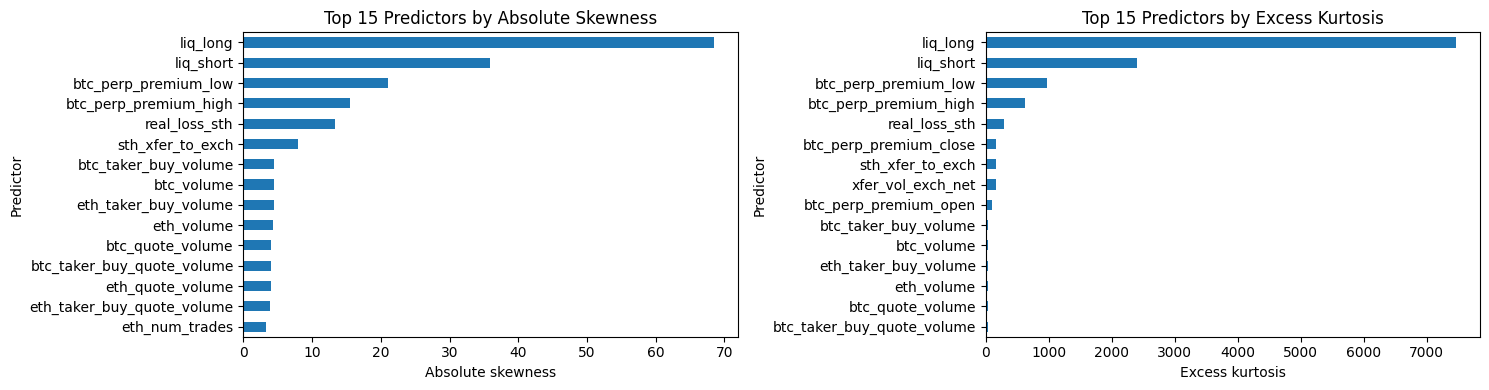

In [39]:
# Predictors with the most extreme skewness and kurtosis
n_show = 15
skew_plot = X_train_diag["skewness"].abs().nlargest(n_show).sort_values()
kurt_plot = X_train_diag["excess_kurtosis"].nlargest(n_show).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

skew_plot.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"Top {n_show} Predictors by Absolute Skewness")
axes[0].set_xlabel("Absolute skewness")
axes[0].set_ylabel("Predictor")

kurt_plot.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Top {n_show} Predictors by Excess Kurtosis")
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_ylabel("Predictor")

plt.tight_layout()
plt.show()

The results confirm that several raw predictors are strongly asymmetric and heavy-tailed. Liquidation variables show the most extreme skewness and excess kurtosis, reflecting long periods of limited activity interrupted by a small number of severe market events.

Premium-index variables also exhibit pronounced tail behaviour during basis dislocations. These features may therefore act more as event or regime indicators than stable continuous signals and will require appropriate transformations, such as `log1p` or signed-log scaling, before modelling.


**d) Zero-Inflated and Event-Driven Variables**

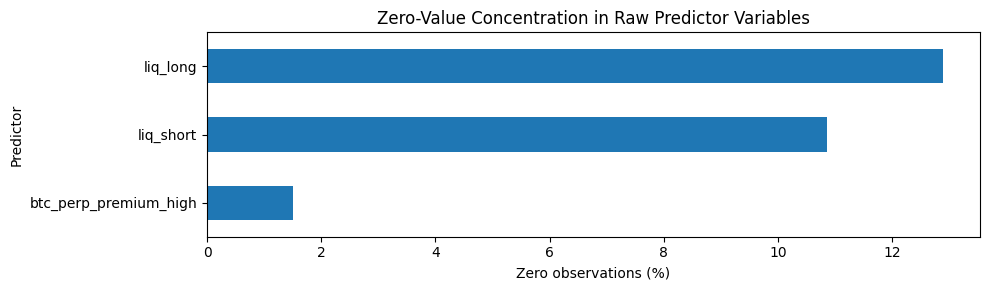

In [40]:
# Predictors with a material concentration of zero values
zero_threshold = 1.0
zero_plot = X_train_diag.loc[X_train_diag["zero_pct"] >= zero_threshold, "zero_pct"].sort_values()

if zero_plot.empty:
    print(f"No raw predictors have zero values in at least {zero_threshold:.0f}% of observed rows.")
else:
    plt.figure(figsize=(10, max(3, len(zero_plot) * 0.35)))
    zero_plot.plot(kind="barh")
    plt.title("Zero-Value Concentration in Raw Predictor Variables")
    plt.xlabel("Zero observations (%)")
    plt.ylabel("Predictor")
    plt.tight_layout()
    plt.show()

The chart confirms that liquidation variables are zero-inflated and episodic: many hours record no activity, while non-zero observations capture discrete stress events. Feature engineering should therefore consider both a transformed liquidation magnitude and a binary event indicator. The much smaller zero concentration in the premium-index high is less material.


**e) Target Variable Analysis Across Candidate Horizons**

Six candidate forecast horizons of 1, 4, 6, 8, 12 and 24 hours are retained because the appropriate prediction horizon has not yet been established. Short horizons provide more frequent trading opportunities but may be dominated by noise and transaction cost challenges, while longer horizons may offer greater return dispersion at the expense of slower signals and more overlap between observations. The target distributions are therefore compared before selecting a final horizon.

For each horizon, the forward log return is converted into a binary direction target, with positive returns assigned to class 1 and zero or negative returns to class 0.

Class balance is assessed separately because it may vary across horizons and influence model training and evaluation. The final horizon will be selected later using training-sample signal strength and stability, including IC and IC/IR evidence.


In [41]:
# Candidate target distributions and class balance
target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

target_data = targets_train[target_cols]
target_summary = target_data.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

target_summary["negative_count"] = target_data.le(0).sum()
target_summary["positive_count"] = target_data.gt(0).sum()
target_summary["positive_pct"] = target_data.gt(0).sum().div(target_data.notna().sum()).mul(100)
target_summary["negative_pct"] = target_data.le(0).sum().div(target_data.notna().sum()).mul(100)

target_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,negative_count,positive_count,positive_pct,negative_pct
fwd_logret_1h,"45,537.0000",0.0001,0.0070,-0.2071,-0.0207,-0.0095,-0.0024,0.0001,0.0026,0.0097,0.0200,0.1508,22351,23186,50.9168,49.0832
fwd_logret_4h,"45,537.0000",0.0002,0.0138,-0.3593,-0.0409,-0.0201,-0.0047,0.0002,0.0052,0.0205,0.0401,0.1867,22190,23347,51.2704,48.7296
fwd_logret_6h,"45,537.0000",0.0003,0.0167,-0.3956,-0.0490,-0.0247,-0.0058,0.0003,0.0067,0.0253,0.0479,0.2797,22143,23394,51.3736,48.6264
fwd_logret_8h,"45,537.0000",0.0004,0.0192,-0.4083,-0.0564,-0.0284,-0.0068,0.0004,0.0079,0.0296,0.0557,0.3178,22035,23502,51.6108,48.3892
fwd_logret_12h,"45,537.0000",0.0006,0.0234,-0.3880,-0.0687,-0.0350,-0.0087,0.0005,0.0102,0.0367,0.0672,0.3204,21972,23565,51.7491,48.2509
fwd_logret_24h,"45,537.0000",0.0013,0.0337,-0.6416,-0.0968,-0.0499,-0.0132,0.0011,0.0163,0.0533,0.0936,0.2993,21581,23956,52.6078,47.3922


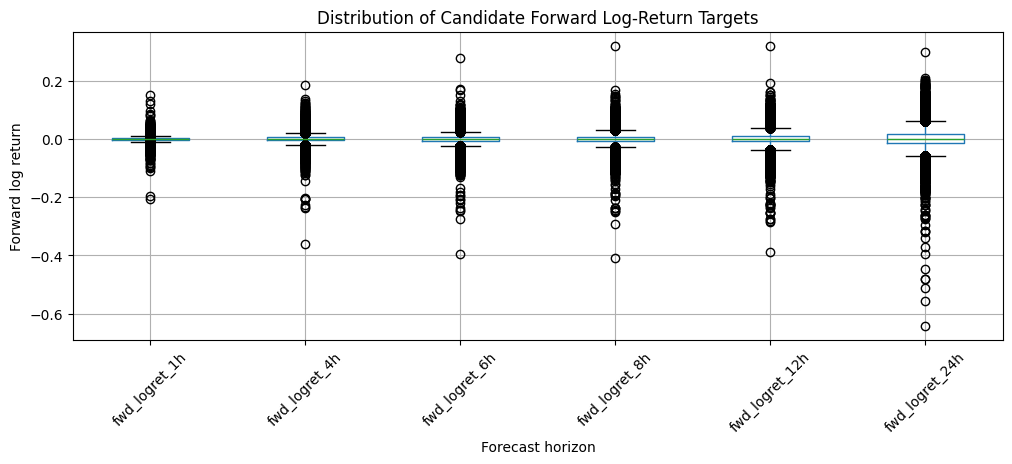

In [42]:
# Boxplots of candidate forward log-return targets
ax = target_data.boxplot(figsize=(12, 4), showfliers=True)

ax.set_title("Distribution of Candidate Forward Log-Return Targets")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forward log return")

plt.xticks(rotation=45)
plt.show()

The forward-return distributions remain centred close to zero across all six horizons, while both the interquartile range and the magnitude of extreme observations increase with the forecast horizon. The 24-hour target shows the widest dispersion and the largest downside extremes. This confirms that longer horizons capture larger cumulative price movements, although tail asymmetry should be assessed from the accompanying quantiles, skewness and extrema rather than from the boxplots alone.

**f) Temporal Behaviour and Regime Variation**

Financial time series are not stationary across the full sample and often alternate between calm, trending and stressed market regimes. The following analysis examines how BTC returns, realised volatility and selected market indicators evolve through time, rather than relying only on full-sample summary statistics. These charts help identify volatility clustering, structural changes and episodic dislocations that may motivate rolling, normalised or regime-sensitive features during feature engineering.

i) BTC Rolling 24-Hour Log Return and Realised Volatility

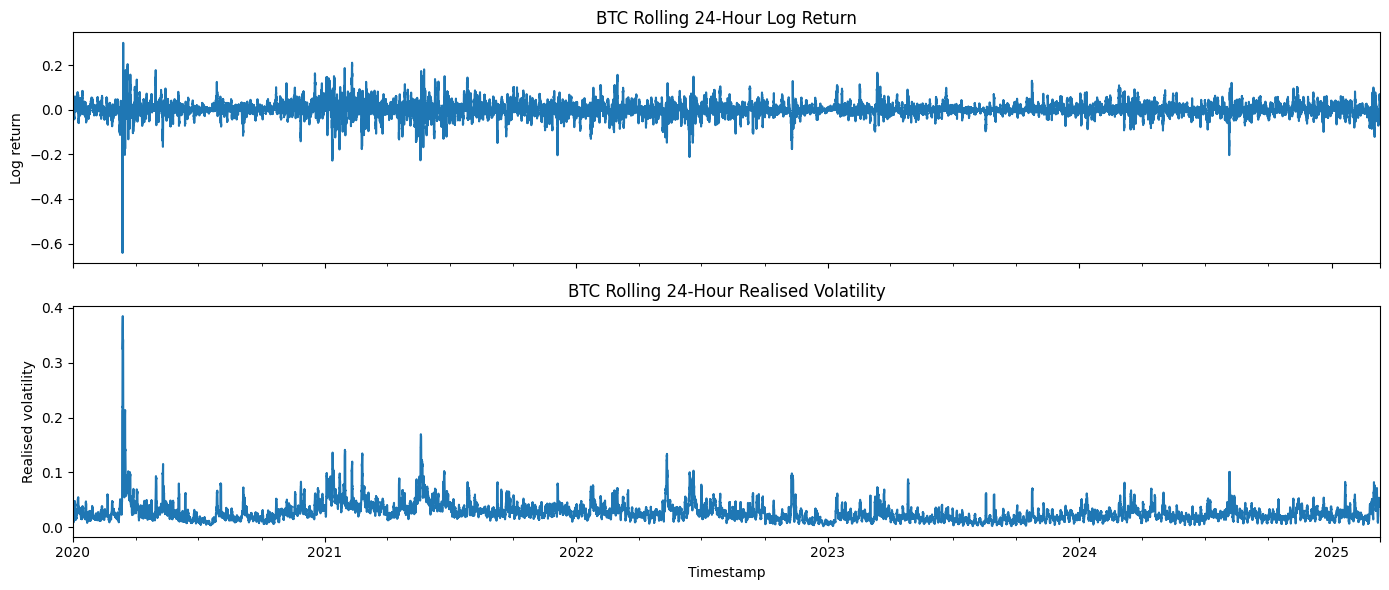

In [43]:
# BTC rolling 24-hour return and realised volatility
temporal_df = X_train.set_index("timestamp").copy()

temporal_df["btc_logret_1h"] = np.log(temporal_df["btc_close"] / temporal_df["btc_close"].shift(1))
temporal_df["btc_logret_24h"] = temporal_df["btc_logret_1h"].rolling(24).sum()
temporal_df["btc_realised_vol_24h"] = np.sqrt(temporal_df["btc_logret_1h"].pow(2).rolling(24).sum())
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

temporal_df["btc_logret_24h"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("BTC Rolling 24-Hour Log Return")
axes[0].set_ylabel("Log return")

temporal_df["btc_realised_vol_24h"].plot(ax=axes[1])
axes[1].set_title("BTC Rolling 24-Hour Realised Volatility")
axes[1].set_ylabel("Realised volatility")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The rolling series show clear volatility clustering: high-volatility periods coincide with a wider range of positive and negative 24-hour returns, while calmer periods remain closer to zero.

The relationship is not exact because realised volatility measures total intraday variation, whereas the 24-hour log return captures only the net directional move. This supports the use of volatility and regime-sensitive features in feature engineering.

ii) BTC Perpetual Premium and Funding at 8-Hour Settlement Intervals

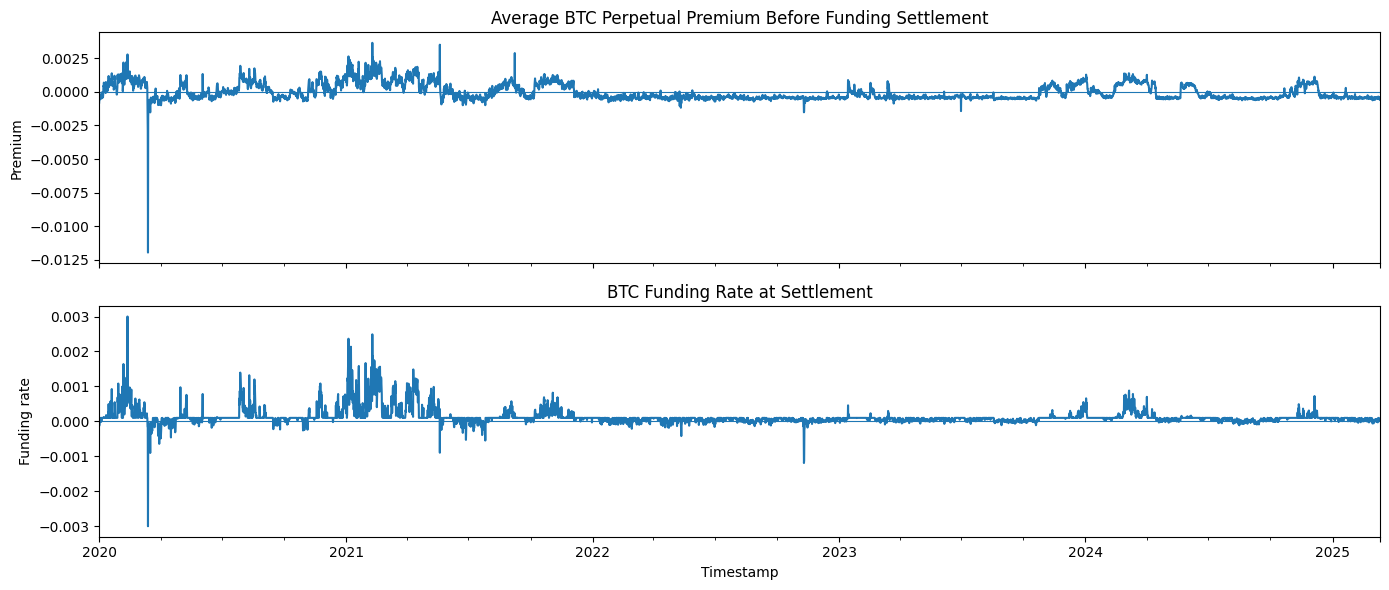

In [44]:
# BTC perpetual premium and funding at 8-hour settlement intervals
premium_funding_8h = temporal_df[["btc_perp_premium_close", "btc_funding"]].resample("8h", origin="start_day", closed="right", label="right").agg({
    "btc_perp_premium_close": "mean",
    "btc_funding": "last"})

premium_funding_8h = premium_funding_8h.dropna(subset=["btc_funding"])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

premium_funding_8h["btc_perp_premium_close"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Average BTC Perpetual Premium Before Funding Settlement")
axes[0].set_ylabel("Premium")

premium_funding_8h["btc_funding"].plot(ax=axes[1])
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("BTC Funding Rate at Settlement")
axes[1].set_ylabel("Funding rate")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The 8-hour aggregation shows that perpetual premium and funding generally move in the same direction, consistent with funding responding to persistent deviations between perpetual and spot prices. Large positive values may indicate crowded long positioning, while large negative values may reflect bearish pressure and deleveraging stress. Extreme joint movements are therefore potential indicators of market stress.

iii) Rolling Standardised Open Interest and Leverage Ratio

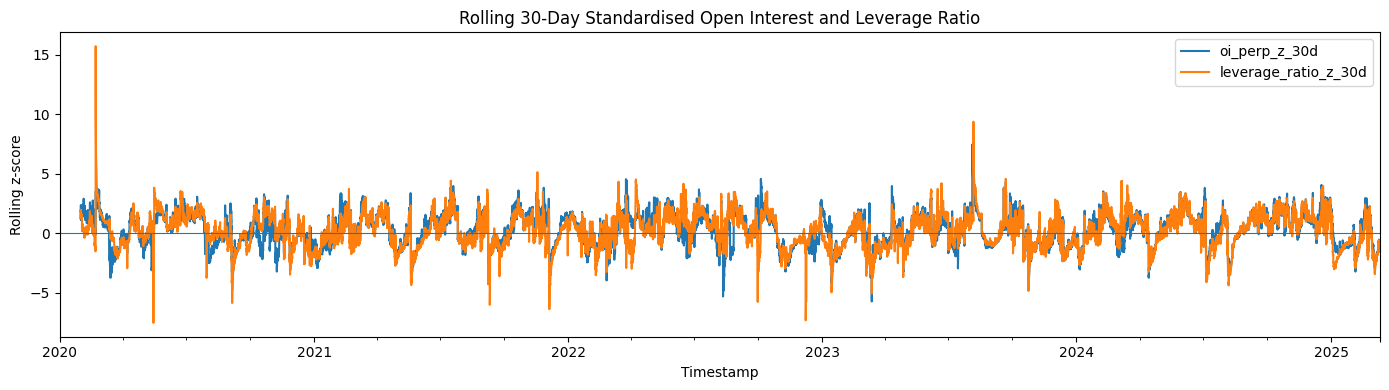

In [45]:
# Rolling 30-day standardisation of open interest and leverage ratio
rolling_window = 24 * 30

oi_mean = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).mean()
oi_std = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).std()

lev_mean = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).mean()
lev_std = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).std()

temporal_df["oi_perp_z_30d"] = (temporal_df["oi_perp"] - oi_mean) / oi_std
temporal_df["leverage_ratio_z_30d"] = (temporal_df["leverage_ratio"] - lev_mean) / lev_std

ax = temporal_df[["oi_perp_z_30d", "leverage_ratio_z_30d"]].plot(figsize=(14, 4))

ax.axhline(0, linewidth=0.8)
ax.set_title("Rolling 30-Day Standardised Open Interest and Leverage Ratio")
ax.set_ylabel("Rolling z-score")
ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The rolling 30-day standardisation places open interest and the estimated leverage ratio on a common scale and shows broadly similar temporal behaviour. Temporary divergences suggest that changes in open interest do not always correspond to equivalent changes in leverage intensity. Both measures will therefore remain candidates for feature engineering, subject to later redundancy and VIF checks.

Not all predictors were plotted because some raw levels are not directly comparable or produce visually uninformative time-series charts. These variables will be evaluated during feature engineering after applying suitable transformations, including log scaling, changes, returns, rolling standardisation and relative spreads. This allows their behaviour to be assessed in a more comparable and economically meaningful form.

**Part II — Deribit Futures Panel EDA**

Deribit data are handled separately at both the raw-data preparation and EDA stages because the extracted futures data are structured as a contract-level panel. At each timestamp, multiple instruments with different expiry dates coexist.

Directly merging individual Deribit contracts into the hourly predictor matrix would therefore create a changing and non-stationary feature space. A column representing a specific contract would exist only during that contract’s trading life, while its economic meaning would change continuously as time to expiry declines.

This section analyses the Deribit data as a changing contract-level panel rather than as a conventional fixed-dimensional hourly dataset.

The purpose of this section is to -
understand panel coverage and contract turnover;

*   examine maturity and liquidity structure
*   identify roll and expiry effect
*   assess the futures curve
*   determine how to convert the panel into fixed-dimensional, point-in-time features

a) **Contract Maturity and Roll Behaviour**

Deribit futures are analysed separately using only the saved training-period contract panel. This subsection verifies the panel structure and calculates the remaining time to expiry for dated futures. The perpetual contract is identified separately because it has no fixed maturity.

i) Load Deribit Data Panel

In [47]:
# Load Deribit training panel for EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"; os.chdir(data_dir)

deribit_train_panel = pd.read_csv("deribit_train_panel.csv", parse_dates=["timestamp", "expiration_timestamp"])
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True, errors="coerce")
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

deribit_train_panel["is_perpetual"] = deribit_train_panel["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit_train_panel["observation_timestamp"] = deribit_train_panel["timestamp"] - pd.Timedelta(hours=1)
deribit_train_panel["days_to_expiry"] = (deribit_train_panel["expiration_timestamp"] - deribit_train_panel["observation_timestamp"]).dt.total_seconds() / 86400

dated_mask = ~deribit_train_panel["is_perpetual"]

assert deribit_train_panel["timestamp"].notna().all()
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any()
assert deribit_train_panel.loc[dated_mask, "expiration_timestamp"].notna().all()
assert deribit_train_panel.loc[dated_mask, "days_to_expiry"].ge(0).all()

print("Deribit training shape:", deribit_train_panel.shape)
print("Training period:", deribit_train_panel["timestamp"].min(), "to", deribit_train_panel["timestamp"].max())
print("Instruments:", deribit_train_panel["instrument_name"].nunique())
print("Perpetual rows:", deribit_train_panel["is_perpetual"].sum())
print("Dated futures rows:", dated_mask.sum())
print("Minimum dated time to expiry:", deribit_train_panel.loc[dated_mask, "days_to_expiry"].min())

deribit_train_panel.head()

Deribit training shape: (214352, 16)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Instruments: 25
Perpetual rows: 45537
Dated futures rows: 168815
Minimum dated time to expiry: 0.0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp,is_perpetual,observation_timestamp,days_to_expiry
0,1577833200000,"7,440.5000","7,447.5000","7,426.5000","7,433.0000",9.9284,"73,830.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,177.3750
1,1577833200000,"7,292.0000","7,292.0000","7,274.0000","7,280.0000",26.5040,"193,000.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,86.3750
2,1577833200000,"7,178.5000","7,186.0000","7,164.0000","7,169.5000",301.1300,"2,161,100.0000",BTC-PERPETUAL,perpetual,perpetual,NaN,NaT,2020-01-01 00:00:00+00:00,True,2019-12-31 23:00:00+00:00,NaN
3,1577836800000,"7,433.0000","7,433.0000","7,414.0000","7,418.5000",9.6024,"71,270.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,177.3333
4,1577836800000,"7,277.0000","7,277.0000","7,265.5000","7,265.5000",17.7270,"128,870.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,86.3333


The Deribit panel contains one perpetual contract and a changing set of dated futures. The following summary examines the number of active contracts available at each timestamp and the maturity range represented by the dated contracts.

ii) Summarize active contracts and maturity coverage by timestamp

In [48]:
# Summarise active contracts and maturity coverage by timestamp
deribit_maturity_summary = deribit_train_panel.groupby("timestamp").agg(
    active_contracts=("instrument_name", "nunique"),
    active_perpetuals=("is_perpetual", "sum"),
    active_dated_futures=("is_perpetual", lambda x: (~x).sum()),
    min_days_to_expiry=("days_to_expiry", "min"),
    max_days_to_expiry=("days_to_expiry", "max"))

deribit_maturity_summary.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).round(2)

,active_contracts,active_perpetuals,active_dated_futures,min_days_to_expiry,max_days_to_expiry
count,"45,537.0000","45,537.0000","45,537.0000","45,537.0000","45,537.0000"
mean,4.7100,1.0000,3.7100,45.9000,292.9900
std,0.5600,0.0000,0.5600,26.2600,55.3400
min,3.0000,1.0000,2.0000,0.0000,116.0400
1%,3.0000,1.0000,2.0000,0.9200,135.0100
25%,5.0000,1.0000,4.0000,23.3300,273.5400
50%,5.0000,1.0000,4.0000,45.9200,304.9600
75%,5.0000,1.0000,4.0000,68.5000,334.5800
99%,5.0000,1.0000,4.0000,90.7100,366.2800
max,6.0000,1.0000,5.0000,97.9600,371.0000


The Deribit training panel provides sufficient maturity depth for term-structure analysis, but the available contract set changes through time. A typical timestamp contains five instruments: one perpetual and four dated futures, with dated-contract coverage ranging from two to five. This confirms that individual contract names cannot be merged directly into the modelling matrix as a fixed feature set.

The nearest dated contract has a median time to expiry of about 46 days, while the longest available maturity is typically around 305 days. The panel therefore spans the front of the curve to roughly one year and is suitable for constructing stable, roll-aware term-structure features.

iii) Identify the Front Dated Future and Contract Roll Dates

In [49]:
# Identify the front dated future and contract roll dates
deribit_dated = deribit_train_panel.loc[~deribit_train_panel["is_perpetual"]].copy()
deribit_dated = deribit_dated.sort_values(["timestamp", "days_to_expiry", "instrument_name"])

deribit_front = deribit_dated.groupby("timestamp", as_index=False).first()
deribit_front = deribit_front[["timestamp", "instrument_name", "days_to_expiry", "close", "volume", "cost"]]

deribit_front["previous_instrument"] = deribit_front["instrument_name"].shift()
deribit_front["is_roll"] = deribit_front["instrument_name"].ne(deribit_front["previous_instrument"])
deribit_front.loc[deribit_front.index[0], "is_roll"] = False

deribit_rolls = deribit_front.loc[
    deribit_front["is_roll"],
    ["timestamp", "previous_instrument", "instrument_name", "days_to_expiry"]
].reset_index(drop=True)

roll_spacing_days = deribit_rolls["timestamp"].diff().dt.total_seconds().div(86400)

print("Front-contract observations:", len(deribit_front))
print("Front-contract changes:", len(deribit_rolls))
print("Median days between rolls:", roll_spacing_days.median())

deribit_rolls

Front-contract observations: 45537
Front-contract changes: 20
Median days between rolls: 91.0


,timestamp,previous_instrument,instrument_name,days_to_expiry
0,2020-03-27 10:00:00+00:00,BTC-27MAR20,BTC-26JUN20,90.9583
1,2020-06-26 10:00:00+00:00,BTC-26JUN20,BTC-25SEP20,90.9583
2,2020-09-25 10:00:00+00:00,BTC-25SEP20,BTC-25DEC20,90.9583
3,2020-12-25 10:00:00+00:00,BTC-25DEC20,BTC-26MAR21,90.9583
4,2021-03-26 10:00:00+00:00,BTC-26MAR21,BTC-25JUN21,90.9583
5,2021-06-25 10:00:00+00:00,BTC-25JUN21,BTC-24SEP21,90.9583
6,2021-09-24 10:00:00+00:00,BTC-24SEP21,BTC-31DEC21,97.9583
7,2021-12-31 10:00:00+00:00,BTC-31DEC21,BTC-25MAR22,83.9583
8,2022-03-25 10:00:00+00:00,BTC-25MAR22,BTC-24JUN22,90.9583
9,2022-06-24 10:00:00+00:00,BTC-24JUN22,BTC-30SEP22,97.9583


This analysis identifies the nearest-to-expiry dated future at each timestamp and records when that contract changes. It illustrates the roll behaviour of the front contract and confirms that a continuous front-futures series must be constructed explicitly rather than linked by fixed instrument name.

**b) Liquidity and Data Reliability**

This subsection assesses whether the Deribit contracts are sufficiently active and reliable for feature construction. Because the panel includes traded volume and cost but not bid–ask spreads or open interest, the analysis focuses on:

- missing, zero or negative trading activity
- unchanged hourly candles as a sign of inactivity
- differences in activity between perpetual and dated futures
- whether liquidity declines materially for longer maturities
- whether thin observations should be excluded or down-weighted

i) Compares structural liquidity characteristics for perpetual and dated futures

In [50]:
# Summarise trading activity and inactive observations
deribit_train_panel["contract_type"] = np.where(deribit_train_panel["is_perpetual"], "Perpetual", "Dated futures")
deribit_train_panel["zero_volume"] = deribit_train_panel["volume"].eq(0)
deribit_train_panel["zero_cost"] = deribit_train_panel["cost"].eq(0)
deribit_train_panel["negative_volume"] = deribit_train_panel["volume"].lt(0)
deribit_train_panel["negative_cost"] = deribit_train_panel["cost"].lt(0)
deribit_train_panel["flat_candle"] = deribit_train_panel[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_liquidity_summary = deribit_train_panel.groupby("contract_type").agg(
    observations=("instrument_name", "size"),
    instruments=("instrument_name", "nunique"),
    missing_volume=("volume", lambda x: x.isna().sum()),
    missing_cost=("cost", lambda x: x.isna().sum()),
    negative_volume=("negative_volume", "sum"),
    negative_cost=("negative_cost", "sum"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_liquidity_summary[pct_cols] = deribit_liquidity_summary[pct_cols].mul(100)

deribit_liquidity_summary.round(2)

,observations,instruments,missing_volume,missing_cost,negative_volume,negative_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct,median_volume,median_cost,mean_cost
contract_type,,,,,,,,,,,,
Dated futures,168815,24,0,0,0,0,3.6800,3.6800,6.3400,4.8800,"180,940.0000","803,456.0500"
Perpetual,45537,1,0,0,0,0,0.0100,0.0100,0.0200,370.0700,"11,787,750.0000","21,431,112.8100"


The Deribit panel contains no missing or negative volume and cost observations. The perpetual contract is highly active, with almost no zero-activity or flat-candle observations, while dated futures are less liquid, with about 3.7% zero-volume observations and 6.3% flat candles. Dated contracts remain usable for term-structure analysis, but their uneven activity supports liquidity screening or weighting during feature construction.

The next analysis groups dated futures by time to expiry to assess whether liquidity deteriorates materially at longer maturities.

ii) Compare dated-futures liquidity across maturity buckets

In [51]:
# Compare dated-futures liquidity across maturity buckets
maturity_bins = [0, 30, 90, 180, np.inf]
maturity_labels = ["0–30 days", "31–90 days", "91–180 days", "181+ days"]

deribit_dated["maturity_bucket"] = pd.cut(
    deribit_dated["days_to_expiry"],
    bins=maturity_bins,
    labels=maturity_labels,
    include_lowest=True
)

deribit_dated["zero_volume"] = deribit_dated["volume"].eq(0)
deribit_dated["zero_cost"] = deribit_dated["cost"].eq(0)
deribit_dated["flat_candle"] = deribit_dated[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_maturity_liquidity = deribit_dated.groupby("maturity_bucket", observed=True).agg(
    observations=("instrument_name", "size"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_maturity_liquidity[pct_cols] = deribit_maturity_liquidity[pct_cols].mul(100)

deribit_maturity_liquidity.round(2)

,observations,median_volume,median_cost,mean_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct
maturity_bucket,,,,,,,
0–30 days,14756,30.8100,"977,285.0000","2,159,923.8200",0.2000,0.2000,0.2400
31–90 days,30153,21.1600,"683,780.0000","1,664,919.4800",0.1000,0.1000,0.2500
91–180 days,44889,8.5400,"287,240.0000","765,148.8900",0.5100,0.5100,1.1900
181+ days,79017,1.0600,"41,730.0000","243,169.3500",7.4900,7.4900,12.7400


Dated-futures liquidity declines clearly with maturity. Contracts within 90 days of expiry are highly active, while activity weakens between 91 and 180 days. Beyond 180 days, liquidity is materially thinner, with about 7.5% zero-volume observations and 12.7% flat candles. Far-dated contracts should therefore be filtered, down-weighted or used selectively in term-structure features.

**c) Futures Basis and Term-Structure Behaviour**

This subsection converts dated-futures prices into maturity-comparable term-structure measures. Each contract is compared with BTC spot to calculate percentage basis, which is then annualised by remaining time to expiry. Observations with one day or less to expiry are excluded from annualisation because the scaling becomes unstable near settlement.

i) Construct the Front Futures Curve Slope

In [59]:
# Rebuild dated-futures basis and construct the front futures curve slope
btc_spot = X_train[["timestamp", "btc_close"]].copy()
btc_spot["timestamp"] = pd.to_datetime(btc_spot["timestamp"], utc=True)
btc_spot = btc_spot.rename(columns={"timestamp": "observation_timestamp"})

deribit_basis = deribit_dated.merge(btc_spot, on="observation_timestamp", how="left", validate="many_to_one")
deribit_basis = deribit_basis.dropna(subset=["btc_close"]).copy()
deribit_basis["basis_pct"] = 100 * (deribit_basis["close"] / deribit_basis["btc_close"] - 1)

curve_cols = ["timestamp", "instrument_name", "days_to_expiry", "basis_pct"]
curve_ranked = deribit_basis[curve_cols].sort_values(["timestamp", "days_to_expiry", "instrument_name"]).copy()
curve_ranked["maturity_rank"] = curve_ranked.groupby("timestamp").cumcount() + 1
curve_ranked = curve_ranked.loc[curve_ranked["maturity_rank"].le(2)].copy()

front_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(1), curve_cols].copy()
second_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(2), curve_cols].copy()

front_contract = front_contract.rename(columns={"instrument_name": "front_instrument", "days_to_expiry": "front_days", "basis_pct": "front_basis_pct"})
second_contract = second_contract.rename(columns={"instrument_name": "second_instrument", "days_to_expiry": "second_days", "basis_pct": "second_basis_pct"})

front_curve = front_contract.merge(second_contract, on="timestamp", how="inner", validate="one_to_one")
front_curve["curve_slope_pct"] = front_curve["second_basis_pct"] - front_curve["front_basis_pct"]
front_curve["curve_state"] = np.where(front_curve["curve_slope_pct"].ge(0), "Upward sloping", "Inverted")

front_curve_summary = pd.Series({
    "observations": len(front_curve),
    "median_front_basis_pct": front_curve["front_basis_pct"].median(),
    "median_second_basis_pct": front_curve["second_basis_pct"].median(),
    "median_curve_slope_pct": front_curve["curve_slope_pct"].median(),
    "upward_sloping_pct": 100 * front_curve["curve_state"].eq("Upward sloping").mean(),
    "inverted_pct": 100 * front_curve["curve_state"].eq("Inverted").mean()
})

front_curve_summary.to_frame("value").T.round(2)

,observations,median_front_basis_pct,median_second_basis_pct,median_curve_slope_pct,upward_sloping_pct,inverted_pct
value,"45,536.0000",0.7700,2.7900,1.8500,96.3800,3.6200


The front futures curve is upward sloping in 96.4% of training observations and inverted in only 3.6%. The median basis rises from 0.77% for the nearest contract to 2.79% for the second contract, producing a median curve slope of 1.85 percentage points. Inversion is therefore an uncommon regime that may be more informative than the normal upward-sloping state and should be retained as a candidate stress indicator.

**d) Implications for Deribit Feature Engineering**

The Deribit EDA confirms that individual contract prices should not be used directly as predictors because the active contract set changes through time and the front contract rolls periodically. The panel should instead be converted into a fixed set of roll-aware, point-in-time features.

Liquidity is concentrated in the perpetual and nearer-dated futures, while contracts beyond 180 days are materially thinner. Feature construction should therefore prioritise the perpetual, front and intermediate sections of the curve, with far-dated contracts excluded, screened or liquidity-weighted.

The basis results support candidate features including front-contract basis, annualised front basis, front-curve slope, curve inversion indicators, changes in curve slope and front-contract days to expiry. Perpetual trading activity may also provide continuous liquidity and positioning measures.

All Deribit features will be constructed from contracts available at each timestamp using deribit_train_panel, with unstable near-expiry annualisation excluded and extreme basis or slope changes reviewed during feature engineering before alignment with the hourly training matrix.

**Part III) Insights from the EDA process**

The training-only EDA identified substantial variation in scale, distribution, sparsity and temporal behaviour across the predictor set. Raw levels were therefore retained only where economically interpretable, while most variables will enter the modelling matrix through returns, changes, rolling standardisation, relative spreads or event indicators. Deribit contracts will be converted into fixed roll-aware term-structure features rather than merged by instrument name. The next stage constructs the compact v2 feature matrix, after which correlation, IC/IR, multicollinearity, stability and model-based feature selection will be assessed using training data only.

## **(V) Feature Engineering & Prediction Horizon Selection**

## **Part 1 - Feature Engineering**

The feature-engineering stage converts the cleaned training inputs into a compact set of predictors designed to capture short-horizon BTC price dynamics, volatility, market positioning, liquidity, derivatives structure, on-chain behaviour and broader risk conditions.

The candidate set is intentionally selective rather than exhaustive. Simple returns are retained only where they provide a necessary short-horizon reference, while greater emphasis is placed on rolling slopes, trend quality, acceleration, volatility asymmetry, regime indicators and relative-value measures. This reflects both the earlier exploratory results and prior modelling experience, where large collections of conventional return and technical features did not consistently improve predictive performance or stability.

Most directional features are concentrated around 1-hour, 4-hour, 8-hour and 24-hour windows, in order to capture short term, nuances around funding windows and a slightly longer duration benchmark/ daily reference. Longer windows are used mainly for estimating regimes or standardising variables, rather than as direct momentum signals.

Several features are also designed to capture nonlinear market states that may not be adequately represented by continuous variables alone. These include extreme drawdowns, unusually large premium–funding dislocations and exceptional trading activity. Such indicators are intended to identify stressed or crowded conditions that market participants commonly monitor.

Deribit futures are treated separately because the active contract set changes through time. Individual contract names therefore cannot be used as fixed model columns. Instead, the contract panel is converted into roll-aware measures of basis, curve slope, maturity, participation and liquidity before being aligned with the common hourly modelling index.

The initial candidate registry contains 95 features. These features will first be constructed and audited in full. Only after the complete matrix has passed alignment, missing-value, leakage and stability checks will the six candidate forecast horizons be compared using training-only IC/IR analysis. The selected horizon will then be examined for class balance and the possible need for a near-zero return exclusion band before the L2 logistic-regression baseline and subsequent feature-selection stages are run.

The six candidate forecast horizons—1, 4, 6, 8, 12 and 24 hours—will be compared using training-only IC/IR analysis after the complete feature matrix has been constructed and validated.


In [32]:
# Load training inputs for v2 feature engineering
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_TRAIN_PATH = DATA_PATH / "X_train_1h.csv"
TARGETS_TRAIN_PATH = DATA_PATH / "targets_train_1h.csv"
DERIBIT_TRAIN_PATH = DATA_PATH / "deribit_train_panel.csv"

for path in [X_TRAIN_PATH, TARGETS_TRAIN_PATH, DERIBIT_TRAIN_PATH]:
    assert path.exists(), f"Missing file: {path}"

X_train = pd.read_csv(X_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
X_train.index = pd.to_datetime(X_train.index, utc=True)
X_train = X_train.sort_index()

targets_train = pd.read_csv(TARGETS_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
targets_train.index = pd.to_datetime(targets_train.index, utc=True)
targets_train = targets_train.sort_index()

deribit_train_panel = pd.read_csv(DERIBIT_TRAIN_PATH)
deribit_train_panel = deribit_train_panel.drop(columns=deribit_train_panel.filter(regex=r"^Unnamed:").columns)
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True)
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

X_train_engineered = pd.DataFrame(index=X_train.index)

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
missing_target_cols = [col for col in target_cols if col not in targets_train.columns]

assert not X_train.index.has_duplicates, "Duplicate timestamps detected in X_train."
assert not targets_train.index.has_duplicates, "Duplicate timestamps detected in targets_train."
assert X_train.index.is_monotonic_increasing, "X_train is not sorted chronologically."
assert targets_train.index.is_monotonic_increasing, "targets_train is not sorted chronologically."
assert X_train.index.equals(targets_train.index), "X_train and targets_train timestamps are not aligned."
assert not missing_target_cols, f"Missing target columns: {missing_target_cols}"
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any(), "Duplicate Deribit timestamp-instrument rows detected."
assert deribit_train_panel["timestamp"].notna().all(), "Invalid Deribit timestamps detected."
assert X_train_engineered.index.equals(X_train.index), "Engineered matrix index does not match X_train."

print(f"X_train shape: {X_train.shape}")
print(f"X_train period: {X_train.index.min()} to {X_train.index.max()}")
print(f"X_train duplicate timestamps: {X_train.index.duplicated().sum():,}")

print(f"\nTargets shape: {targets_train.shape}")
print(f"Targets period: {targets_train.index.min()} to {targets_train.index.max()}")
print(f"Candidate forward-return targets: {len(target_cols)}")
print(f"Feature-target timestamp alignment: {X_train.index.equals(targets_train.index)}")

print(f"\nDeribit training panel shape: {deribit_train_panel.shape}")
print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit instruments: {deribit_train_panel['instrument_name'].nunique():,}")
print(f"Deribit unique timestamps: {deribit_train_panel['timestamp'].nunique():,}")

print(f"\nX_train_engineered initial shape: {X_train_engineered.shape}")
print("Candidate v2 feature registry locked: 95")

X_train shape: (45537, 48)
X_train period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
X_train duplicate timestamps: 0

Targets shape: (45537, 7)
Targets period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Candidate forward-return targets: 6
Feature-target timestamp alignment: True

Deribit training panel shape: (214352, 13)
Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit instruments: 25
Deribit unique timestamps: 45,537

X_train_engineered initial shape: (45537, 0)
Candidate v2 feature registry locked: 95


### **a) BTC Price, Trend and Momentum**

Construction choices

- Slopes are measured as hourly changes in log price, so the 4h, 8h and 24h values are directly comparable.
- The slope t-statistics and R square are only calculated over 8h and 24h; four observations are too few for a useful trend-quality estimate.
- Acceleration compares consecutive non-overlapping return blocks:
i) latest 4h versus previous 4h;
ii) latest 8h versus previous 8h.

In [66]:
# a) BTC Price, Trend and Momentum

btc_close = pd.to_numeric(X_train["btc_close"], errors="coerce")
assert btc_close.notna().all() and btc_close.gt(0).all(), "Invalid BTC close values detected."

btc_log_price = np.log(btc_close)
btc_trend_features = pd.DataFrame(index=X_train.index)

# Simple log returns
btc_trend_features["btc_ret_1h"] = btc_log_price.diff(1)
btc_trend_features["btc_ret_4h"] = btc_log_price.diff(4)
btc_trend_features["btc_ret_24h"] = btc_log_price.diff(24)

# Rolling OLS statistics for equally spaced hourly observations
def rolling_logprice_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)
    sum_y = log_price.rolling(window, min_periods=window).sum()
    sum_y2 = log_price.pow(2).rolling(window, min_periods=window).sum()
    sum_xy = log_price.rolling(window, min_periods=window).apply(lambda y: np.dot(y, x), raw=True)
    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt((residual_ss / (window - 2)) / sxx)
    slope_tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)
    return slope, slope_tstat, r2

slope_4h, _, _ = rolling_logprice_regression(btc_log_price, 4)
slope_8h, slope_tstat_8h, trend_r2_8h = rolling_logprice_regression(btc_log_price, 8)
slope_24h, slope_tstat_24h, trend_r2_24h = rolling_logprice_regression(btc_log_price, 24)

# Trend direction, strength and path orderliness
btc_trend_features["btc_logprice_slope_4h"] = slope_4h
btc_trend_features["btc_logprice_slope_8h"] = slope_8h
btc_trend_features["btc_logprice_slope_24h"] = slope_24h
btc_trend_features["btc_slope_tstat_8h"] = slope_tstat_8h
btc_trend_features["btc_slope_tstat_24h"] = slope_tstat_24h
btc_trend_features["btc_trend_r2_8h"] = trend_r2_8h
btc_trend_features["btc_trend_r2_24h"] = trend_r2_24h

# Fast-versus-slow trend structure
btc_trend_features["btc_slope_spread_4h_24h"] = slope_4h - slope_24h
btc_trend_features["btc_slope_spread_8h_24h"] = slope_8h - slope_24h

# Return acceleration across consecutive non-overlapping blocks
btc_ret_8h = btc_log_price.diff(8)
btc_trend_features["btc_return_acceleration_4h"] = btc_trend_features["btc_ret_4h"] - btc_trend_features["btc_ret_4h"].shift(4)
btc_trend_features["btc_return_acceleration_8h"] = btc_ret_8h - btc_ret_8h.shift(8)

# Final family audit and merge
btc_trend_features = btc_trend_features.replace([np.inf, -np.inf], np.nan)

assert not btc_trend_features.columns.duplicated().any(), "Duplicate BTC trend feature names detected."
assert btc_trend_features["btc_trend_r2_8h"].dropna().between(0, 1).all()
assert btc_trend_features["btc_trend_r2_24h"].dropna().between(0, 1).all()

for feature in btc_trend_features:
    first_valid = btc_trend_features[feature].first_valid_index()

    if first_valid is not None:
        assert btc_trend_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(btc_trend_features)

print(f"BTC price, trend and momentum features added: {btc_trend_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_trend_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": btc_trend_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_trend_features.isna().sum()}))

BTC price, trend and momentum features added: 14
X_train_engineered shape: (45537, 14)
Longest warm-up: 24 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
btc_ret_1h,2020-01-01 01:00:00+00:00,1
btc_ret_4h,2020-01-01 04:00:00+00:00,4
btc_ret_24h,2020-01-02 00:00:00+00:00,24
btc_logprice_slope_4h,2020-01-01 03:00:00+00:00,3
btc_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
btc_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_slope_tstat_8h,2020-01-01 07:00:00+00:00,7
btc_slope_tstat_24h,2020-01-01 23:00:00+00:00,23
btc_trend_r2_8h,2020-01-01 07:00:00+00:00,7
btc_trend_r2_24h,2020-01-01 23:00:00+00:00,23


### **b) BTC Volatility, Asymmetry and Regimes**

In [76]:
# b) BTC Volatility, Asymmetry and Regimes
btc_volatility_features = pd.DataFrame(index=X_train.index)
btc_ret_1h = btc_trend_features["btc_ret_1h"]
btc_squared_return = btc_ret_1h.pow(2)
btc_downside_squared_return = btc_ret_1h.clip(upper=0).pow(2)

# Realised volatility
btc_volatility_features["btc_rv_4h"] = np.sqrt(btc_squared_return.rolling(4, min_periods=4).sum())
btc_volatility_features["btc_rv_8h"] = np.sqrt(btc_squared_return.rolling(8, min_periods=8).sum())
btc_volatility_features["btc_rv_24h"] = np.sqrt(btc_squared_return.rolling(24, min_periods=24).sum())

# Downside variance share
downside_share_8h = btc_downside_squared_return.rolling(8, min_periods=8).sum() / btc_squared_return.rolling(8, min_periods=8).sum().replace(0, np.nan)
downside_share_24h = btc_downside_squared_return.rolling(24, min_periods=24).sum() / btc_squared_return.rolling(24, min_periods=24).sum().replace(0, np.nan)

btc_volatility_features["btc_downside_variance_share_8h"] = downside_share_8h.clip(0, 1)
btc_volatility_features["btc_downside_variance_share_24h"] = downside_share_24h.clip(0, 1)

# Volatility instability
btc_volatility_features["btc_vol_of_vol_24h"] = btc_volatility_features["btc_rv_4h"].rolling(24, min_periods=24).std()

# Drawdown
btc_volatility_features["btc_drawdown_8h"] = btc_close / btc_close.rolling(8, min_periods=8).max() - 1
btc_volatility_features["btc_drawdown_24h"] = btc_close / btc_close.rolling(24, min_periods=24).max() - 1

drawdown_8h_threshold = btc_volatility_features["btc_drawdown_8h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_24h_threshold = btc_volatility_features["btc_drawdown_24h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_ready = drawdown_8h_threshold.notna() & drawdown_24h_threshold.notna()
drawdown_extreme = (btc_volatility_features["btc_drawdown_8h"] < drawdown_8h_threshold) | (btc_volatility_features["btc_drawdown_24h"] < drawdown_24h_threshold)

btc_volatility_features["btc_drawdown_extreme_flag"] = np.where(drawdown_ready, drawdown_extreme.astype(float), np.nan)

# Rolling Hurst exponent
hurst_window = 168
hurst_update_frequency = 24
hurst_scales = np.array([1, 2, 4, 8, 12, 24])

def estimate_hurst(return_window):
    log_scales = []
    log_variances = []

    for scale in hurst_scales:
        usable_length = len(return_window) // scale * scale

        if usable_length < scale * 5:
            continue

        aggregated_returns = return_window[-usable_length:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated_returns, ddof=1)

        if np.isfinite(variance) and variance > 0:
            log_scales.append(np.log(scale))
            log_variances.append(np.log(variance))

    if len(log_scales) < 3:
        return np.nan

    return np.polyfit(log_scales, log_variances, 1)[0] / 2

btc_hurst = pd.Series(np.nan, index=X_train.index, dtype=float)

for position in range(hurst_window, len(X_train), hurst_update_frequency):
    return_window = btc_ret_1h.iloc[position - hurst_window + 1:position + 1]

    if return_window.notna().sum() == hurst_window:
        btc_hurst.iloc[position] = estimate_hurst(return_window.to_numpy())

btc_volatility_features["btc_hurst_168h"] = btc_hurst.ffill()

# Causal EGARCH volatility
egarch_window = 4320
egarch_refit_frequency = 24
egarch_returns = 100 * btc_ret_1h
egarch_conditional_vol = pd.Series(np.nan, index=X_train.index, dtype=float)

for position in range(egarch_window, len(X_train), egarch_refit_frequency):
    estimation_start = position - egarch_window + 1
    segment_end = min(position + egarch_refit_frequency, len(X_train))

    estimation_sample = egarch_returns.iloc[estimation_start:position + 1].dropna()
    filtering_sample = egarch_returns.iloc[estimation_start:segment_end].dropna()

    if len(estimation_sample) != egarch_window:
        continue

    model = arch_model(estimation_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    fitted_model = model.fit(disp="off", show_warning=False)

    filtering_model = arch_model(filtering_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    filtered_model = filtering_model.fix(fitted_model.params)

    segment_index = X_train.index[position:segment_end]
    segment_volatility = filtered_model.conditional_volatility.reindex(segment_index) / 100
    egarch_conditional_vol.loc[segment_index] = segment_volatility

egarch_regime_mean = egarch_conditional_vol.rolling(720, min_periods=720).mean().shift(1)
egarch_regime_std = egarch_conditional_vol.rolling(720, min_periods=720).std().shift(1)

btc_volatility_features["btc_egarch_conditional_vol"] = egarch_conditional_vol
btc_volatility_features["btc_egarch_vol_regime"] = (egarch_conditional_vol - egarch_regime_mean) / egarch_regime_std.replace(0, np.nan)

# Family audit and merge
btc_volatility_features = btc_volatility_features.replace([np.inf, -np.inf], np.nan)

assert not btc_volatility_features.columns.duplicated().any(), "Duplicate BTC volatility feature names detected."
assert btc_volatility_features["btc_drawdown_extreme_flag"].dropna().isin([0, 1]).all(), "Invalid drawdown flag values."

for feature in btc_volatility_features:
    first_valid = btc_volatility_features[feature].first_valid_index()

    if first_valid is not None:
        assert btc_volatility_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(btc_volatility_features)

print(f"BTC volatility, asymmetry and regime features added: {btc_volatility_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_volatility_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": btc_volatility_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_volatility_features.isna().sum()}))

BTC volatility, asymmetry and regime features added: 12
X_train_engineered shape: (45537, 26)
Longest warm-up: 5,040 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
btc_rv_4h,2020-01-01 04:00:00+00:00,4
btc_rv_8h,2020-01-01 08:00:00+00:00,8
btc_rv_24h,2020-01-02 00:00:00+00:00,24
btc_downside_variance_share_8h,2020-01-01 08:00:00+00:00,8
btc_downside_variance_share_24h,2020-01-02 00:00:00+00:00,24
btc_vol_of_vol_24h,2020-01-02 03:00:00+00:00,27
btc_drawdown_8h,2020-01-01 07:00:00+00:00,7
btc_drawdown_24h,2020-01-01 23:00:00+00:00,23
btc_drawdown_extreme_flag,2020-01-08 23:00:00+00:00,191
btc_hurst_168h,2020-01-08 00:00:00+00:00,168


### **c) Premium, Funding and CEX Microstructure**

In [79]:
# c) Premium, Funding and CEX Microstructure

required_cex_cols = ["btc_volume", "btc_taker_buy_volume", "btc_perp_premium_close", "btc_funding", "coinbase_btc_close"]
missing_cex_cols = [col for col in required_cex_cols if col not in X_train.columns]
if missing_cex_cols: raise KeyError(f"Missing required CEX columns: {missing_cex_cols}")

cex_microstructure_features = pd.DataFrame(index=X_train.index)

premium = pd.to_numeric(X_train["btc_perp_premium_close"], errors="coerce")
funding = pd.to_numeric(X_train["btc_funding"], errors="coerce").ffill()
btc_volume = pd.to_numeric(X_train["btc_volume"], errors="coerce")
btc_taker_buy_volume = pd.to_numeric(X_train["btc_taker_buy_volume"], errors="coerce")
coinbase_close = pd.to_numeric(X_train["coinbase_btc_close"], errors="coerce")

# Premium
premium_mean_168h = premium.rolling(168, min_periods=168).mean()
premium_std_168h = premium.rolling(168, min_periods=168).std()
premium_zscore_168h = (premium - premium_mean_168h) / premium_std_168h
premium_zscore_168h = premium_zscore_168h.mask(premium_std_168h.eq(0), 0)

cex_microstructure_features["premium_level"] = premium
cex_microstructure_features["premium_change_4h"] = premium.diff(4)
cex_microstructure_features["premium_zscore_168h"] = premium_zscore_168h

# Funding
funding_mean_168h = funding.rolling(168, min_periods=168).mean()
funding_std_168h = funding.rolling(168, min_periods=168).std()
funding_zscore_168h = (funding - funding_mean_168h) / funding_std_168h
funding_zscore_168h = funding_zscore_168h.mask(funding_std_168h.eq(0), 0)

cex_microstructure_features["funding_rate"] = funding
cex_microstructure_features["funding_change_8h"] = funding.diff(8)
cex_microstructure_features["funding_zscore_168h"] = funding_zscore_168h
cex_microstructure_features["hours_since_funding"] = X_train.index.hour % 8

# Premium-funding dislocation
premium_funding_divergence = premium_zscore_168h - funding_zscore_168h
premium_funding_disagreement = (premium * funding < 0).astype(float)
premium_funding_disagreement = premium_funding_disagreement.where(premium.notna() & funding.notna())

cex_microstructure_features["premium_funding_divergence"] = premium_funding_divergence
cex_microstructure_features["premium_funding_abs_divergence"] = premium_funding_divergence.abs()
cex_microstructure_features["premium_funding_disagreement"] = premium_funding_disagreement

divergence_threshold = premium_funding_divergence.abs().rolling(720, min_periods=168).quantile(0.95).shift(1)
divergence_extreme = premium_funding_divergence.abs() > divergence_threshold

cex_microstructure_features["premium_funding_extreme_flag"] = divergence_extreme.astype(float).where(divergence_threshold.notna())

# Binance volume and taker flow
btc_log_volume = np.log1p(btc_volume.clip(lower=0))
btc_taker_buy_share = btc_taker_buy_volume / btc_volume
btc_taker_buy_share = btc_taker_buy_share.where(btc_volume.ne(0), 0.5)
btc_taker_buy_share = btc_taker_buy_share.where(btc_volume.notna() & btc_taker_buy_volume.notna())

cex_microstructure_features["binance_volume_log_change_4h"] = btc_log_volume.diff(4)
cex_microstructure_features["binance_taker_buy_share"] = btc_taker_buy_share.clip(0, 1)
cex_microstructure_features["binance_taker_buy_share_change_4h"] = cex_microstructure_features["binance_taker_buy_share"].diff(4)

# Coinbase-Binance price dislocation
coinbase_binance_spread = coinbase_close / btc_close - 1
spread_mean_168h = coinbase_binance_spread.rolling(168, min_periods=168).mean()
spread_std_168h = coinbase_binance_spread.rolling(168, min_periods=168).std()
spread_zscore_168h = (coinbase_binance_spread - spread_mean_168h) / spread_std_168h
spread_zscore_168h = spread_zscore_168h.mask(spread_std_168h.eq(0), 0)

cex_microstructure_features["coinbase_binance_price_spread"] = coinbase_binance_spread
cex_microstructure_features["coinbase_binance_spread_zscore_168h"] = spread_zscore_168h

# Family audit and merge
cex_microstructure_features = cex_microstructure_features.replace([np.inf, -np.inf], np.nan)

assert not cex_microstructure_features.columns.duplicated().any(), "Duplicate CEX feature names detected."
assert cex_microstructure_features["binance_taker_buy_share"].dropna().between(0, 1).all()
assert cex_microstructure_features["premium_funding_disagreement"].dropna().isin([0, 1]).all()
assert cex_microstructure_features["premium_funding_extreme_flag"].dropna().isin([0, 1]).all()

for feature in cex_microstructure_features:
    first_valid = cex_microstructure_features[feature].first_valid_index()
    if first_valid is not None: assert cex_microstructure_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(cex_microstructure_features)

print(f"Premium, funding and CEX microstructure features added: {cex_microstructure_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {cex_microstructure_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": cex_microstructure_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": cex_microstructure_features.isna().sum()}))

Premium, funding and CEX microstructure features added: 16
X_train_engineered shape: (45537, 42)
Longest warm-up: 335 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
premium_level,2020-01-01 00:00:00+00:00,0
premium_change_4h,2020-01-01 04:00:00+00:00,4
premium_zscore_168h,2020-01-07 23:00:00+00:00,167
funding_rate,2020-01-01 00:00:00+00:00,0
funding_change_8h,2020-01-01 08:00:00+00:00,8
funding_zscore_168h,2020-01-07 23:00:00+00:00,167
hours_since_funding,2020-01-01 00:00:00+00:00,0
premium_funding_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_abs_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_disagreement,2020-01-01 00:00:00+00:00,0


### **d) ETH and Cross-Crypto**

In [80]:
# d) ETH and Cross-Crypto

required_eth_cols = ["eth_close"]
missing_eth_cols = [col for col in required_eth_cols if col not in X_train.columns]
if missing_eth_cols: raise KeyError(f"Missing required ETH columns: {missing_eth_cols}")

eth_features = pd.DataFrame(index=X_train.index)

eth_close = pd.to_numeric(X_train["eth_close"], errors="coerce")
eth_log_price = np.log(eth_close.where(eth_close > 0))

eth_slope_8h, _, _ = rolling_logprice_regression(eth_log_price, 8)
eth_slope_24h, _, _ = rolling_logprice_regression(eth_log_price, 24)

eth_features["eth_logprice_slope_8h"] = eth_slope_8h
eth_features["eth_logprice_slope_24h"] = eth_slope_24h
eth_features["btc_eth_slope_spread_8h"] = btc_trend_features["btc_logprice_slope_8h"] - eth_slope_8h

eth_features = eth_features.replace([np.inf, -np.inf], np.nan)

assert not eth_features.columns.duplicated().any(), "Duplicate ETH feature names detected."

for feature in eth_features:
    first_valid = eth_features[feature].first_valid_index()
    if first_valid is not None: assert eth_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(eth_features)

print(f"ETH and cross-crypto features added: {eth_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {eth_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": eth_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": eth_features.isna().sum()}))

ETH and cross-crypto features added: 3
X_train_engineered shape: (45537, 45)
Longest warm-up: 23 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
eth_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
eth_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_eth_slope_spread_8h,2020-01-01 07:00:00+00:00,7


### **e) Open Interest, Leverage and Liquidations**

In [81]:
# e) Open Interest, Leverage and Liquidations

required_positioning_cols = ["oi_perp", "leverage_ratio", "liq_long", "liq_short"]
missing_positioning_cols = [col for col in required_positioning_cols if col not in X_train.columns]
if missing_positioning_cols: raise KeyError(f"Missing required positioning columns: {missing_positioning_cols}")

positioning_features = pd.DataFrame(index=X_train.index)

open_interest = pd.to_numeric(X_train["oi_perp"], errors="coerce")
leverage_ratio = pd.to_numeric(X_train["leverage_ratio"], errors="coerce")
long_liquidations = pd.to_numeric(X_train["liq_long"], errors="coerce")
short_liquidations = pd.to_numeric(X_train["liq_short"], errors="coerce")

open_interest_log = np.log(open_interest.where(open_interest > 0))
leverage_log = np.log(leverage_ratio.where(leverage_ratio > 0))

# Open-interest momentum and regime
oi_mean_168h = open_interest_log.rolling(168, min_periods=168).mean()
oi_std_168h = open_interest_log.rolling(168, min_periods=168).std()
oi_zscore_168h = (open_interest_log - oi_mean_168h) / oi_std_168h
oi_zscore_168h = oi_zscore_168h.mask(oi_std_168h.eq(0), 0)

oi_slope_8h, _, _ = rolling_logprice_regression(open_interest_log, 8)

positioning_features["oi_log_roc_4h"] = open_interest_log.diff(4)
positioning_features["oi_log_roc_24h"] = open_interest_log.diff(24)
positioning_features["oi_slope_8h"] = oi_slope_8h
positioning_features["oi_zscore_168h"] = oi_zscore_168h

# Estimated-leverage momentum and regime
leverage_mean_168h = leverage_log.rolling(168, min_periods=168).mean()
leverage_std_168h = leverage_log.rolling(168, min_periods=168).std()
leverage_zscore_168h = (leverage_log - leverage_mean_168h) / leverage_std_168h
leverage_zscore_168h = leverage_zscore_168h.mask(leverage_std_168h.eq(0), 0)

leverage_slope_8h, _, _ = rolling_logprice_regression(leverage_log, 8)

positioning_features["leverage_log_roc_4h"] = leverage_log.diff(4)
positioning_features["leverage_log_roc_24h"] = leverage_log.diff(24)
positioning_features["leverage_slope_8h"] = leverage_slope_8h
positioning_features["leverage_zscore_168h"] = leverage_zscore_168h

# Open-interest and leverage divergence
positioning_features["oi_leverage_divergence"] = oi_zscore_168h - leverage_zscore_168h

# Liquidation pressure
long_first_valid = long_liquidations.first_valid_index()
short_first_valid = short_liquidations.first_valid_index()

if long_first_valid is not None: long_liquidations.loc[long_first_valid:] = long_liquidations.loc[long_first_valid:].fillna(0)
if short_first_valid is not None: short_liquidations.loc[short_first_valid:] = short_liquidations.loc[short_first_valid:].fillna(0)

positioning_features["long_liquidation_pressure"] = np.log1p(long_liquidations.clip(lower=0))
positioning_features["short_liquidation_pressure"] = np.log1p(short_liquidations.clip(lower=0))

# Family audit and merge
positioning_features = positioning_features.replace([np.inf, -np.inf], np.nan)

assert not positioning_features.columns.duplicated().any(), "Duplicate positioning feature names detected."

for feature in positioning_features:
    first_valid = positioning_features[feature].first_valid_index()
    if first_valid is not None: assert positioning_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(positioning_features)

print(f"Open interest, leverage and liquidation features added: {positioning_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {positioning_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": positioning_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": positioning_features.isna().sum()}))

Open interest, leverage and liquidation features added: 11
X_train_engineered shape: (45537, 56)
Longest warm-up: 167 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
oi_log_roc_4h,2020-01-01 04:00:00+00:00,4
oi_log_roc_24h,2020-01-02 00:00:00+00:00,24
oi_slope_8h,2020-01-01 07:00:00+00:00,7
oi_zscore_168h,2020-01-07 23:00:00+00:00,167
leverage_log_roc_4h,2020-01-01 04:00:00+00:00,4
leverage_log_roc_24h,2020-01-02 00:00:00+00:00,24
leverage_slope_8h,2020-01-01 07:00:00+00:00,7
leverage_zscore_168h,2020-01-07 23:00:00+00:00,167
oi_leverage_divergence,2020-01-07 23:00:00+00:00,167
long_liquidation_pressure,2020-01-01 00:00:00+00:00,0


### **f) Deribit Term Structure and Liquidity**

In [83]:
# f) Deribit Term Structure and Liquidity

required_deribit_cols = ["timestamp", "instrument_name", "expiration_timestamp", "close", "volume", "cost"]
missing_deribit_cols = [col for col in required_deribit_cols if col not in deribit_train_panel.columns]
if missing_deribit_cols: raise KeyError(f"Missing required Deribit columns: {missing_deribit_cols}")

deribit = deribit_train_panel.copy()
deribit["timestamp"] = pd.to_datetime(deribit["timestamp"], utc=True)
deribit["expiration_timestamp"] = pd.to_datetime(deribit["expiration_timestamp"], utc=True, errors="coerce")
deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)

deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
deribit["volume"] = pd.to_numeric(deribit["volume"], errors="coerce").fillna(0).clip(lower=0)
deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)

deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400

deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

perpetual = deribit[deribit["is_perpetual"]].copy()
dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])

dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
perpetual = perpetual.drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)

deribit_features = pd.DataFrame(index=X_train.index)

# Front curve
deribit_features["deribit_front_basis_pct"] = front["basis_pct"]
deribit_features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]
deribit_features["deribit_curve_slope_change_4h"] = deribit_features["deribit_curve_slope_pct"].diff(4)
deribit_features["deribit_curve_slope_change_24h"] = deribit_features["deribit_curve_slope_pct"].diff(24)
deribit_features["deribit_curve_inversion_flag"] = (deribit_features["deribit_curve_slope_pct"] < 0).astype(float)
deribit_features["deribit_front_days_to_expiry"] = front["days_to_expiry"]

front_contract = front["instrument_name"]
deribit_features["deribit_front_roll_flag"] = front_contract.ne(front_contract.shift(1)).astype(float)
deribit_features.loc[front_contract.first_valid_index(), "deribit_front_roll_flag"] = 0

# Contract activity
hourly_volume = deribit.groupby("timestamp")["volume"].sum().reindex(X_train.index).fillna(0)
hourly_notional = deribit.groupby("timestamp")["cost"].sum().reindex(X_train.index).fillna(0)

perpetual_volume = perpetual["volume"].fillna(0)
front_volume = front["volume"].fillna(0)
perpetual_notional = perpetual["cost"].fillna(0)
front_notional = front["cost"].fillna(0)

perpetual_volume_share = perpetual_volume / hourly_volume.replace(0, np.nan)
front_volume_share = front_volume / hourly_volume.replace(0, np.nan)

deribit_features["deribit_perpetual_volume_share"] = perpetual_volume_share.fillna(0).clip(0, 1)
deribit_features["deribit_front_volume_share"] = front_volume_share.fillna(0).clip(0, 1)
deribit_features["deribit_front_perpetual_activity_ratio"] = np.log1p(front_notional) - np.log1p(perpetual_notional)
deribit_features["deribit_total_log_notional"] = np.log1p(hourly_notional)

# Liquidity-weighted basis
liquid_dated = dated[dated["days_to_expiry"].le(180)].copy()
liquid_dated["weighted_basis"] = liquid_dated["basis_pct"] * liquid_dated["cost"]

weighted_basis_sum = liquid_dated.groupby("timestamp")["weighted_basis"].sum()
dated_notional_sum = liquid_dated.groupby("timestamp")["cost"].sum()
liquidity_weighted_basis = weighted_basis_sum / dated_notional_sum.replace(0, np.nan)

deribit_features["deribit_liquidity_weighted_basis"] = liquidity_weighted_basis.reindex(X_train.index).ffill()

# Joint Binance-Deribit activity spike
binance_log_volume = np.log1p(pd.to_numeric(X_train["btc_volume"], errors="coerce").clip(lower=0))

binance_volume_mean = binance_log_volume.rolling(168, min_periods=168).mean()
binance_volume_std = binance_log_volume.rolling(168, min_periods=168).std()
binance_activity_z = (binance_log_volume - binance_volume_mean) / binance_volume_std.replace(0, np.nan)

deribit_notional = deribit_features["deribit_total_log_notional"]
deribit_notional_mean = deribit_notional.rolling(168, min_periods=168).mean()
deribit_notional_std = deribit_notional.rolling(168, min_periods=168).std()
deribit_activity_z = (deribit_notional - deribit_notional_mean) / deribit_notional_std.replace(0, np.nan)

market_activity_score = pd.concat([binance_activity_z, deribit_activity_z], axis=1).max(axis=1)
activity_threshold = market_activity_score.rolling(720, min_periods=168).quantile(0.95).shift(1)

deribit_features["market_activity_spike_flag"] = (market_activity_score > activity_threshold).astype(float).where(activity_threshold.notna())

# Family audit and merge
deribit_features = deribit_features.replace([np.inf, -np.inf], np.nan)

assert not deribit_features.columns.duplicated().any(), "Duplicate Deribit feature names detected."
assert deribit_features["deribit_perpetual_volume_share"].dropna().between(0, 1).all()
assert deribit_features["deribit_front_volume_share"].dropna().between(0, 1).all()
assert deribit_features["deribit_curve_inversion_flag"].dropna().isin([0, 1]).all()
assert deribit_features["deribit_front_roll_flag"].dropna().isin([0, 1]).all()
assert deribit_features["market_activity_spike_flag"].dropna().isin([0, 1]).all()

X_train_engineered = X_train_engineered.join(deribit_features)

print(f"Deribit term-structure and liquidity features added: {deribit_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {deribit_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": deribit_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": deribit_features.isna().sum()}))

Deribit term-structure and liquidity features added: 13
X_train_engineered shape: (45537, 69)
Longest warm-up: 335 rows


,first_valid,warmup_rows
deribit_front_basis_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_change_4h,2020-01-01 05:00:00+00:00,5
deribit_curve_slope_change_24h,2020-01-02 01:00:00+00:00,25
deribit_curve_inversion_flag,2020-01-01 00:00:00+00:00,0
deribit_front_days_to_expiry,2020-01-01 00:00:00+00:00,0
deribit_front_roll_flag,2020-01-01 00:00:00+00:00,0
deribit_perpetual_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_perpetual_activity_ratio,2020-01-01 00:00:00+00:00,0


###**g) On-Chain Valuation and Holder Behaviour**

In [84]:
# g) On-Chain Valuation and Holder Behaviour

exchange_col = "exchange_net_position_change"
if exchange_col not in X_train.columns and "exch_net_pos_chg" in X_train.columns: exchange_col = "exch_net_pos_chg"

required_onchain_cols = ["mvrv_z", "sth_mvrv", "lth_mvrv", "pct_supply_profit", exchange_col, "inv_loss_seller"]
missing_onchain_cols = [col for col in required_onchain_cols if col not in X_train.columns]
if missing_onchain_cols: raise KeyError(f"Missing required on-chain columns: {missing_onchain_cols}")

onchain_features = pd.DataFrame(index=X_train.index)

mvrv = pd.to_numeric(X_train["mvrv_z"], errors="coerce").ffill()
sth_mvrv = pd.to_numeric(X_train["sth_mvrv"], errors="coerce").ffill()
lth_mvrv = pd.to_numeric(X_train["lth_mvrv"], errors="coerce").ffill()
supply_profit = pd.to_numeric(X_train["pct_supply_profit"], errors="coerce").ffill()
exchange_position = pd.to_numeric(X_train[exchange_col], errors="coerce").fillna(0)
loss_seller = pd.to_numeric(X_train["inv_loss_seller"], errors="coerce").ffill()

# MVRV valuation
mvrv_slope_24h, _, _ = rolling_logprice_regression(mvrv, 24)
mvrv_mean_168h = mvrv.rolling(168, min_periods=168).mean()
mvrv_std_168h = mvrv.rolling(168, min_periods=168).std()
mvrv_zscore_168h = (mvrv - mvrv_mean_168h) / mvrv_std_168h
mvrv_zscore_168h = mvrv_zscore_168h.mask(mvrv_std_168h.eq(0), 0)

onchain_features["mvrv_slope_24h"] = mvrv_slope_24h
onchain_features["mvrv_zscore_168h"] = mvrv_zscore_168h

# Short-term versus long-term holder valuation
sth_lth_mvrv_spread = sth_mvrv - lth_mvrv

onchain_features["sth_lth_mvrv_spread"] = sth_lth_mvrv_spread
onchain_features["sth_lth_mvrv_spread_change_24h"] = sth_lth_mvrv_spread.diff(24)

# Supply in profit
supply_profit_mean_168h = supply_profit.rolling(168, min_periods=168).mean()
supply_profit_std_168h = supply_profit.rolling(168, min_periods=168).std()
supply_profit_zscore_168h = (supply_profit - supply_profit_mean_168h) / supply_profit_std_168h
supply_profit_zscore_168h = supply_profit_zscore_168h.mask(supply_profit_std_168h.eq(0), 0)

onchain_features["pct_supply_profit_zscore_168h"] = supply_profit_zscore_168h
onchain_features["pct_supply_profit_change_24h"] = supply_profit.diff(24)

# Exchange positioning
exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())
exchange_mean_168h = exchange_signed_log.rolling(168, min_periods=168).mean()
exchange_std_168h = exchange_signed_log.rolling(168, min_periods=168).std()
exchange_zscore_168h = (exchange_signed_log - exchange_mean_168h) / exchange_std_168h
exchange_zscore_168h = exchange_zscore_168h.mask(exchange_std_168h.eq(0), 0)

onchain_features["exchange_net_position_signed_log"] = exchange_signed_log
onchain_features["exchange_net_position_zscore_168h"] = exchange_zscore_168h

# Loss-seller event intensity
loss_seller_log = np.log1p(loss_seller.clip(lower=0))
loss_seller_threshold = loss_seller_log.rolling(2160, min_periods=720).quantile(0.90).shift(1)
loss_seller_event = loss_seller_log.where(loss_seller_log > loss_seller_threshold, 0)

onchain_features["loss_seller_event_intensity"] = loss_seller_event.where(loss_seller_threshold.notna())

# Family audit and merge
onchain_features = onchain_features.replace([np.inf, -np.inf], np.nan)

assert not onchain_features.columns.duplicated().any(), "Duplicate on-chain feature names detected."
assert onchain_features["loss_seller_event_intensity"].dropna().ge(0).all(), "Invalid loss-seller event intensity."

X_train_engineered = X_train_engineered.join(onchain_features)

print(f"On-chain valuation and holder behaviour features added: {onchain_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {onchain_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": onchain_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": onchain_features.isna().sum()}))

On-chain valuation and holder behaviour features added: 9
X_train_engineered shape: (45537, 78)
Longest warm-up: 720 rows


,first_valid,warmup_rows
mvrv_slope_24h,2020-01-01 23:00:00+00:00,23
mvrv_zscore_168h,2020-01-07 23:00:00+00:00,167
sth_lth_mvrv_spread,2020-01-01 00:00:00+00:00,0
sth_lth_mvrv_spread_change_24h,2020-01-02 00:00:00+00:00,24
pct_supply_profit_zscore_168h,2020-01-07 23:00:00+00:00,167
pct_supply_profit_change_24h,2020-01-02 00:00:00+00:00,24
exchange_net_position_signed_log,2020-01-01 00:00:00+00:00,0
exchange_net_position_zscore_168h,2020-01-07 23:00:00+00:00,167
loss_seller_event_intensity,2020-01-31 00:00:00+00:00,720


###**h) Cross-Asset and Macro**

In [85]:
# h) Cross-Asset and Macro
required_macro_cols = ["spx", "dxy", "us10y", "vix"]
missing_macro_cols = [col for col in required_macro_cols if col not in X_train.columns]
if missing_macro_cols: raise KeyError(f"Missing required macro columns: {missing_macro_cols}")

macro_features = pd.DataFrame(index=X_train.index)

spx = pd.to_numeric(X_train["spx"], errors="coerce").ffill()
dxy = pd.to_numeric(X_train["dxy"], errors="coerce").ffill()
us10y = pd.to_numeric(X_train["us10y"], errors="coerce").ffill()
vix = pd.to_numeric(X_train["vix"], errors="coerce").ffill()

# Daily cross-asset changes
spx_ret_1d = np.log(spx.where(spx > 0)).diff(24)
dxy_ret_1d = np.log(dxy.where(dxy > 0)).diff(24)
us10y_change_bps_1d = us10y.diff(24) * 10
vix_change_1d = vix.diff(24)

macro_features["spx_ret_1d"] = spx_ret_1d
macro_features["dxy_ret_1d"] = dxy_ret_1d
macro_features["us10y_change_bps_1d"] = us10y_change_bps_1d
macro_features["vix_change_1d"] = vix_change_1d

# 60-day macro regimes
macro_window = 1440

us10y_mean_60d = us10y.rolling(macro_window, min_periods=macro_window).mean()
us10y_std_60d = us10y.rolling(macro_window, min_periods=macro_window).std()
us10y_zscore_60d = (us10y - us10y_mean_60d) / us10y_std_60d
us10y_zscore_60d = us10y_zscore_60d.mask(us10y_std_60d.eq(0), 0)

vix_mean_60d = vix.rolling(macro_window, min_periods=macro_window).mean()
vix_std_60d = vix.rolling(macro_window, min_periods=macro_window).std()
vix_zscore_60d = (vix - vix_mean_60d) / vix_std_60d
vix_zscore_60d = vix_zscore_60d.mask(vix_std_60d.eq(0), 0)

macro_features["us10y_zscore_60d"] = us10y_zscore_60d
macro_features["vix_zscore_60d"] = vix_zscore_60d

# Risk-on composite
spx_ret_mean = spx_ret_1d.rolling(macro_window, min_periods=macro_window).mean()
spx_ret_std = spx_ret_1d.rolling(macro_window, min_periods=macro_window).std()
spx_ret_z = (spx_ret_1d - spx_ret_mean) / spx_ret_std
spx_ret_z = spx_ret_z.mask(spx_ret_std.eq(0), 0)

dxy_ret_mean = dxy_ret_1d.rolling(macro_window, min_periods=macro_window).mean()
dxy_ret_std = dxy_ret_1d.rolling(macro_window, min_periods=macro_window).std()
dxy_ret_z = (dxy_ret_1d - dxy_ret_mean) / dxy_ret_std
dxy_ret_z = dxy_ret_z.mask(dxy_ret_std.eq(0), 0)

vix_change_mean = vix_change_1d.rolling(macro_window, min_periods=macro_window).mean()
vix_change_std = vix_change_1d.rolling(macro_window, min_periods=macro_window).std()
vix_change_z = (vix_change_1d - vix_change_mean) / vix_change_std
vix_change_z = vix_change_z.mask(vix_change_std.eq(0), 0)

macro_features["risk_on_composite"] = (spx_ret_z - dxy_ret_z - vix_change_z) / 3
macro_features["btc_spx_return_spread"] = btc_trend_features["btc_ret_24h"] - spx_ret_1d

# Family audit and merge
macro_features = macro_features.replace([np.inf, -np.inf], np.nan)

assert not macro_features.columns.duplicated().any(), "Duplicate macro feature names detected."

X_train_engineered = X_train_engineered.join(macro_features)

print(f"Cross-asset and macro features added: {macro_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {macro_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": macro_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": macro_features.isna().sum()}))

Cross-asset and macro features added: 8
X_train_engineered shape: (45537, 86)
Longest warm-up: 1,463 rows


,first_valid,warmup_rows
spx_ret_1d,2020-01-02 00:00:00+00:00,24
dxy_ret_1d,2020-01-02 00:00:00+00:00,24
us10y_change_bps_1d,2020-01-02 00:00:00+00:00,24
vix_change_1d,2020-01-02 00:00:00+00:00,24
us10y_zscore_60d,2020-02-29 23:00:00+00:00,1439
vix_zscore_60d,2020-02-29 23:00:00+00:00,1439
risk_on_composite,2020-03-01 23:00:00+00:00,1463
btc_spx_return_spread,2020-01-02 00:00:00+00:00,24


###**i) Calendar and Fixed UTC Activity**

In [86]:
# i) Calendar and Fixed UTC Activity
calendar_features = pd.DataFrame(index=X_train.index)

utc_hour = X_train.index.hour
utc_weekday = X_train.index.dayofweek

calendar_features["cal_hour_sin"] = np.sin(2 * np.pi * utc_hour / 24)
calendar_features["cal_hour_cos"] = np.cos(2 * np.pi * utc_hour / 24)
calendar_features["cal_weekend"] = (utc_weekday >= 5).astype(int)

# Fixed UTC activity proxies
calendar_features["cal_us_activity_window"] = ((utc_hour >= 13) & (utc_hour < 22)).astype(int)
calendar_features["cal_eu_us_overlap_window"] = ((utc_hour >= 13) & (utc_hour < 17)).astype(int)
calendar_features["cal_funding_window"] = np.isin(utc_hour, [0, 8, 16]).astype(int)

# Family audit and merge
assert not calendar_features.columns.duplicated().any(), "Duplicate calendar feature names detected."

X_train_engineered = X_train_engineered.join(calendar_features)

print(f"Calendar and fixed UTC activity features added: {calendar_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {calendar_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": calendar_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": calendar_features.isna().sum()}))

Calendar and fixed UTC activity features added: 6
X_train_engineered shape: (45537, 92)
Longest warm-up: 0 rows


,first_valid,warmup_rows
cal_hour_sin,2020-01-01 00:00:00+00:00,0
cal_hour_cos,2020-01-01 00:00:00+00:00,0
cal_weekend,2020-01-01 00:00:00+00:00,0
cal_us_activity_window,2020-01-01 00:00:00+00:00,0
cal_eu_us_overlap_window,2020-01-01 00:00:00+00:00,0
cal_funding_window,2020-01-01 00:00:00+00:00,0


The activity windows are deliberately described as fixed UTC proxies rather than formal exchange sessions:

- US activity: 13:00–21:59 UTC
- Europe–US overlap: 13:00–16:59 UTC
- funding hours: 00:00, 08:00 and 16:00 UTC

###**j) Regime Interaction Features**

In [87]:
# j) Regime Interaction Features

regime_interaction_features = pd.DataFrame(index=X_train.index)

regime_interaction_features["btc_slope_4h_x_hurst_centered"] = (btc_trend_features["btc_logprice_slope_4h"] * (btc_volatility_features["btc_hurst_168h"] - 0.5))
regime_interaction_features["btc_slope_4h_x_egarch_regime"] = (btc_trend_features["btc_logprice_slope_4h"] * btc_volatility_features["btc_egarch_vol_regime"])
regime_interaction_features["btc_slope_tstat_8h_x_egarch_regime"] = (btc_trend_features["btc_slope_tstat_8h"] * btc_volatility_features["btc_egarch_vol_regime"])

regime_interaction_features = regime_interaction_features.replace([np.inf, -np.inf], np.nan)

assert not regime_interaction_features.columns.duplicated().any(), "Duplicate regime interaction feature names detected."

X_train_engineered = X_train_engineered.join(regime_interaction_features)

print(f"Regime interaction features added: {regime_interaction_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {regime_interaction_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": regime_interaction_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": regime_interaction_features.isna().sum()}))

Regime interaction features added: 3
X_train_engineered shape: (45537, 95)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_slope_4h_x_hurst_centered,2020-01-08 00:00:00+00:00,168
btc_slope_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040
btc_slope_tstat_8h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040


## **Final Matrix Audit**

i) Validate Final Feature Matrix and Create Backup Copy

In [89]:
# k) Final Feature Matrix Audit and Backup
X_train_engineered = X_train_engineered.replace([np.inf, -np.inf], np.nan)

common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered_v2 = X_train_engineered.loc[common_start:].copy()
targets_train_v2 = targets_train.reindex(X_train_engineered_v2.index).copy()

duplicate_timestamps = X_train_engineered_v2.index.duplicated().sum()
duplicate_features = X_train_engineered_v2.columns.duplicated().sum()
missing_values = X_train_engineered_v2.isna().sum().sum()
infinite_values = np.isinf(X_train_engineered_v2.select_dtypes(include=np.number)).sum().sum()

assert X_train_engineered_v2.shape[1] == 95, f"Expected 95 features, found {X_train_engineered_v2.shape[1]}."
assert duplicate_timestamps == 0, "Duplicate timestamps detected."
assert duplicate_features == 0, "Duplicate feature names detected."
assert missing_values == 0, "Missing values detected."
assert infinite_values == 0, "Infinite values detected."
assert X_train_engineered_v2.index.equals(targets_train_v2.index), "Feature-target index mismatch."

engineered_path = DATA_PATH / "X_train_engineered_v2.csv"
targets_path = DATA_PATH / "targets_train_engineered_v2.csv"
backup_path = DATA_PATH / "X_train_engineered_v2_backup.csv"
backup_targets_path = DATA_PATH / "targets_train_engineered_v2_backup.csv"

X_train_engineered_v2.to_csv(engineered_path, index_label="timestamp")
targets_train_v2.to_csv(targets_path, index_label="timestamp")
X_train_engineered_v2.to_csv(backup_path, index_label="timestamp")
targets_train_v2.to_csv(backup_targets_path, index_label="timestamp")

print(f"Full engineered matrix: {X_train_engineered.shape}")
print(f"Modelling-ready matrix: {X_train_engineered_v2.shape}")
print(f"Common modelling start: {common_start}")
print(f"Rows removed for warm-up: {len(X_train_engineered) - len(X_train_engineered_v2):,}")
print(f"Duplicate timestamps: {duplicate_timestamps:,}")
print(f"Duplicate feature names: {duplicate_features:,}")
print(f"Missing values: {missing_values:,}")
print(f"Infinite values: {infinite_values:,}")
print(f"Feature-target alignment: {X_train_engineered_v2.index.equals(targets_train_v2.index)}")
print(f"Saved: {engineered_path}")
print(f"Backup saved: {backup_path}")

Full engineered matrix: (45537, 95)
Modelling-ready matrix: (40497, 95)
Common modelling start: 2020-07-29 00:00:00+00:00
Rows removed for warm-up: 5,040
Duplicate timestamps: 0
Duplicate feature names: 0
Missing values: 0
Infinite values: 0
Feature-target alignment: True
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2.csv
Backup saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2_backup.csv


ii) Determine Realistic Model Period

In [91]:
# Identify the earliest timestamp available across all features, trim the matrix and update the saved file
common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered = X_train_engineered.loc[common_start:].copy()

engineered_main_path = f"{data_dir}/X_train_engineered_1h.csv"
X_train_engineered.to_csv(engineered_main_path, index=True, index_label="timestamp")

print("Earliest common start:", common_start)
print("Shape:", X_train_engineered.shape)
print("Date range:", X_train_engineered.index.min(), "to", X_train_engineered.index.max())
print("Missing values:", X_train_engineered.isna().sum().sum())
print("Saved:", engineered_main_path)

Earliest common start: 2020-07-29 00:00:00+00:00
Shape: (40497, 95)
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Missing values: 0
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_1h.csv


##**Part II) Target-Horizon Evaluation and Selection**

**i) Signal strength across horizons**

In [ ]:
# Load and align the engineered training matrix and continuous targets
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"

X_ic = pd.read_csv(f"{data_dir}/X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
y_ic = pd.read_csv(f"{data_dir}/targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])

X_ic.index = pd.to_datetime(X_ic.index, utc=True)
y_ic.index = pd.to_datetime(y_ic.index, utc=True)

X_ic = X_ic.sort_index()
y_ic = y_ic.sort_index()

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
y_ic = y_ic.reindex(X_ic.index)[target_cols]

print("X_ic shape:", X_ic.shape)
print("y_ic shape:", y_ic.shape)
print("Common date range:", X_ic.index.min(), "to", X_ic.index.max())
print("Index alignment:", X_ic.index.equals(y_ic.index))
print("Missing X values:", X_ic.isna().sum().sum())
print("Missing target values:", y_ic.isna().sum().sum())

In [ ]:
# Calculate overall Spearman IC and monthly IC/IR across all target horizons
ic_results = []
monthly_ic_records = []

for target in target_cols:
    overall_ic = X_ic.corrwith(y_ic[target], method="spearman")

    for month, month_index in X_ic.groupby(X_ic.index.to_period("M")).groups.items():
        month_y = y_ic.loc[month_index, target]
        valid_index = month_y.dropna().index

        if len(valid_index) < 100: continue

        monthly_ic = X_ic.loc[valid_index].corrwith(month_y.loc[valid_index], method="spearman")

        for feature, value in monthly_ic.items():
            monthly_ic_records.append({"target": target, "month": str(month), "feature": feature, "monthly_ic": value})

    for feature, value in overall_ic.items():
        ic_results.append({"target": target, "feature": feature, "overall_ic": value})

ic_results = pd.DataFrame(ic_results)
monthly_ic = pd.DataFrame(monthly_ic_records)

monthly_ic_summary = monthly_ic.groupby(["target", "feature"])["monthly_ic"].agg(
    monthly_ic_mean="mean",
    monthly_ic_std="std",
    months="count"
).reset_index()

ic_ir_results = ic_results.merge(monthly_ic_summary, on=["target", "feature"], how="left")
ic_ir_results["ic_ir"] = ic_ir_results["monthly_ic_mean"] / ic_ir_results["monthly_ic_std"].replace(0, np.nan)
ic_ir_results["abs_overall_ic"] = ic_ir_results["overall_ic"].abs()
ic_ir_results["abs_ic_ir"] = ic_ir_results["ic_ir"].abs()

monthly_ic = monthly_ic.merge(ic_results, on=["target", "feature"], how="left")
monthly_ic["sign_consistent"] = np.sign(monthly_ic["monthly_ic"]) == np.sign(monthly_ic["overall_ic"])

sign_consistency = monthly_ic.groupby(["target", "feature"])["sign_consistent"].mean().mul(100).reset_index(name="sign_consistency_pct")
ic_ir_results = ic_ir_results.merge(sign_consistency, on=["target", "feature"], how="left")
ic_ir_results = ic_ir_results.sort_values(["target", "abs_ic_ir", "abs_overall_ic"], ascending=[True, False, False])

horizon_summary = ic_ir_results.groupby("target").agg(
    median_abs_ic=("abs_overall_ic", "median"),
    mean_abs_ic=("abs_overall_ic", "mean"),
    median_abs_ic_ir=("abs_ic_ir", "median"),
    top10_median_abs_ic=("abs_overall_ic", lambda x: x.nlargest(10).median()),
    top10_median_abs_ic_ir=("abs_ic_ir", lambda x: x.nlargest(10).median()),
    median_sign_consistency=("sign_consistency_pct", "median")
).reset_index()

display(horizon_summary.sort_values("top10_median_abs_ic_ir", ascending=False))

In [ ]:
# Save IC/IR outputs and display the top 10 features by horizon

ic_ir_results.to_csv(f"{data_dir}/feature_ic_ir_by_target_horizon.csv", index=False)
monthly_ic.to_csv(f"{data_dir}/feature_monthly_ic_by_target_horizon.csv", index=False)
horizon_summary.to_csv(f"{data_dir}/feature_horizon_summary.csv", index=False)

target_order = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

top_ic_ir_by_horizon = (
    ic_ir_results.sort_values(["target", "abs_ic_ir", "abs_overall_ic"], ascending=[True, False, False])
    .groupby("target", group_keys=False)
    .head())

top_ic_ir_by_horizon["target"] = pd.Categorical(top_ic_ir_by_horizon["target"], categories=target_order, ordered=True)
top_ic_ir_by_horizon = top_ic_ir_by_horizon.sort_values(["target", "abs_ic_ir"], ascending=[True, False])

print("Saved IC/IR summary, monthly IC history and horizon summary.")
display(top_ic_ir_by_horizon.set_index(["target", "feature"]))

Although the 1h horizon is statistically strongest among the best predictors, it is likely to be more exposed to noise, turnover, bid–ask effects and transaction costs. Its strongest signals are also concentrated in closely related short-term price and trend features. The 4h horizon retains much of that predictive strength while allowing market, derivatives and on-chain information more time to affect price. The 4h forward log return is therefore selected as the modelling target.


**ii) Examining the Class Balance for 4h horizon**

In [ ]:
# Examine the selected 4-hour target distribution and class balance
fwd_ret_4h = targets_train["fwd_logret_4h"].reindex(X_train_engineered.index).dropna()
y_sign_4h = (fwd_ret_4h > 0).astype(int)

class_balance = pd.DataFrame({
    "count": y_sign_4h.value_counts().sort_index(),
    "percentage": y_sign_4h.value_counts(normalize=True).sort_index() * 100
})

class_balance.index = ["Negative or zero", "Positive"]

print("4-hour observations:", len(fwd_ret_4h))
print(f"Positive class: {y_sign_4h.mean() * 100:.2f}%")

display(class_balance.style.format({"percentage": "{:.2f}%"}))
display(fwd_ret_4h.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame().T.style.format("{:.6f}"))

The observations suggest that the 4-hour target is relatively balanced. However, returns close to zero may still reflect market noise, bid–ask effects, slippage and small price fluctuations rather than a meaningful directional move. The next section therefore examines whether introducing a dead zone would improve the target definition.


In [96]:
# Compare symmetric dead-zone thresholds for the selected 4-hour target
thresholds = [0.0000, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0030, 0.0040, 0.0050]
threshold_rows = []

for threshold in thresholds:
    keep = fwd_ret_4h.abs() > threshold
    y_threshold = (fwd_ret_4h[keep] > 0).astype(int)

    threshold_rows.append({
        "threshold_pct": threshold * 100,
        "rows_removed": (~keep).sum(),
        "rows_removed_pct": (~keep).mean() * 100,
        "rows_remaining": keep.sum(),
        "negative_count": (y_threshold == 0).sum(),
        "positive_count": (y_threshold == 1).sum(),
        "positive_pct": y_threshold.mean() * 100})

threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary.style.format({
    "threshold_pct": "{:.2f}%",
    "rows_removed_pct": "{:.2f}%",
    "positive_pct": "{:.2f}%"}))

,threshold_pct,rows_removed,rows_removed_pct,rows_remaining,negative_count,positive_count,positive_pct
0,0.00%,9,0.02%,40488,19784,20704,51.14%
1,0.05%,2576,6.36%,37921,18474,19447,51.28%
2,0.10%,5177,12.78%,35320,17179,18141,51.36%
3,0.15%,7636,18.86%,32861,15953,16908,51.45%
4,0.20%,9901,24.45%,30596,14844,15752,51.48%
5,0.25%,11965,29.55%,28532,13833,14699,51.52%
6,0.30%,13901,34.33%,26596,12872,13724,51.60%
7,0.40%,17422,43.02%,23075,11154,11921,51.66%
8,0.50%,20292,50.11%,20205,9775,10430,51.62%


A symmetric dead zone of ±0.05% was applied to remove economically negligible four-hour price movements. This excluded 6.36% of observations while retaining 37,921 samples and preserving a balanced target with 51.28% positive observations.


### **Updated Target Definition**

The final modelling target is based on the direction of the 4-hour forward BTC log return:

$$
r_{t,t+4}=\ln\left(\frac{P_{t+4}}{P_t}\right)
$$

where (P_t) is the BTC closing price at time (t).

To reduce noise around economically negligible price movements, a symmetric dead zone of (\tau=0.0005), equivalent to (\pm0.05%), is applied:

$$
y_t=
\begin{cases}
1, & r_{t,t+4}>0.0005 \
0, & r_{t,t+4}<-0.0005
\end{cases}
$$

Observations satisfying

$$
|r_{t,t+4}|\leq0.0005
$$

are excluded from the classification sample.

The dead zone removes 2,576 observations, or 6.36% of the aligned sample, leaving 37,921 observations. The remaining target remains balanced, with 51.28% positive observations. The continuous `fwd_logret_4h` series is retained, while the binary label and exclusion mask are generated during model preparation.


In [97]:
# Back up the full target files and retain only timestamp and 4-hour targets

for filename in ["targets_train_1h.csv", "targets_test_1h.csv"]:
    source_path = f"{data_dir}/{filename}"
    backup_path = source_path.replace(".csv", "_backup_all_horizons.csv")

    if os.path.exists(backup_path):
        target_df = pd.read_csv(backup_path)
    else:
        target_df = pd.read_csv(source_path)
        target_df.to_csv(backup_path, index=False)

    keep_cols = ["timestamp"] + [col for col in target_df.columns if col.endswith("_4h")]
    target_df[keep_cols].to_csv(source_path, index=False)

    print(f"{filename}: {target_df[keep_cols].shape} | retained {keep_cols}")

targets_train_1h.csv: (45537, 2) | retained ['timestamp', 'fwd_logret_4h']
targets_test_1h.csv: (11391, 2) | retained ['timestamp', 'fwd_logret_4h']


## **(VI) Feature Selection**

Feature selection reduces the engineered predictor set to a smaller group of informative and non-redundant variables before model training. The process is performed using training data only and combines univariate predictive evidence, correlation analysis and nonlinear model-based selection. Highly correlated or mechanically duplicated features are removed first, after which Boruta is used to identify variables that contribute useful nonlinear information. SHAP analysis is reserved for interpreting and reviewing the final feature set rather than acting as an additional selection stage.


In [6]:
# Load the feature engineered data
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train_engineered = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
X_train_engineered.index = pd.to_datetime(X_train_engineered.index, utc=True)
X_train_engineered = X_train_engineered.sort_index()

assert X_train_engineered.shape[1] == 95, f"Unexpected feature count: {X_train_engineered.shape[1]}"
assert X_train_engineered.index.is_monotonic_increasing, "Timestamps are not chronological."
assert not X_train_engineered.index.has_duplicates, "Duplicate timestamps detected."
assert not X_train_engineered.columns.has_duplicates, "Duplicate feature names detected."
assert X_train_engineered.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(X_train_engineered.to_numpy()).all(), "Infinite values detected."
assert X_train_engineered.index.min() == pd.Timestamp("2020-07-29 00:00:00", tz="UTC"), f"Unexpected start date: {X_train_engineered.index.min()}"

print("Engineered training matrix shape:", X_train_engineered.shape)
print("Date range:", X_train_engineered.index.min(), "to", X_train_engineered.index.max())

Engineered training matrix shape: (40497, 95)
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


## **i) Simple feature to feature Pearson Correlation Heatmap**

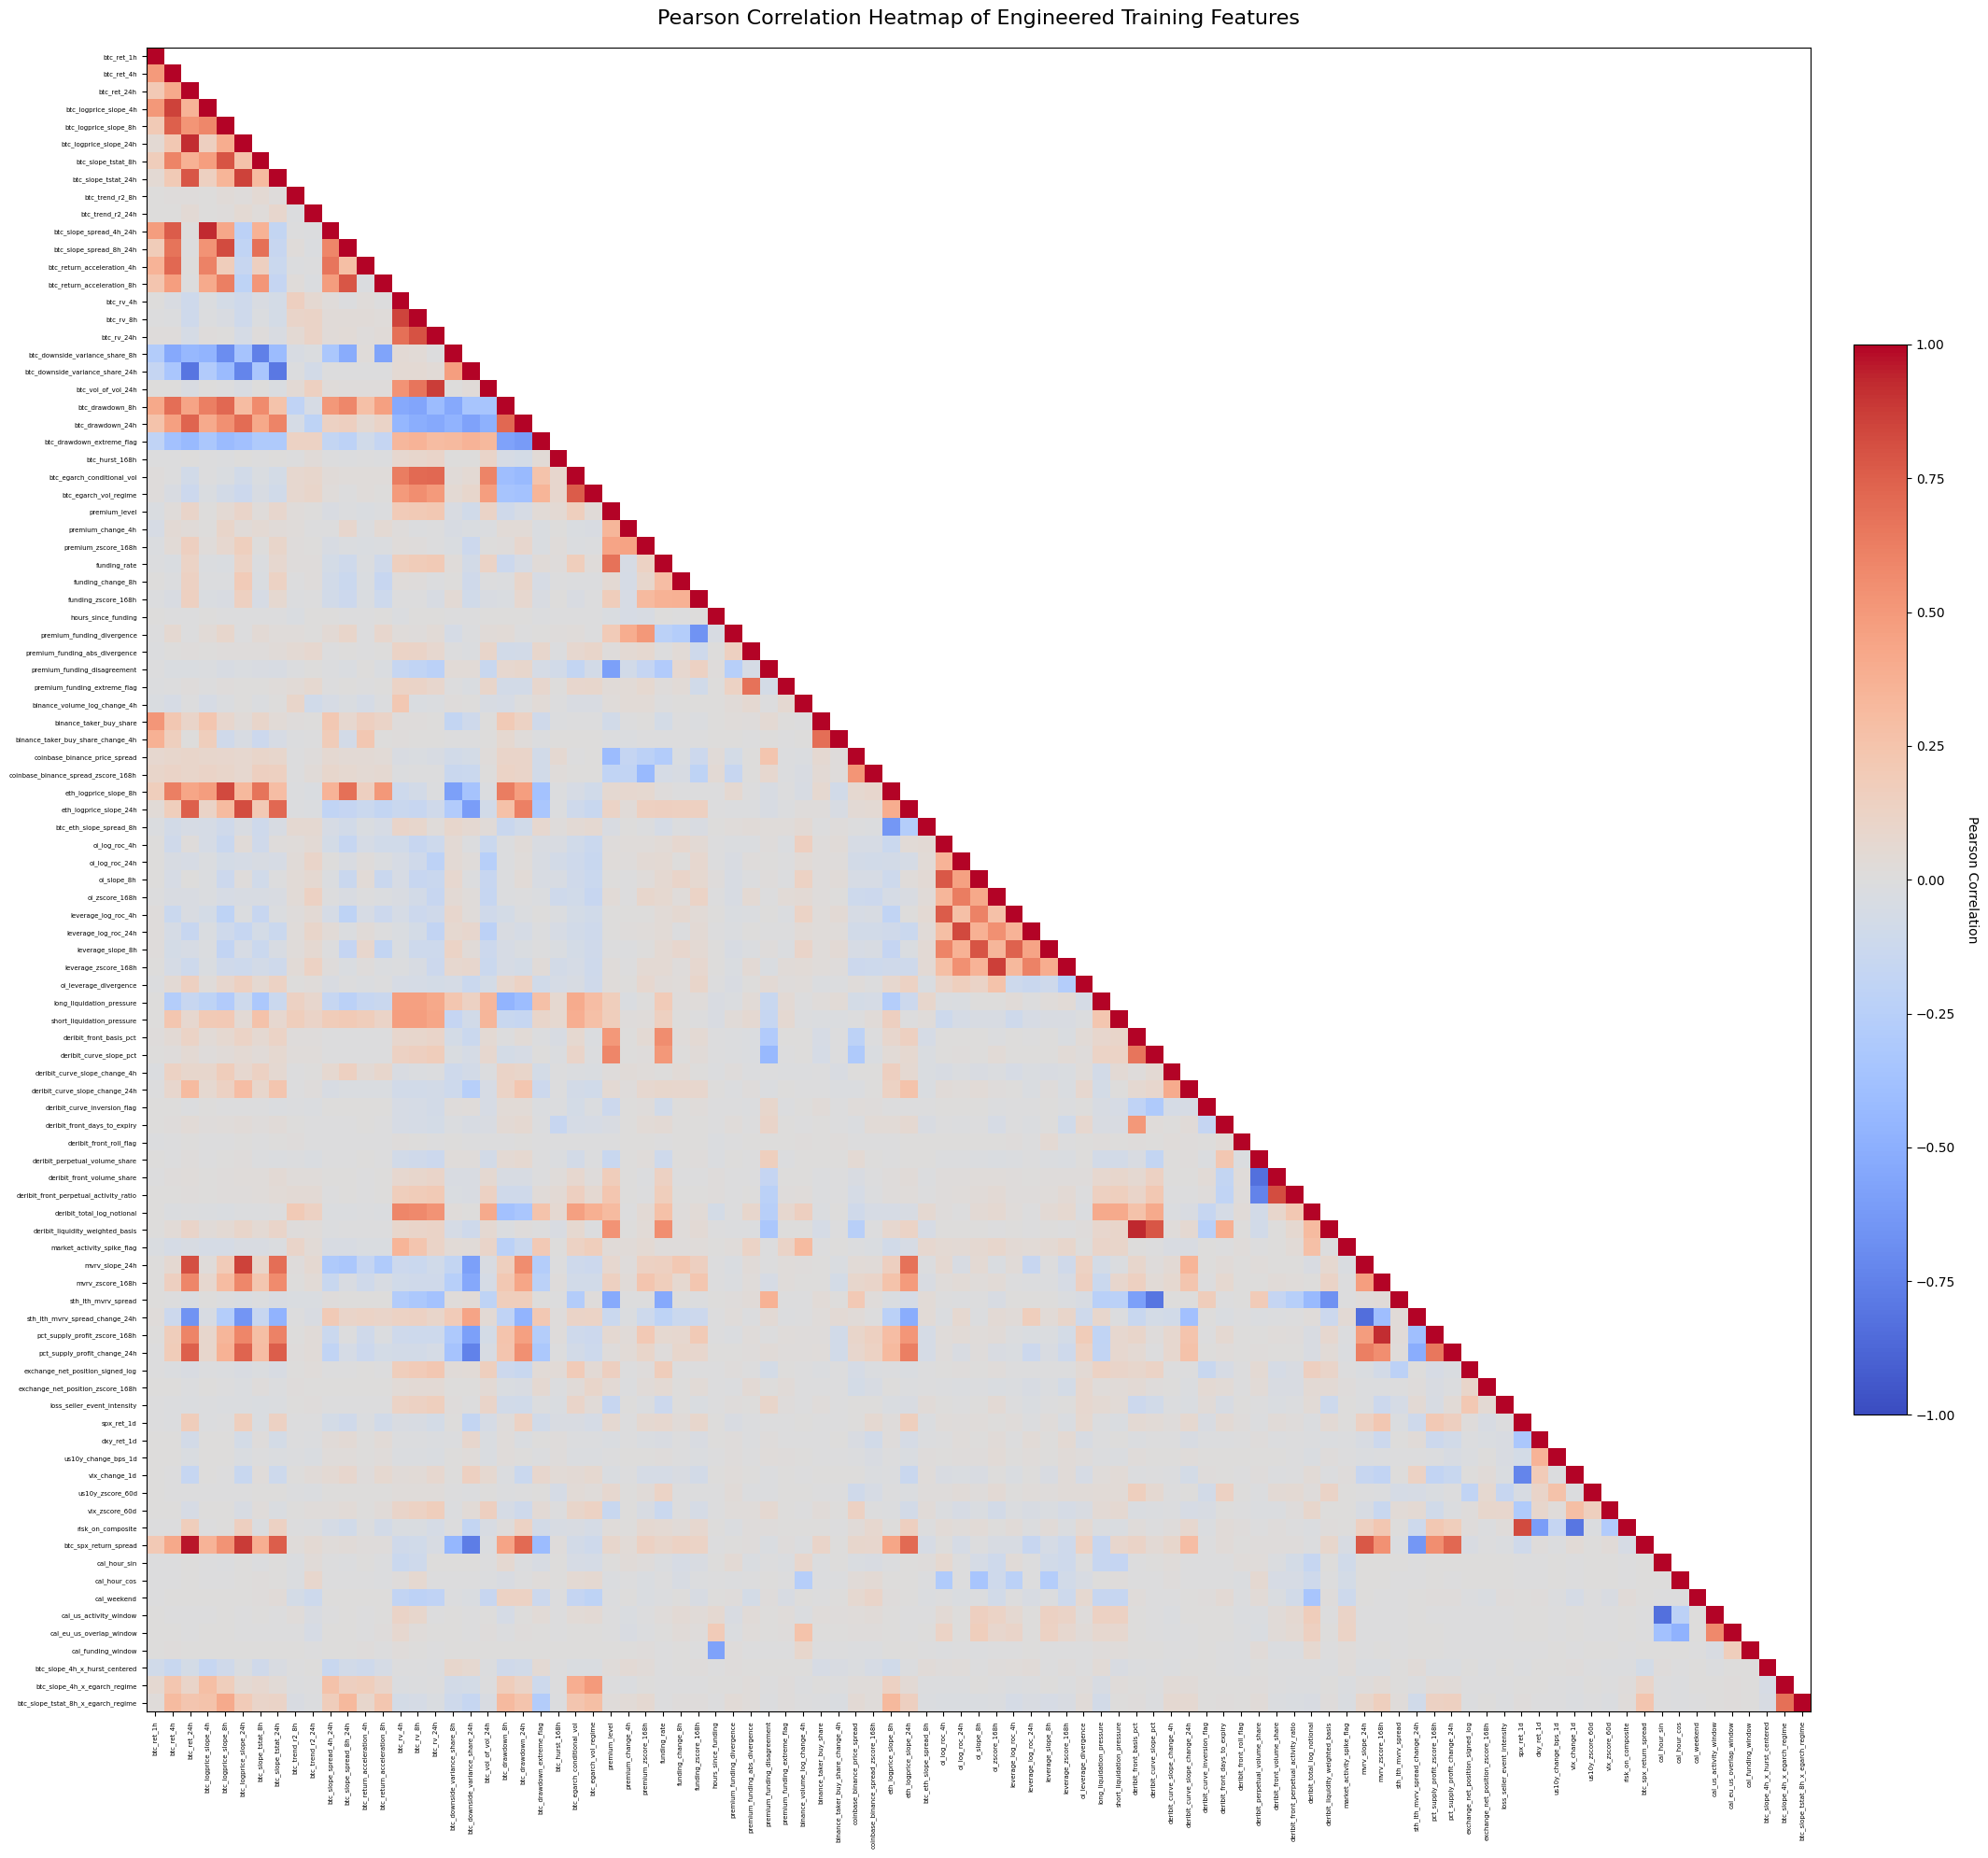

In [7]:
# Plot the complete feature-to-feature Pearson correlation heatmap
# Plot the lower triangle of the complete feature-to-feature Pearson correlation matrix
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
feature_corr_plot = np.ma.masked_where(upper_mask, feature_corr.to_numpy())

fig, ax = plt.subplots(figsize=(24, 20))
heatmap = ax.imshow(feature_corr_plot, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.index)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=5)
ax.set_yticklabels(feature_corr.index, fontsize=5)
ax.set_title("Pearson Correlation Heatmap of Engineered Training Features", fontsize=16, pad=18)

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

The correlation heatmap does not show widespread high-correlation clustering across the full feature set. Strong relationships are concentrated mainly within economically related groups, particularly BTC trend/momentum, volatility, and some on-chain or term-structure features. Most cross-family correlations appear weak to moderate, suggesting that the engineered matrix contains substantial complementary information rather than being dominated by broad multicollinearity.

In [8]:
# Identify only highly correlated feature pairs
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

high_corr_pairs = feature_corr.where(upper_mask).stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs.loc[high_corr_pairs["abs_correlation"] >= 0.90]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print("Feature pairs with |correlation| >= 0.90:", len(high_corr_pairs))
display(high_corr_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Feature pairs with |correlation| >= 0.90: 5


,feature_1,feature_2,correlation,abs_correlation
0,btc_ret_24h,btc_spx_return_spread,0.9640,0.9640
1,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9310,0.9310
2,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9287,0.9287
3,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
4,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148


In [9]:
# Remove structurally redundant engineered features
correlation_drop_features = [
    "btc_spx_return_spread",
    "btc_slope_spread_4h_24h",
    "deribit_front_basis_pct"]

assert set(correlation_drop_features).issubset(X_train_engineered.columns), "One or more selected features are missing."
X_train_corr_trimmed = X_train_engineered.drop(columns=correlation_drop_features).copy()

print("Original feature count:", X_train_engineered.shape[1])
print("Features removed:", len(correlation_drop_features))
print("Remaining feature count:", X_train_corr_trimmed.shape[1])
print("Removed features:", correlation_drop_features)

remaining_corr = X_train_corr_trimmed.corr(method="pearson")
upper_mask = np.triu(np.ones(remaining_corr.shape, dtype=bool), k=1)
remaining_pairs = remaining_corr.where(upper_mask).stack().reset_index()
remaining_pairs.columns = ["feature_1", "feature_2", "correlation"]
remaining_pairs["abs_correlation"] = remaining_pairs["correlation"].abs()
remaining_pairs = remaining_pairs.loc[remaining_pairs["abs_correlation"] >= 0.90]
remaining_pairs = remaining_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print("Remaining pairs with |correlation| >= 0.90:", len(remaining_pairs))
display(remaining_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Original feature count: 95
Features removed: 3
Remaining feature count: 92
Removed features: ['btc_spx_return_spread', 'btc_slope_spread_4h_24h', 'deribit_front_basis_pct']
Remaining pairs with |correlation| >= 0.90: 2


,feature_1,feature_2,correlation,abs_correlation
0,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
1,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148


These three features are removed because each is largely a constructed or narrower version of information already retained elsewhere. btc_spx_return_spread is dominated by the BTC 24-hour return component, btc_slope_spread_4h_24h is mechanically derived from the underlying slope features, and deribit_front_basis_pct is closely replicated by the broader liquidity-weighted basis measure. Removing them reduces redundancy without materially narrowing the economic information available to the models.

## **ii) VIF**

In [10]:
# Calculate VIF after structural correlation pruning
from sklearn.preprocessing import StandardScaler

X_vif = pd.DataFrame(
    StandardScaler().fit_transform(X_train_corr_trimmed),
    index=X_train_corr_trimmed.index,
    columns=X_train_corr_trimmed.columns)

inverse_corr = np.linalg.pinv(X_vif.corr().to_numpy())
vif_results = pd.DataFrame({"feature": X_vif.columns, "VIF": np.diag(inverse_corr)})
vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

high_vif_features = vif_results.loc[vif_results["VIF"] > 30].copy()

print("Features assessed:", len(vif_results))
print("Features with VIF > 30:", len(high_vif_features))
display(high_vif_features.style.format({"VIF": "{:.2f}"}))

Features assessed: 92
Features with VIF > 30: 1


,feature,VIF
0,btc_ret_4h,65.52


Only btc_ret_4h exceeded the conservative VIF threshold of 30. Its elevated VIF reflects overlap with other short-term return and trend predictors. Because it remains a direct and interpretable momentum measure, it was retained for nonlinear feature selection and the L2-regularized logistic baseline.

## **iIi) Boruta**

In [11]:
# Run Boruta using the locked ±0.05% dead zone
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import time

RETURN_THRESHOLD = 0.0005
BORUTA_MATRIX_PATH = DATA_PATH / "X_train_boruta_inclusive_4h.csv"
BORUTA_TARGET_PATH = DATA_PATH / "y_train_boruta_4h.csv"

targets_train = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
targets_train.index = pd.to_datetime(targets_train.index, utc=True)
targets_train = targets_train.sort_index()

common_index = X_train_corr_trimmed.index.intersection(targets_train.index)
X_boruta = X_train_corr_trimmed.loc[common_index].copy()
fwd_ret_4h = targets_train.loc[common_index, "fwd_logret_4h"].copy()

keep_mask = fwd_ret_4h.abs() > RETURN_THRESHOLD
X_boruta = X_boruta.loc[keep_mask].copy()
y_boruta = (fwd_ret_4h.loc[keep_mask] > 0).astype(int).rename("target_4h")

assert X_boruta.index.equals(y_boruta.index), "Feature and target timestamps are not aligned."
assert X_boruta.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(X_boruta.to_numpy()).all(), "Infinite values detected."
assert y_boruta.nunique() == 2, "Target must contain both classes."

print("Boruta observations:", len(X_boruta))
print("Boruta features:", X_boruta.shape[1])
print("Positive-class proportion:", f"{y_boruta.mean() * 100:.2f}%")

rf = RandomForestClassifier(max_depth=5, min_samples_leaf=20, max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", max_iter=100, perc=100, alpha=0.05, two_step=True, random_state=42, verbose=2)

start_time = time.time()
boruta.fit(X_boruta.to_numpy(), y_boruta.to_numpy())
runtime_minutes = (time.time() - start_time) / 60

boruta_results = pd.DataFrame({
    "feature": X_boruta.columns,
    "confirmed": boruta.support_,
    "tentative": boruta.support_weak_,
    "ranking": boruta.ranking_
})

boruta_results = boruta_results.sort_values(["confirmed", "tentative", "ranking"], ascending=[False, False, True]).reset_index(drop=True)

confirmed_features = boruta_results.loc[boruta_results["confirmed"], "feature"].tolist()
tentative_features = boruta_results.loc[boruta_results["tentative"], "feature"].tolist()
rejected_features = boruta_results.loc[~boruta_results["confirmed"] & ~boruta_results["tentative"], "feature"].tolist()

inclusive_features = confirmed_features + tentative_features
X_train_boruta_inclusive = X_boruta[inclusive_features].copy()

X_train_boruta_inclusive.to_csv(BORUTA_MATRIX_PATH, index=True, index_label="timestamp")
y_boruta.to_frame().to_csv(BORUTA_TARGET_PATH, index=True, index_label="timestamp")

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Confirmed features:", len(confirmed_features))
print("Tentative features:", len(tentative_features))
print("Rejected features:", len(rejected_features))
print("Inclusive matrix shape:", X_train_boruta_inclusive.shape)

display(boruta_results)

Boruta observations: 37921
Boruta features: 92
Positive-class proportion: 51.28%
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	54
Tentative: 	18
Rejected: 	20
Iteration: 	9 / 100
Confirmed: 	54
Tentative: 	18
Rejected: 	20
Iteration: 	10 / 100
Confirmed: 	54
Tentative: 	18
Rejected: 	20
Iteration: 	11 / 100
Confirmed: 	54
Tentative: 	18
Rejected: 	20
Iteration: 	12 / 100
Confirmed: 	55
Tentative: 	17
Rejected: 	20
Iteration: 	13 / 100
Confirmed: 	55
Tentative: 	17
Rejected: 	20
Iteration: 	14 / 100
Confirmed: 	55
Tentative: 	17
Rejected: 	20
Iteration: 	15 / 100
Confirmed: 

,feature,confirmed,tentative,ranking
0,btc_ret_1h,True,False,1
1,btc_ret_4h,True,False,1
2,btc_ret_24h,True,False,1
3,btc_logprice_slope_4h,True,False,1
4,btc_logprice_slope_8h,True,False,1
...,...,...,...,...
87,cal_eu_us_overlap_window,False,False,22
88,premium_funding_extreme_flag,False,False,23
89,cal_funding_window,False,False,24
90,deribit_curve_inversion_flag,False,False,25


In [15]:
# Train an internal XGBoost model for SHAP analysis
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

X_shap_all = X_train_boruta_inclusive.copy()
y_shap_all = y_boruta.loc[X_shap_all.index].copy()

split_index = int(len(X_shap_all) * 0.80)
purge_hours = 4

X_shap_train = X_shap_all.iloc[:split_index - purge_hours].copy()
X_shap_valid = X_shap_all.iloc[split_index:].copy()
y_shap_train = y_shap_all.iloc[:split_index - purge_hours].copy()
y_shap_valid = y_shap_all.iloc[split_index:].copy()

print("SHAP input features:", X_shap_all.shape[1])
print("Training shape:", X_shap_train.shape)
print("Validation shape:", X_shap_valid.shape)
print("Training range:", X_shap_train.index.min(), "to", X_shap_train.index.max())
print("Validation range:", X_shap_valid.index.min(), "to", X_shap_valid.index.max())

shap_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    tree_method="hist",
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
shap_model.fit(X_shap_train, y_shap_train, eval_set=[(X_shap_valid, y_shap_valid)], verbose=False)
runtime_minutes = (time.time() - start_time) / 60

valid_probability = shap_model.predict_proba(X_shap_valid)[:, 1]
valid_prediction = (valid_probability >= 0.50).astype(int)

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Best boosting round:", shap_model.best_iteration)
print("Validation accuracy:", f"{accuracy_score(y_shap_valid, valid_prediction):.4f}")
print("Validation balanced accuracy:", f"{balanced_accuracy_score(y_shap_valid, valid_prediction):.4f}")
print("Validation ROC-AUC:", f"{roc_auc_score(y_shap_valid, valid_probability):.4f}")

X_shap_sample = X_shap_valid.sample(n=min(5000, len(X_shap_valid)), random_state=42).sort_index()

print("Rows selected for SHAP:", len(X_shap_sample))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_shap_valid, valid_prediction), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

display(classification_report(y_shap_valid, valid_prediction, digits=4))

SHAP input features: 68
Training shape: (30332, 68)
Validation shape: (7585, 68)
Training range: 2020-07-29 00:00:00+00:00 to 2024-04-08 12:00:00+00:00
Validation range: 2024-04-08 21:00:00+00:00 to 2025-03-12 08:00:00+00:00
Runtime in minutes: 0.20
Best boosting round: 65
Validation accuracy: 0.5354
Validation balanced accuracy: 0.5335
Validation ROC-AUC: 0.5520
Rows selected for SHAP: 5000
Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,1712,1979
Actual 1,1545,2349


              precision    recall  f1-score   support

           0     0.5256    0.4638    0.4928      3691
           1     0.5427    0.6032    0.5714      3894

    accuracy                         0.5354      7585
   macro avg     0.5342    0.5335    0.5321      7585
weighted avg     0.5344    0.5354    0.5332      7585



## **iv) SHAP Analysis and Ranking on Boruta Surviving Features**

In [19]:
# Calculate SHAP values and rank the Boruta-surviving features
import shap

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_values = np.asarray(shap_values)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_ranking = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_ranking["rank"] = np.arange(1, len(shap_ranking) + 1)
shap_ranking["shap_share"] = shap_ranking["mean_abs_shap"] / shap_ranking["mean_abs_shap"].sum()
shap_ranking["cumulative_shap_share"] = shap_ranking["shap_share"].cumsum()

features_to_80pct = (shap_ranking["cumulative_shap_share"] < 0.80).sum() + 1
features_to_90pct = (shap_ranking["cumulative_shap_share"] < 0.90).sum() + 1

SHAP_RANKING_PATH = DATA_PATH / "shap_feature_ranking_4h.csv"
shap_ranking.to_csv(SHAP_RANKING_PATH, index=False)

print("SHAP input features:", len(shap_ranking))
print("Features required for 80% cumulative SHAP:", features_to_80pct)
print("Features required for 90% cumulative SHAP:", features_to_90pct)
print("Top 20 SHAP share:", f"{shap_ranking.head(20)['shap_share'].sum() * 100:.2f}%")
print("Top 30 SHAP share:", f"{shap_ranking.head(30)['shap_share'].sum() * 100:.2f}%")
print("Saved SHAP ranking to:", SHAP_RANKING_PATH)

display(shap_ranking.head(40).style.format({
    "mean_abs_shap": "{:.6f}",
    "shap_share": "{:.2%}",
    "cumulative_shap_share": "{:.2%}"
}))

SHAP input features: 68
Features required for 80% cumulative SHAP: 26
Features required for 90% cumulative SHAP: 39
Top 20 SHAP share: 74.15%
Top 30 SHAP share: 84.02%
Saved SHAP ranking to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/shap_feature_ranking_4h.csv


,feature,mean_abs_shap,rank,shap_share,cumulative_shap_share
0,btc_ret_4h,0.062637,1,12.00%,12.00%
1,btc_logprice_slope_4h,0.045387,2,8.70%,20.70%
2,coinbase_binance_spread_zscore_168h,0.030833,3,5.91%,26.61%
3,btc_slope_tstat_8h,0.029956,4,5.74%,32.35%
4,btc_drawdown_8h,0.028045,5,5.37%,37.73%
5,btc_drawdown_24h,0.024125,6,4.62%,42.35%
6,btc_ret_24h,0.023219,7,4.45%,46.80%
7,btc_downside_variance_share_24h,0.020154,8,3.86%,50.66%
8,leverage_log_roc_24h,0.015805,9,3.03%,53.69%
9,btc_ret_1h,0.015731,10,3.01%,56.71%


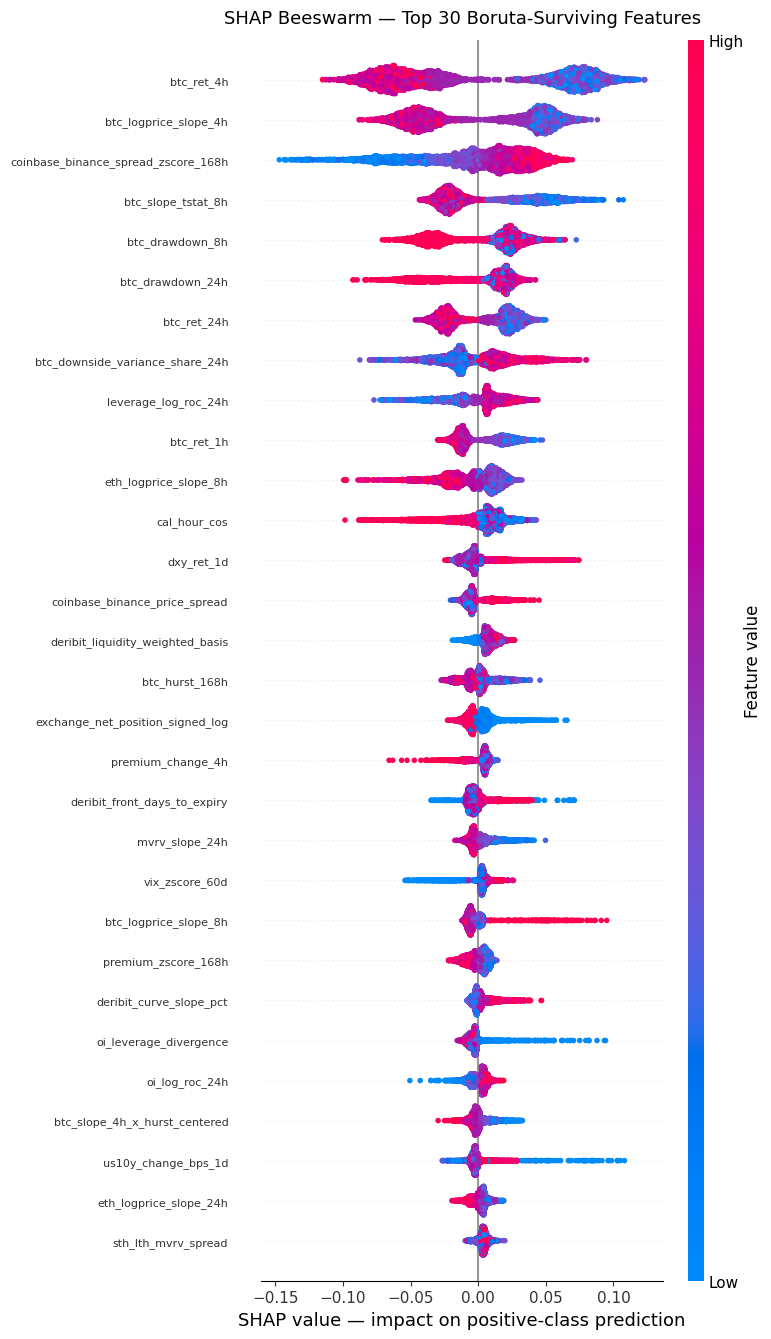

In [18]:
# Plot the SHAP beeswarm summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="dot", max_display=30, show=False)

plt.title("SHAP Beeswarm — Top 30 Boruta-Surviving Features", fontsize=13, pad=12)
plt.xlabel("SHAP value — impact on positive-class prediction")
plt.gca().tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

The SHAP results show that predictive importance is concentrated in a manageable core of features while remaining diversified across price, risk, derivatives, cross-asset and on-chain information. Short-term BTC momentum remains dominant, but the model is not solely dependent on mechanically related price transformations.

## **v) Bourta Survived Features Tournament for Final Selection**

Boruta retained 68 features, but carrying all of them into modelling may still introduce unnecessary noise, unstable importance and greater overfitting risk. A feature-set tournament is therefore used to compare several defensible subsets under the same chronological validation framework and determine whether a more compact set performs as well as, or better than, the full Boruta set. Elastic Net is included because it combines L1 feature sparsity with L2 stability, making it well suited to selecting among correlated predictors while providing a linear alternative to the tree-based Boruta and SHAP rankings.

In [20]:
# Rank features using Elastic Net stability across chronological folds
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

TARGET_FEATURES = 30
CS = [0.01, 0.05, 0.20, 1.00]
L1_RATIOS = [0.25, 0.50, 0.75]
MAX_ITER = 3000
ZERO_TOL = 1e-6

tuning_cv = TimeSeriesSplit(n_splits=3, gap=4)

elastic_net_cv = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=CS,
        cv=tuning_cv,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=L1_RATIOS,
        scoring="roc_auc",
        max_iter=MAX_ITER,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    ))

start_time = time.time()
elastic_net_cv.fit(X_shap_train, y_shap_train)
runtime_minutes = (time.time() - start_time) / 60

cv_model = elastic_net_cv.named_steps["logisticregressioncv"]
best_c = float(cv_model.C_[0])
best_l1_ratio = float(cv_model.l1_ratio_[0])

fold_coefficients = []

for fold, (train_idx, _) in enumerate(TimeSeriesSplit(n_splits=5, gap=4).split(X_shap_train), start=1):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_c,
            l1_ratio=best_l1_ratio,
            max_iter=MAX_ITER,
            tol=1e-3,
            random_state=42))

    model.fit(X_shap_train.iloc[train_idx], y_shap_train.iloc[train_idx])
    coefficients = model.named_steps["logisticregression"].coef_.ravel()
    fold_coefficients.append(pd.Series(coefficients, index=X_shap_train.columns, name=f"fold_{fold}"))

fold_coefficients = pd.concat(fold_coefficients, axis=1)
nonzero = fold_coefficients.abs() > ZERO_TOL

selection_frequency = nonzero.mean(axis=1)
median_abs_coefficient = fold_coefficients.abs().median(axis=1)

def sign_consistency(row):
    row = row[row.abs() > ZERO_TOL]
    return 0 if row.empty else max((row > 0).mean(), (row < 0).mean())

elastic_net_ranking = pd.DataFrame({
    "feature": X_shap_train.columns,
    "selection_frequency": selection_frequency,
    "sign_consistency": fold_coefficients.apply(sign_consistency, axis=1),
    "median_abs_coefficient": median_abs_coefficient
})

elastic_net_ranking = elastic_net_ranking.sort_values(
    ["selection_frequency", "sign_consistency", "median_abs_coefficient"],
    ascending=False
).reset_index(drop=True)

elastic_net_ranking["rank"] = np.arange(1, len(elastic_net_ranking) + 1)
elastic_net_features = elastic_net_ranking.head(TARGET_FEATURES)["feature"].tolist()

ELASTIC_NET_RANKING_PATH = DATA_PATH / "elastic_net_stability_ranking_4h.csv"
ELASTIC_NET_FEATURES_PATH = DATA_PATH / "elastic_net_selected_features_30_4h.csv"

elastic_net_ranking.to_csv(ELASTIC_NET_RANKING_PATH, index=False)
pd.DataFrame({"feature": elastic_net_features}).to_csv(ELASTIC_NET_FEATURES_PATH, index=False)

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Best C:", best_c)
print("Best L1 ratio:", best_l1_ratio)
print("Selected features:", len(elastic_net_features))

display(elastic_net_ranking.head(40).style.format({
    "selection_frequency": "{:.2f}",
    "sign_consistency": "{:.2f}",
    "median_abs_coefficient": "{:.6f}"}))

Runtime in minutes: 3.28
Best C: 0.05
Best L1 ratio: 0.75
Selected features: 30


,feature,selection_frequency,sign_consistency,median_abs_coefficient,rank
0,btc_logprice_slope_24h,1.00,1.00,0.346411,1
1,btc_slope_tstat_8h,1.00,1.00,0.227399,2
2,btc_logprice_slope_8h,1.00,1.00,0.204728,3
3,btc_ret_24h,1.00,1.00,0.139365,4
4,btc_drawdown_24h,1.00,1.00,0.114030,5
5,eth_logprice_slope_24h,1.00,1.00,0.096499,6
6,leverage_log_roc_24h,1.00,1.00,0.083990,7
7,btc_vol_of_vol_24h,1.00,1.00,0.052766,8
8,cal_hour_cos,1.00,1.00,0.052579,9
9,btc_return_acceleration_4h,1.00,1.00,0.048949,10


Elastic Net identified a stable 30-feature candidate set dominated by recent BTC trend, momentum and risk conditions, with complementary information from leverage, open interest, ETH, macro markets, derivatives and on-chain activity. This composition is consistent with the short four-hour forecast horizon, while still retaining broader market-state variables that may improve robustness beyond price-only signals.

In [22]:
# Compare six candidate feature sets with the same chronological L2 logistic tournament
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_sets = {
    "SHAP top 20": shap_ranking.head(20)["feature"].tolist(),
    "SHAP 80%": shap_ranking.head(features_to_80pct)["feature"].tolist(),
    "Elastic Net top 30": elastic_net_features,
    "SHAP 90%": shap_ranking.head(features_to_90pct)["feature"].tolist(),
    "Boruta confirmed": confirmed_features,
    "Boruta inclusive": X_train_boruta_inclusive.columns.tolist()}

tournament_results = []
cv = TimeSeriesSplit(n_splits=5)

for set_name, features in feature_sets.items():
    fold_scores = []

    for train_idx, valid_idx in cv.split(X_boruta):
        valid_start = X_boruta.index[valid_idx[0]]
        train_idx = train_idx[X_boruta.index[train_idx] < valid_start - pd.Timedelta(hours=4)]

        X_train_fold = X_boruta.iloc[train_idx][features]
        X_valid_fold = X_boruta.iloc[valid_idx][features]
        y_train_fold = y_boruta.iloc[train_idx]
        y_valid_fold = y_boruta.iloc[valid_idx]

        model = make_pipeline(StandardScaler(), LogisticRegression(penalty="l2", C=1.0, max_iter=2000, random_state=42))
        model.fit(X_train_fold, y_train_fold)

        probability = model.predict_proba(X_valid_fold)[:, 1]
        prediction = (probability >= 0.50).astype(int)

        fold_scores.append({
            "roc_auc": roc_auc_score(y_valid_fold, probability),
            "balanced_accuracy": balanced_accuracy_score(y_valid_fold, prediction)})

    fold_scores = pd.DataFrame(fold_scores)

    tournament_results.append({
        "feature_set": set_name,
        "features": len(features),
        "mean_roc_auc": fold_scores["roc_auc"].mean(),
        "std_roc_auc": fold_scores["roc_auc"].std(),
        "mean_balanced_accuracy": fold_scores["balanced_accuracy"].mean(),
        "std_balanced_accuracy": fold_scores["balanced_accuracy"].std()})

tournament_results = pd.DataFrame(tournament_results)
tournament_results = tournament_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

display(tournament_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

,feature_set,features,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,Elastic Net top 30,30,0.5584,0.0185,0.5414,0.0138
1,Boruta confirmed,66,0.5551,0.0195,0.5365,0.0154
2,Boruta inclusive,68,0.5543,0.0196,0.5373,0.0164
3,SHAP 80%,26,0.5541,0.0202,0.5366,0.0205
4,SHAP 90%,39,0.5527,0.0159,0.5367,0.0157
5,SHAP top 20,20,0.5474,0.0165,0.5307,0.0170


The feature-set tournament selected the 30-feature Elastic Net stability subset. It achieved the highest mean ROC-AUC and balanced accuracy while using substantially fewer predictors than the Boruta-inclusive alternatives. This indicates that the broader feature set contained useful but partly redundant or noisy information, and that a compact combination of stable trend, momentum, volatility, derivatives, cross-asset and on-chain factors provides a stronger modelling foundation.

## **(VII) Model Training**

### **Part I) Training Model Data Pre-Processing**


**Construct the Locked 30-Feature Training Dataset**

This block converts the final engineered training matrix into the canonical model-ready training files. It selects the locked 30 features, aligns them with the 4-hour forward return, applies the ±0.05% dead zone, creates the binary target, and saves both the classification labels and continuous returns for later model evaluation and backtesting.

In [34]:
# Construct and save the locked 30-feature modelling dataset
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")
RETURN_THRESHOLD = 0.0005

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_model = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
targets = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])

X_model.index = pd.to_datetime(X_model.index, utc=True)
targets.index = pd.to_datetime(targets.index, utc=True)

X_model = X_model.sort_index()[selected_features]
targets = targets.sort_index()

fwd_return_model = targets["fwd_logret_4h"].reindex(X_model.index)
keep_mask = fwd_return_model.abs() > RETURN_THRESHOLD

X_model = X_model.loc[keep_mask].copy()
fwd_return_model = fwd_return_model.loc[keep_mask].rename("fwd_logret_4h")
y_model = (fwd_return_model > 0).astype(int).rename("target_4h")

X_model.reset_index().to_csv(DATA_PATH / "X_train_model_30_4h.csv", index=False)
y_model.reset_index().to_csv(DATA_PATH / "y_train_model_4h.csv", index=False)
fwd_return_model.reset_index().to_csv(DATA_PATH / "returns_train_model_4h.csv", index=False)

print("Final modelling observations:", f"{len(X_model):,}")
print("Final feature count:", X_model.shape[1])
print("Positive-class proportion:", f"{y_model.mean() * 100:.2f}%")
print("Date range:", X_model.index.min(), "to", X_model.index.max())

Final modelling observations: 37,921
Final feature count: 30
Positive-class proportion: 51.28%
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


### **Part II) Benchmark Model Comparison**

**Selection of Candidate Base-Model Families**

The benchmark comparison evaluates several structurally different classifiers before hyperparameter tuning. The objective is not simply to identify the strongest standalone model, but to determine which model families capture complementary aspects of the prediction problem and therefore provide suitable inputs to a heterogeneous ensemble.

The final dataset contains 30 engineered tabular predictors dominated by BTC trend, momentum and risk measures, with additional information from volatility regimes, leverage, open interest, derivatives, macro markets and on-chain activity. It therefore contains both approximately linear effects and potentially nonlinear interactions, thresholds and regime dependencies.

The candidate models are evaluated under the same chronological cross-validation procedure. Their untuned performance, stability and prediction disagreement will then be used to justify which models proceed to tuning and ensemble construction.


In [7]:
# check if Colab is running on GPU
!nvidia-smi

Sun Jul 19 11:39:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             13W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# Load the locked model-ready training data
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_model = pd.read_csv(DATA_PATH / "X_train_model_30_4h.csv", index_col="timestamp", parse_dates=["timestamp"])
y_model = pd.read_csv(DATA_PATH / "y_train_model_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).iloc[:, 0]
fwd_return_model = pd.read_csv(DATA_PATH / "returns_train_model_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).iloc[:, 0]

X_model.index = pd.to_datetime(X_model.index, utc=True)
y_model.index = pd.to_datetime(y_model.index, utc=True)
fwd_return_model.index = pd.to_datetime(fwd_return_model.index, utc=True)

X_model = X_model.sort_index()
y_model = y_model.reindex(X_model.index).astype(int).rename("target_4h")
fwd_return_model = fwd_return_model.reindex(X_model.index).rename("fwd_logret_4h")

print("Observations:", f"{len(X_model):,}")
print("Features:", X_model.shape[1])
print("Positive class:", f"{y_model.mean() * 100:.2f}%")
print("Date range:", X_model.index.min(), "to", X_model.index.max())

Observations: 37,921
Features: 30
Positive class: 51.28%
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


**i) L2 Logistics Regression**

In [9]:
# Evaluate the L2 logistic regression benchmark

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

l2_benchmark = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42))])

benchmark_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    l2_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = l2_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    benchmark_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)    })

benchmark_results = pd.DataFrame(benchmark_results)
print("L2 Logistic Regression Results")
display(benchmark_results.round(4))

print("Mean ROC-AUC:", f"{benchmark_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{benchmark_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{benchmark_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{benchmark_results['balanced_accuracy'].std():.4f}")

L2 Logistic Regression Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5501,0.5340
1,2,12637,6320,0.5551,0.5396
2,3,18957,6320,0.5821,0.5624
3,4,25277,6320,0.5706,0.5455
4,5,31597,6320,0.5342,0.5252


Mean ROC-AUC: 0.5584
ROC-AUC standard deviation: 0.0185
Mean balanced accuracy: 0.5414
Balanced accuracy standard deviation: 0.0139


**ii) Random Forest**

In [10]:
# Evaluate the untuned Random Forest benchmark
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

rf_benchmark = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    n_jobs=-1,
    random_state=42)

rf_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    rf_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = rf_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    rf_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)})

rf_results = pd.DataFrame(rf_results)
print("Random Forest Results")
display(rf_results.round(4))

print("Mean ROC-AUC:", f"{rf_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{rf_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{rf_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{rf_results['balanced_accuracy'].std():.4f}")

Random Forest Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5580,0.5395
1,2,12637,6320,0.5406,0.5210
2,3,18957,6320,0.5661,0.5456
3,4,25277,6320,0.5666,0.5477
4,5,31597,6320,0.5328,0.5248


Mean ROC-AUC: 0.5528
ROC-AUC standard deviation: 0.0154
Mean balanced accuracy: 0.5357
Balanced accuracy standard deviation: 0.0122


In [11]:
# Evaluate the untuned XGBoost benchmark
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

xgb_benchmark = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42)

xgb_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    xgb_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = xgb_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    xgb_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)})

xgb_results = pd.DataFrame(xgb_results)
print("XGBoost Results")
display(xgb_results.round(4))

print("Mean ROC-AUC:", f"{xgb_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{xgb_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{xgb_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{xgb_results['balanced_accuracy'].std():.4f}")

XGBoost Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5433,0.5344
1,2,12637,6320,0.5303,0.5212
2,3,18957,6320,0.5588,0.5417
3,4,25277,6320,0.5559,0.5433
4,5,31597,6320,0.5409,0.5254


Mean ROC-AUC: 0.5458
ROC-AUC standard deviation: 0.0117
Mean balanced accuracy: 0.5332
Balanced accuracy standard deviation: 0.0098


**iii) Cat Boost**

**CatBoost** was selected as the gradient-boosting model because it can capture nonlinear relationships, interaction effects and threshold behaviour within the engineered predictors. It was preferred to XGBoost because its ordered boosting framework is designed to reduce prediction shift and overfitting, which is particularly relevant for noisy and non-stationary financial data. This choice was also supported empirically: under the same chronological cross-validation procedure, CatBoost achieved higher mean ROC-AUC and balanced accuracy than XGBoost. Retaining CatBoost therefore provides a stronger representative of the gradient-boosting family without introducing two closely related boosting models into the ensemble.


In [14]:
#!pip install catboost

In [13]:
# Evaluate the untuned CatBoost benchmark
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

cat_benchmark = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    cat_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = cat_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    cat_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)
    })

cat_results = pd.DataFrame(cat_results)

print("CatBoost Results")
display(cat_results.round(4))

print("Mean ROC-AUC:", f"{cat_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{cat_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{cat_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{cat_results['balanced_accuracy'].std():.4f}")

CatBoost Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5494,0.5372
1,2,12637,6320,0.5455,0.5339
2,3,18957,6320,0.5504,0.5353
3,4,25277,6320,0.5737,0.5526
4,5,31597,6320,0.5422,0.5234


Mean ROC-AUC: 0.5522
ROC-AUC standard deviation: 0.0124
Mean balanced accuracy: 0.5365
Balanced accuracy standard deviation: 0.0105


**iv) RBF SVM**

In [15]:
# Evaluate the untuned RBF SVM benchmark
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

svm_benchmark = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])

svm_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    svm_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = svm_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    svm_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)})

svm_results = pd.DataFrame(svm_results)

print("RBF SVM Results")
display(svm_results.round(4))

print("Mean ROC-AUC:", f"{svm_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{svm_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{svm_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{svm_results['balanced_accuracy'].std():.4f}")

RBF SVM Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5522,0.5290
1,2,12637,6320,0.5438,0.5343
2,3,18957,6320,0.5671,0.5435
3,4,25277,6320,0.5724,0.5559
4,5,31597,6320,0.5328,0.5233


Mean ROC-AUC: 0.5537
ROC-AUC standard deviation: 0.0163
Mean balanced accuracy: 0.5372
Balanced accuracy standard deviation: 0.0129


**v) GRU (24 hour lookbark)**

In [16]:
# Evaluate an untuned GRU benchmark using a 24-hour lookback

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GRU, Input

N_SPLITS = 5
PURGE_GAP = 4
LOOKBACK = 24
EPOCHS = 30
BATCH_SIZE = 256

np.random.seed(42)
tf.random.set_seed(42)

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
gru_results = []

def make_sequences(X, y, lookback):
    X_seq, y_seq = [], []

    for i in range(lookback - 1, len(X)):
        X_seq.append(X[i - lookback + 1:i + 1])
        y_seq.append(y[i])

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx].copy()
    X_fold_valid = X_model.iloc[valid_idx].copy()
    y_fold_train = y_model.iloc[train_idx].copy()
    y_fold_valid = y_model.iloc[valid_idx].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_fold_train)
    X_valid_scaled = scaler.transform(X_fold_valid)

    X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_fold_train.to_numpy(), LOOKBACK)
    X_valid_seq, y_valid_seq = make_sequences(X_valid_scaled, y_fold_valid.to_numpy(), LOOKBACK)

    model = Sequential([
        Input(shape=(LOOKBACK, X_model.shape[1])),
        GRU(32),
        Dropout(0.20),
        Dense(1, activation="sigmoid")])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_valid_seq, y_valid_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    valid_probability = model.predict(X_valid_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
    valid_prediction = (valid_probability >= 0.5).astype(int)

    gru_results.append({
        "fold": fold,
        "train_rows": len(X_train_seq),
        "validation_rows": len(X_valid_seq),
        "roc_auc": roc_auc_score(y_valid_seq, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_valid_seq, valid_prediction)})

gru_results = pd.DataFrame(gru_results)

print("GRU 24-Hour Lookback Results")
display(gru_results.round(4))

print("Mean ROC-AUC:", f"{gru_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{gru_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{gru_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{gru_results['balanced_accuracy'].std():.4f}")

GRU 24-Hour Lookback Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6294,6297,0.5225,0.5129
1,2,12614,6297,0.5468,0.5321
2,3,18934,6297,0.5774,0.5595
3,4,25254,6297,0.5586,0.5390
4,5,31574,6297,0.5404,0.5291


Mean ROC-AUC: 0.5492
ROC-AUC standard deviation: 0.0205
Mean balanced accuracy: 0.5345
Balanced accuracy standard deviation: 0.0169


In [17]:
# Compare untuned base-model benchmark results

benchmark_comparison = pd.DataFrame([
    {
        "model": "L2 Logistic Regression",
        "family": "Linear",
        "mean_roc_auc": benchmark_results["roc_auc"].mean(),
        "std_roc_auc": benchmark_results["roc_auc"].std(),
        "mean_balanced_accuracy": benchmark_results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": benchmark_results["balanced_accuracy"].std()
    },
    {
        "model": "Random Forest",
        "family": "Bagged Trees",
        "mean_roc_auc": rf_results["roc_auc"].mean(),
        "std_roc_auc": rf_results["roc_auc"].std(),
        "mean_balanced_accuracy": rf_results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": rf_results["balanced_accuracy"].std()
    },
    {
        "model": "CatBoost",
        "family": "Gradient Boosting",
        "mean_roc_auc": cat_results["roc_auc"].mean(),
        "std_roc_auc": cat_results["roc_auc"].std(),
        "mean_balanced_accuracy": cat_results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": cat_results["balanced_accuracy"].std()
    },
    {
        "model": "RBF SVM",
        "family": "Kernel",
        "mean_roc_auc": svm_results["roc_auc"].mean(),
        "std_roc_auc": svm_results["roc_auc"].std(),
        "mean_balanced_accuracy": svm_results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": svm_results["balanced_accuracy"].std()
    },
    {
        "model": "GRU 24h",
        "family": "Sequential Neural Network",
        "mean_roc_auc": gru_results["roc_auc"].mean(),
        "std_roc_auc": gru_results["roc_auc"].std(),
        "mean_balanced_accuracy": gru_results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": gru_results["balanced_accuracy"].std()
    }
])

benchmark_comparison = benchmark_comparison.sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)

print("Untuned Base-Model Benchmark Comparison")
display(benchmark_comparison.round(4))

Untuned Base-Model Benchmark Comparison


,model,family,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,L2 Logistic Regression,Linear,0.5584,0.0185,0.5414,0.0139
1,RBF SVM,Kernel,0.5537,0.0163,0.5372,0.0129
2,Random Forest,Bagged Trees,0.5528,0.0154,0.5357,0.0122
3,CatBoost,Gradient Boosting,0.5522,0.0124,0.5365,0.0105
4,GRU 24h,Sequential Neural Network,0.5492,0.0205,0.5345,0.0169


### **Part III: Hyperparameter Tuning of Shortlisted Base Learners**

**a) Tune all short-listed Base Learners**

In [19]:
# Tune and save L2 logistic regression with progress and resume support
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

N_SPLITS = 5
PURGE_GAP = 4
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
L2_RESULTS_PATH = DATA_PATH / "l2_tuning_results_4h.csv"

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

if L2_RESULTS_PATH.exists():
    l2_tuning_results = pd.read_csv(L2_RESULTS_PATH)
else:
    l2_tuning_results = pd.DataFrame()

completed_C = set(l2_tuning_results["C"].astype(float)) if not l2_tuning_results.empty else set()
pending_C = [C for C in C_GRID if float(C) not in completed_C]

print(f"Completed configurations: {len(completed_C)}/{len(C_GRID)}")
print(f"Remaining configurations: {len(pending_C)}")

for C in tqdm(pending_C, desc="L2 tuning", unit="configuration"):
    start_time = time.time()
    fold_auc = []
    fold_bal_acc = []

    print(f"\nRunning C={C}")

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                C=C,
                solver="lbfgs",
                max_iter=2000,
                random_state=42
            ))
        ])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        valid_probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc.append(roc_auc_score(y_model.iloc[valid_idx], valid_probability))
        fold_bal_acc.append(balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction))

        print(
            f"  Fold {fold}/{N_SPLITS} | "
            f"ROC-AUC={fold_auc[-1]:.4f} | "
            f"Balanced accuracy={fold_bal_acc[-1]:.4f}"
        )

    result = pd.DataFrame([{
        "C": C,
        "mean_roc_auc": np.mean(fold_auc),
        "std_roc_auc": np.std(fold_auc, ddof=1),
        "mean_balanced_accuracy": np.mean(fold_bal_acc),
        "std_balanced_accuracy": np.std(fold_bal_acc, ddof=1),
        "runtime_seconds": time.time() - start_time
    }])

    l2_tuning_results = pd.concat([l2_tuning_results, result], ignore_index=True)
    l2_tuning_results = l2_tuning_results.drop_duplicates(subset=["C"], keep="last")
    l2_tuning_results.to_csv(L2_RESULTS_PATH, index=False)

    print(
        f"Saved C={C} | "
        f"ROC-AUC={result.loc[0, 'mean_roc_auc']:.4f} | "
        f"Balanced accuracy={result.loc[0, 'mean_balanced_accuracy']:.4f}"
    )

l2_tuning_results = pd.read_csv(L2_RESULTS_PATH)
l2_tuning_results = l2_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

best_l2_C = float(l2_tuning_results.loc[0, "C"])

print("\nL2 Logistic Regression Tuning Results")
display(l2_tuning_results.round(4))
print("Selected C:", best_l2_C)
print("Saved to:", L2_RESULTS_PATH)

Completed configurations: 0/6
Remaining configurations: 6


L2 tuning:   0%|          | 0/6 [00:00<?, ?configuration/s]


Running C=0.001
  Fold 1/5 | ROC-AUC=0.5455 | Balanced accuracy=0.5239
  Fold 2/5 | ROC-AUC=0.5539 | Balanced accuracy=0.5319
  Fold 3/5 | ROC-AUC=0.5753 | Balanced accuracy=0.5559
  Fold 4/5 | ROC-AUC=0.5608 | Balanced accuracy=0.5420
  Fold 5/5 | ROC-AUC=0.5331 | Balanced accuracy=0.5186
Saved C=0.001 | ROC-AUC=0.5537 | Balanced accuracy=0.5345

Running C=0.01
  Fold 1/5 | ROC-AUC=0.5461 | Balanced accuracy=0.5302
  Fold 2/5 | ROC-AUC=0.5548 | Balanced accuracy=0.5402
  Fold 3/5 | ROC-AUC=0.5803 | Balanced accuracy=0.5604
  Fold 4/5 | ROC-AUC=0.5679 | Balanced accuracy=0.5438
  Fold 5/5 | ROC-AUC=0.5343 | Balanced accuracy=0.5224
Saved C=0.01 | ROC-AUC=0.5567 | Balanced accuracy=0.5394

Running C=0.1
  Fold 1/5 | ROC-AUC=0.5495 | Balanced accuracy=0.5325
  Fold 2/5 | ROC-AUC=0.5551 | Balanced accuracy=0.5400
  Fold 3/5 | ROC-AUC=0.5819 | Balanced accuracy=0.5613
  Fold 4/5 | ROC-AUC=0.5703 | Balanced accuracy=0.5452
  Fold 5/5 | ROC-AUC=0.5343 | Balanced accuracy=0.5252
Saved C=0.1 

,C,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy,runtime_seconds
0,100.000,0.5584,0.0185,0.5415,0.0138,1.4842
1,10.000,0.5584,0.0185,0.5415,0.0138,1.3589
2,1.000,0.5584,0.0185,0.5414,0.0139,1.8806
3,0.100,0.5582,0.0185,0.5408,0.0137,1.7653
4,0.010,0.5567,0.0180,0.5394,0.0144,1.5546
5,0.001,0.5537,0.0159,0.5345,0.0149,0.8700


Selected C: 100.0
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/l2_tuning_results_4h.csv


In [20]:
# Tune CatBoost with GPU, fold-level progress and Drive checkpoints
from itertools import product
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from tqdm.auto import tqdm

N_SPLITS = 5
PURGE_GAP = 4

DEPTH_GRID = [4, 6, 8]
LEARNING_RATE_GRID = [0.01, 0.03, 0.1]
L2_GRID = [3, 10]
ITERATIONS_GRID = [300, 600]

CAT_FOLD_PATH = DATA_PATH / "catboost_tuning_fold_checkpoint_4h.csv"
CAT_RESULTS_PATH = DATA_PATH / "catboost_tuning_results_4h.csv"

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
parameter_grid = list(product(DEPTH_GRID, LEARNING_RATE_GRID, L2_GRID, ITERATIONS_GRID))

if CAT_FOLD_PATH.exists():
    cat_fold_results = pd.read_csv(CAT_FOLD_PATH)
else:
    cat_fold_results = pd.DataFrame(columns=[
        "depth", "learning_rate", "l2_leaf_reg", "iterations",
        "fold", "roc_auc", "balanced_accuracy"])

completed_folds = set()

if not cat_fold_results.empty:
    completed_folds = set(zip(
        cat_fold_results["depth"].astype(int),
        cat_fold_results["learning_rate"].astype(float),
        cat_fold_results["l2_leaf_reg"].astype(int),
        cat_fold_results["iterations"].astype(int),
        cat_fold_results["fold"].astype(int)))

total_folds = len(parameter_grid) * N_SPLITS
print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(total=total_folds, initial=len(completed_folds), desc="CatBoost tuning", unit="fold")

for config, (depth, learning_rate, l2_leaf_reg, iterations) in enumerate(parameter_grid, start=1):
    print(
        f"\nConfiguration {config}/{len(parameter_grid)} | "
        f"depth={depth}, learning_rate={learning_rate}, "
        f"l2={l2_leaf_reg}, iterations={iterations}")

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
        fold_key = (depth, float(learning_rate), l2_leaf_reg, iterations, fold)

        if fold_key in completed_folds:
            continue

        model = CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            loss_function="Logloss",
            eval_metric="AUC",
            task_type="GPU",
            devices="0",
            verbose=False,
            random_seed=42)

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        valid_probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction)

        fold_result = pd.DataFrame([{
            "depth": depth,
            "learning_rate": learning_rate,
            "l2_leaf_reg": l2_leaf_reg,
            "iterations": iterations,
            "fold": fold,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc}])

        cat_fold_results = pd.concat([cat_fold_results, fold_result], ignore_index=True)
        cat_fold_results = cat_fold_results.drop_duplicates(
            subset=["depth", "learning_rate", "l2_leaf_reg", "iterations", "fold"],
            keep="last")

        cat_fold_results.to_csv(CAT_FOLD_PATH, index=False)
        completed_folds.add(fold_key)
        progress.update(1)

        print(
            f"  Fold {fold}/{N_SPLITS} saved | "
            f"ROC-AUC={fold_auc:.4f} | "
            f"Balanced accuracy={fold_bal_acc:.4f}")

progress.close()

cat_tuning_results = (
    cat_fold_results
    .groupby(["depth", "learning_rate", "l2_leaf_reg", "iterations"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")))

cat_tuning_results = cat_tuning_results.query("completed_folds == @N_SPLITS")
cat_tuning_results = cat_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

cat_tuning_results.to_csv(CAT_RESULTS_PATH, index=False)
best_cat_params = cat_tuning_results.iloc[0].to_dict()

print("\nCatBoost Tuning Results")
display(cat_tuning_results.head(15).round(4))

print("Selected parameters:")
print(best_cat_params)
print("Fold checkpoint saved to:", CAT_FOLD_PATH)
print("Final results saved to:", CAT_RESULTS_PATH)

Completed folds: 0/180
Remaining folds: 180


CatBoost tuning:   0%|          | 0/180 [00:00<?, ?fold/s]


Configuration 1/36 | depth=4, learning_rate=0.01, l2=3, iterations=300


Default metric period is 5 because AUC is/are not implemented for GPU
/tmp/ipykernel_640/1303159057.py:86: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cat_fold_results = pd.concat([cat_fold_results, fold_result], ignore_index=True)


  Fold 1/5 saved | ROC-AUC=0.5515 | Balanced accuracy=0.5266


...

  Fold 4/5 saved | ROC-AUC=0.5667 | Balanced accuracy=0.5459


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5/5 saved | ROC-AUC=0.5357 | Balanced accuracy=0.5267

CatBoost Tuning Results


,depth,learning_rate,l2_leaf_reg,iterations,completed_folds,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,6,0.01,10,600,5,0.5607,0.0159,0.5414,0.0138
1,4,0.03,10,600,5,0.5606,0.0164,0.5450,0.0141
2,8,0.01,10,600,5,0.5602,0.0160,0.5406,0.0168
3,6,0.01,3,300,5,0.5600,0.0157,0.5387,0.0149
4,6,0.01,10,300,5,0.5600,0.0151,0.5384,0.0142
5,6,0.03,10,300,5,0.5599,0.0154,0.5402,0.0128
6,8,0.01,3,600,5,0.5599,0.0178,0.5428,0.0161
7,8,0.01,3,300,5,0.5598,0.0154,0.5400,0.0144
8,4,0.01,3,600,5,0.5597,0.0158,0.5406,0.0148
9,6,0.01,3,600,5,0.5596,0.0172,0.5398,0.0163


Selected parameters:
{'depth': 6, 'learning_rate': 0.01, 'l2_leaf_reg': 10, 'iterations': 600, 'completed_folds': 5, 'mean_roc_auc': 0.5606823089897421, 'std_roc_auc': 0.01586794958956864, 'mean_balanced_accuracy': 0.5414460762254998, 'std_balanced_accuracy': 0.013817154930410297}
Fold checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/catboost_tuning_fold_checkpoint_4h.csv
Final results saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/catboost_tuning_results_4h.csv


In [21]:
# Tune the 24-hour GRU with GPU, fold-level progress and Drive checkpoints
import gc
import tensorflow as tf

from itertools import product
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam
from tqdm.auto import tqdm

LOOKBACK = 24
N_SPLITS = 5
PURGE_GAP = 4
EPOCHS = 40
BATCH_SIZE = 256

UNITS_GRID = [16, 32, 64]
DROPOUT_GRID = [0.0, 0.2]
LEARNING_RATE_GRID = [0.001, 0.0003]

GRU_FOLD_PATH = DATA_PATH / "gru_tuning_fold_checkpoint_4h.csv"
GRU_RESULTS_PATH = DATA_PATH / "gru_tuning_results_4h.csv"

np.random.seed(42)
tf.random.set_seed(42)

print("GPU devices:", tf.config.list_physical_devices("GPU"))

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_hourly = pd.read_csv(
    DATA_PATH / "X_train_engineered_1h.csv",
    parse_dates=["timestamp"]
).set_index("timestamp")[selected_features]

y_eligible = pd.read_csv(
    DATA_PATH / "y_train_model_4h.csv",
    parse_dates=["timestamp"]
).set_index("timestamp").iloc[:, 0]

X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
y_eligible.index = pd.to_datetime(y_eligible.index, utc=True)

eligible_timestamps = X_hourly.index.intersection(y_eligible.index)
eligible_timestamps = eligible_timestamps[eligible_timestamps.isin(X_hourly.index[LOOKBACK - 1:])]

X_hourly = X_hourly.astype("float32")
y_eligible = y_eligible.loc[eligible_timestamps].astype("float32")

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
parameter_grid = list(product(UNITS_GRID, DROPOUT_GRID, LEARNING_RATE_GRID))

if GRU_FOLD_PATH.exists():
    gru_fold_results = pd.read_csv(GRU_FOLD_PATH)
else:
    gru_fold_results = pd.DataFrame(columns=[
        "units", "dropout", "learning_rate", "fold",
        "epochs", "roc_auc", "balanced_accuracy"
    ])

completed_folds = set()

if not gru_fold_results.empty:
    completed_folds = set(zip(
        gru_fold_results["units"].astype(int),
        gru_fold_results["dropout"].astype(float),
        gru_fold_results["learning_rate"].astype(float),
        gru_fold_results["fold"].astype(int)
    ))

def build_sequences(X_scaled, hourly_index, endpoint_timestamps, lookback):
    position_map = pd.Series(np.arange(len(hourly_index)), index=hourly_index)
    sequences = []

    for timestamp in endpoint_timestamps:
        end_position = position_map.loc[timestamp]
        sequences.append(X_scaled[end_position - lookback + 1:end_position + 1])

    return np.asarray(sequences, dtype=np.float32)

total_folds = len(parameter_grid) * N_SPLITS

print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(
    total=total_folds,
    initial=len(completed_folds),
    desc="GRU tuning",
    unit="fold"
)

for config, (units, dropout, learning_rate) in enumerate(parameter_grid, start=1):
    print(
        f"\nConfiguration {config}/{len(parameter_grid)} | "
        f"units={units}, dropout={dropout}, learning_rate={learning_rate}"
    )

    for fold, (train_idx, valid_idx) in enumerate(cv.split(eligible_timestamps), start=1):
        fold_key = (int(units), float(dropout), float(learning_rate), int(fold))

        if fold_key in completed_folds:
            continue

        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        train_timestamps = eligible_timestamps[train_idx]
        valid_timestamps = eligible_timestamps[valid_idx]

        train_end = train_timestamps[-1]
        valid_end = valid_timestamps[-1]

        scaler = StandardScaler()
        scaler.fit(X_hourly.loc[:train_end])

        X_scaled = scaler.transform(X_hourly.loc[:valid_end]).astype("float32")
        hourly_index = X_hourly.loc[:valid_end].index

        X_train_seq = build_sequences(X_scaled, hourly_index, train_timestamps, LOOKBACK)
        X_valid_seq = build_sequences(X_scaled, hourly_index, valid_timestamps, LOOKBACK)

        y_train_seq = y_eligible.loc[train_timestamps].to_numpy()
        y_valid_seq = y_eligible.loc[valid_timestamps].to_numpy()

        model = Sequential([
            Input(shape=(LOOKBACK, len(selected_features))),
            GRU(units),
            Dropout(dropout),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss="binary_crossentropy"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_valid_seq, y_valid_seq),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        valid_probability = model.predict(
            X_valid_seq,
            batch_size=BATCH_SIZE,
            verbose=0
        ).ravel()

        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_valid_seq, valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_valid_seq, valid_prediction)
        fold_epochs = len(history.history["loss"])

        fold_result = pd.DataFrame([{
            "units": units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "fold": fold,
            "epochs": fold_epochs,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc
        }])

        if gru_fold_results.empty:
            gru_fold_results = fold_result.copy()
        else:
            gru_fold_results = pd.concat(
                [gru_fold_results, fold_result],
                ignore_index=True
            )

        gru_fold_results = gru_fold_results.drop_duplicates(
            subset=["units", "dropout", "learning_rate", "fold"],
            keep="last"
        )

        gru_fold_results.to_csv(GRU_FOLD_PATH, index=False)
        completed_folds.add(fold_key)
        progress.update(1)

        print(
            f"  Fold {fold}/{N_SPLITS} saved | "
            f"epochs={fold_epochs} | "
            f"ROC-AUC={fold_auc:.4f} | "
            f"Balanced accuracy={fold_bal_acc:.4f}"
        )

        del model, X_train_seq, X_valid_seq, X_scaled
        gc.collect()

progress.close()

gru_tuning_results = (
    gru_fold_results
    .groupby(["units", "dropout", "learning_rate"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_epochs=("epochs", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")
    )
)

gru_tuning_results = gru_tuning_results.query("completed_folds == @N_SPLITS")
gru_tuning_results = gru_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

gru_tuning_results.to_csv(GRU_RESULTS_PATH, index=False)
best_gru_params = gru_tuning_results.iloc[0].to_dict()

print("\nGRU 24-Hour Lookback Tuning Results")
display(gru_tuning_results.round(4))

print("Selected parameters:")
print(best_gru_params)

print("Fold checkpoint saved to:", GRU_FOLD_PATH)
print("Final results saved to:", GRU_RESULTS_PATH)

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Completed folds: 0/60
Remaining folds: 60


GRU tuning:   0%|          | 0/60 [00:00<?, ?fold/s]


Configuration 1/12 | units=16, dropout=0.0, learning_rate=0.001
  Fold 1/5 saved | epochs=8 | ROC-AUC=0.5477 | Balanced accuracy=0.5192
  Fold 2/5 saved | epochs=8 | ROC-AUC=0.5408 | Balanced accuracy=0.5213
  Fold 3/5 saved | epochs=10 | ROC-AUC=0.5675 | Balanced accuracy=0.5455
  Fold 4/5 saved | epochs=11 | ROC-AUC=0.5635 | Balanced accuracy=0.5480
  Fold 5/5 saved | epochs=8 | ROC-AUC=0.5340 | Balanced accuracy=0.5180

Configuration 2/12 | units=16, dropout=0.0, learning_rate=0.0003
  Fold 1/5 saved | epochs=23 | ROC-AUC=0.5289 | Balanced accuracy=0.5270
  Fold 2/5 saved | epochs=11 | ROC-AUC=0.5462 | Balanced accuracy=0.5206
  Fold 3/5 saved | epochs=24 | ROC-AUC=0.5692 | Balanced accuracy=0.5539
  Fold 4/5 saved | epochs=12 | ROC-AUC=0.5550 | Balanced accuracy=0.5403
  Fold 5/5 saved | epochs=12 | ROC-AUC=0.5346 | Balanced accuracy=0.5209

Configuration 3/12 | units=16, dropout=0.2, learning_rate=0.001
  Fold 1/5 saved | epochs=10 | ROC-AUC=0.5397 | Balanced accuracy=0.5267
  Fo

,units,dropout,learning_rate,completed_folds,mean_epochs,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,64,0.0,0.0003,5,8.8,0.5535,0.0203,0.5367,0.0214
1,32,0.2,0.0010,5,10.8,0.5532,0.0182,0.5363,0.0157
2,32,0.2,0.0003,5,16.8,0.5509,0.0156,0.5311,0.0154
3,16,0.0,0.0010,5,9.0,0.5507,0.0144,0.5304,0.0150
4,16,0.2,0.0003,5,20.0,0.5498,0.0144,0.5328,0.0153
5,32,0.0,0.0003,5,13.6,0.5497,0.0151,0.5314,0.0154
6,64,0.2,0.0003,5,10.8,0.5487,0.0203,0.5322,0.0199
7,16,0.2,0.0010,5,11.6,0.5470,0.0156,0.5338,0.0155
8,64,0.0,0.0010,5,6.8,0.5469,0.0196,0.5307,0.0211
9,16,0.0,0.0003,5,16.4,0.5468,0.0161,0.5325,0.0144


Selected parameters:
{'units': 64.0, 'dropout': 0.0, 'learning_rate': 0.0003, 'completed_folds': 5.0, 'mean_epochs': 8.8, 'mean_roc_auc': 0.5534723759831865, 'std_roc_auc': 0.02026149217010836, 'mean_balanced_accuracy': 0.5367480425559148, 'std_balanced_accuracy': 0.021385089257036888}
Fold checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/gru_tuning_fold_checkpoint_4h.csv
Final results saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/gru_tuning_results_4h.csv


In [22]:
# Tune RBF SVM with fold-level progress and Drive checkpoints
from itertools import product
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

N_SPLITS = 5
PURGE_GAP = 4

C_GRID = [0.1, 1.0, 10.0, 100.0]
GAMMA_GRID = ["scale", 0.001, 0.01, 0.1]

SVM_FOLD_PATH = DATA_PATH / "svm_tuning_fold_checkpoint_4h.csv"
SVM_RESULTS_PATH = DATA_PATH / "svm_tuning_results_4h.csv"

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
parameter_grid = list(product(C_GRID, GAMMA_GRID))

if SVM_FOLD_PATH.exists():
    svm_fold_results = pd.read_csv(SVM_FOLD_PATH)
else:
    svm_fold_results = pd.DataFrame(columns=[
        "C", "gamma", "fold", "roc_auc", "balanced_accuracy"])

completed_folds = set()

if not svm_fold_results.empty:
    completed_folds = set(zip(
        svm_fold_results["C"].astype(float),
        svm_fold_results["gamma"].astype(str),
        svm_fold_results["fold"].astype(int)))

total_folds = len(parameter_grid) * N_SPLITS

print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(
    total=total_folds,
    initial=len(completed_folds),
    desc="RBF SVM tuning",
    unit="fold")

for config, (C, gamma) in enumerate(parameter_grid, start=1):
    gamma_key = str(gamma)

    print(
        f"\nConfiguration {config}/{len(parameter_grid)} | "
        f"C={C}, gamma={gamma}")

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
        fold_key = (float(C), gamma_key, fold)

        if fold_key in completed_folds:
            continue

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                probability=False))])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        valid_score = model.decision_function(X_model.iloc[valid_idx])
        valid_prediction = (valid_score >= 0).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_score)
        fold_bal_acc = balanced_accuracy_score(
            y_model.iloc[valid_idx],
            valid_prediction)

        fold_result = pd.DataFrame([{
            "C": C,
            "gamma": gamma_key,
            "fold": fold,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc}])

        if svm_fold_results.empty:
            svm_fold_results = fold_result.copy()
        else:
            svm_fold_results = pd.concat(
                [svm_fold_results, fold_result],
                ignore_index=True)

        svm_fold_results = svm_fold_results.drop_duplicates(
            subset=["C", "gamma", "fold"],
            keep="last")

        svm_fold_results.to_csv(SVM_FOLD_PATH, index=False)
        completed_folds.add(fold_key)
        progress.update(1)

        print(
            f"  Fold {fold}/{N_SPLITS} saved | "
            f"ROC-AUC={fold_auc:.4f} | "
            f"Balanced accuracy={fold_bal_acc:.4f}")

progress.close()

svm_tuning_results = (
    svm_fold_results
    .groupby(["C", "gamma"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")))

svm_tuning_results = svm_tuning_results.query("completed_folds == @N_SPLITS")

svm_tuning_results = svm_tuning_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

svm_tuning_results.to_csv(SVM_RESULTS_PATH, index=False)

best_svm_params = svm_tuning_results.iloc[0].to_dict()

print("\nRBF SVM Tuning Results")
display(svm_tuning_results.round(4))

print("Selected parameters:")
print(best_svm_params)

print("Fold checkpoint saved to:", SVM_FOLD_PATH)
print("Final results saved to:", SVM_RESULTS_PATH)

Completed folds: 0/80
Remaining folds: 80


RBF SVM tuning:   0%|          | 0/80 [00:00<?, ?fold/s]


Configuration 1/16 | C=0.1, gamma=scale
  Fold 1/5 saved | ROC-AUC=0.5564 | Balanced accuracy=0.5215
  Fold 2/5 saved | ROC-AUC=0.5526 | Balanced accuracy=0.5271
  Fold 3/5 saved | ROC-AUC=0.5781 | Balanced accuracy=0.5592
  Fold 4/5 saved | ROC-AUC=0.5757 | Balanced accuracy=0.5593
  Fold 5/5 saved | ROC-AUC=0.5343 | Balanced accuracy=0.5208

Configuration 2/16 | C=0.1, gamma=0.001
  Fold 1/5 saved | ROC-AUC=0.5432 | Balanced accuracy=0.5000
  Fold 2/5 saved | ROC-AUC=0.5479 | Balanced accuracy=0.4988
  Fold 3/5 saved | ROC-AUC=0.5697 | Balanced accuracy=0.5131
  Fold 4/5 saved | ROC-AUC=0.5560 | Balanced accuracy=0.5362
  Fold 5/5 saved | ROC-AUC=0.5368 | Balanced accuracy=0.5222

Configuration 3/16 | C=0.1, gamma=0.01
  Fold 1/5 saved | ROC-AUC=0.5485 | Balanced accuracy=0.5203
  Fold 2/5 saved | ROC-AUC=0.5505 | Balanced accuracy=0.5248
  Fold 3/5 saved | ROC-AUC=0.5776 | Balanced accuracy=0.5585
  Fold 4/5 saved | ROC-AUC=0.5688 | Balanced accuracy=0.5497
  Fold 5/5 saved | ROC-A

,C,gamma,completed_folds,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,1.0,0.01,5,0.5598,0.0192,0.5407,0.0205
1,0.1,scale,5,0.5594,0.0180,0.5376,0.0199
2,100.0,0.001,5,0.5592,0.0211,0.5397,0.0197
3,10.0,0.001,5,0.5589,0.0188,0.5394,0.0179
4,0.1,0.1,5,0.5580,0.0166,0.5275,0.0210
5,0.1,0.01,5,0.5564,0.0166,0.5353,0.0175
6,1.0,0.001,5,0.5539,0.0159,0.5335,0.0153
7,1.0,scale,5,0.5537,0.0163,0.5369,0.0129
8,10.0,0.01,5,0.5531,0.0159,0.5354,0.0151
9,0.1,0.001,5,0.5507,0.0127,0.5141,0.0157


Selected parameters:
{'C': 1.0, 'gamma': '0.01', 'completed_folds': 5, 'mean_roc_auc': 0.5598274779498655, 'std_roc_auc': 0.01918382314911167, 'mean_balanced_accuracy': 0.5406901541228573, 'std_balanced_accuracy': 0.02054382940577285}
Fold checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/svm_tuning_fold_checkpoint_4h.csv
Final results saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/svm_tuning_results_4h.csv


In [23]:
# Build and save the master tuning summary across all shortlisted models

MASTER_RESULTS_PATH = DATA_PATH / "tuned_model_summary_4h.csv"

l2_best = pd.read_csv(DATA_PATH / "l2_tuning_results_4h.csv").iloc[0]
cat_best = pd.read_csv(DATA_PATH / "catboost_tuning_results_4h.csv").iloc[0]
svm_best = pd.read_csv(DATA_PATH / "svm_tuning_results_4h.csv").iloc[0]
gru_best = pd.read_csv(DATA_PATH / "gru_tuning_results_4h.csv").iloc[0]

tuned_model_summary = pd.DataFrame([
    {
        "model": "L2 Logistic Regression",
        "selected_parameters": f"C={l2_best['C']}",
        "mean_roc_auc": l2_best["mean_roc_auc"],
        "std_roc_auc": l2_best["std_roc_auc"],
        "mean_balanced_accuracy": l2_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": l2_best["std_balanced_accuracy"]
    },
    {
        "model": "CatBoost",
        "selected_parameters": (
            f"depth={int(cat_best['depth'])}, "
            f"learning_rate={cat_best['learning_rate']}, "
            f"l2_leaf_reg={int(cat_best['l2_leaf_reg'])}, "
            f"iterations={int(cat_best['iterations'])}"
        ),
        "mean_roc_auc": cat_best["mean_roc_auc"],
        "std_roc_auc": cat_best["std_roc_auc"],
        "mean_balanced_accuracy": cat_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": cat_best["std_balanced_accuracy"]
    },
    {
        "model": "RBF SVM",
        "selected_parameters": f"C={svm_best['C']}, gamma={svm_best['gamma']}",
        "mean_roc_auc": svm_best["mean_roc_auc"],
        "std_roc_auc": svm_best["std_roc_auc"],
        "mean_balanced_accuracy": svm_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": svm_best["std_balanced_accuracy"]
    },
    {
        "model": "GRU 24h",
        "selected_parameters": (
            f"units={int(gru_best['units'])}, "
            f"dropout={gru_best['dropout']}, "
            f"learning_rate={gru_best['learning_rate']}"
        ),
        "mean_roc_auc": gru_best["mean_roc_auc"],
        "std_roc_auc": gru_best["std_roc_auc"],
        "mean_balanced_accuracy": gru_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": gru_best["std_balanced_accuracy"]
    }
])

tuned_model_summary = tuned_model_summary.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

tuned_model_summary.insert(0, "rank", np.arange(1, len(tuned_model_summary) + 1))
tuned_model_summary.to_csv(MASTER_RESULTS_PATH, index=False)

print("Master Tuned Model Summary")
display(tuned_model_summary.round(4))

print("Saved to:", MASTER_RESULTS_PATH)

Master Tuned Model Summary


,rank,model,selected_parameters,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,1,CatBoost,"depth=6, learning_rate=0.01, l2_leaf_reg=10, i...",0.5607,0.0159,0.5414,0.0138
1,2,RBF SVM,"C=1.0, gamma=0.01",0.5598,0.0192,0.5407,0.0205
2,3,L2 Logistic Regression,C=0.001,0.5537,0.0159,0.5345,0.0149
3,4,GRU 24h,"units=64, dropout=0.0, learning_rate=0.0003",0.5535,0.0203,0.5367,0.0214


Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/tuned_model_summary_4h.csv


In [26]:
# Refit tuned models fold by fold and save aligned out-of-fold predictions
import gc
import tensorflow as tf

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam
from tqdm.auto import tqdm

N_SPLITS = 5
PURGE_GAP = 4
LOOKBACK = 24
EPOCHS = 40
BATCH_SIZE = 256
SEED = 42

OOF_LONG_PATH = DATA_PATH / "tuned_model_oof_long_4h.csv"
FOLD_RESULTS_PATH = DATA_PATH / "tuned_model_fold_results_4h.csv"
OOF_WIDE_PATH = DATA_PATH / "tuned_model_oof_predictions_4h.csv"

l2_best = pd.read_csv(DATA_PATH / "l2_tuning_results_4h.csv").iloc[0]
cat_best = pd.read_csv(DATA_PATH / "catboost_tuning_results_4h.csv").iloc[0]
svm_best = pd.read_csv(DATA_PATH / "svm_tuning_results_4h.csv").iloc[0]
gru_best = pd.read_csv(DATA_PATH / "gru_tuning_results_4h.csv").iloc[0]

L2_C = float(l2_best["C"])

CAT_DEPTH = int(cat_best["depth"])
CAT_LR = float(cat_best["learning_rate"])
CAT_L2 = float(cat_best["l2_leaf_reg"])
CAT_ITERATIONS = int(cat_best["iterations"])

SVM_C = float(svm_best["C"])
SVM_GAMMA = svm_best["gamma"]
SVM_GAMMA = SVM_GAMMA if SVM_GAMMA == "scale" else float(SVM_GAMMA)

GRU_UNITS = int(gru_best["units"])
GRU_DROPOUT = float(gru_best["dropout"])
GRU_LR = float(gru_best["learning_rate"])

selected_features = pd.read_csv(
    DATA_PATH / "elastic_net_selected_features_30_4h.csv"
).iloc[:, 0].tolist()

X_hourly = pd.read_csv(
    DATA_PATH / "X_train_engineered_1h.csv",
    parse_dates=["timestamp"]
).set_index("timestamp")[selected_features]

X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
X_hourly = X_hourly.sort_index().astype("float32")

common_index = X_model.index.intersection(y_model.index)
common_index = common_index[common_index.isin(X_hourly.index[LOOKBACK - 1:])]

X_common = X_model.loc[common_index]
y_common = y_model.loc[common_index]

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
splits = list(cv.split(X_common))
models = ["l2", "catboost", "svm", "gru"]

if OOF_LONG_PATH.exists():
    oof_long = pd.read_csv(OOF_LONG_PATH, parse_dates=["timestamp"])
else:
    oof_long = pd.DataFrame({
    "timestamp": pd.Series(dtype="datetime64[ns, UTC]"),
    "fold": pd.Series(dtype="int64"),
    "model": pd.Series(dtype="string"),
    "target": pd.Series(dtype="int64"),
    "score": pd.Series(dtype="float64"),
    "prediction": pd.Series(dtype="int64"),
    "epochs": pd.Series(dtype="float64")})

completed = set()

if not oof_long.empty:
    completed = set(zip(
        oof_long["model"].astype(str),
        oof_long["fold"].astype(int)
    ))

def build_sequences(X_scaled, hourly_index, endpoint_timestamps, lookback):
    position_map = pd.Series(np.arange(len(hourly_index)), index=hourly_index)
    sequences = [
        X_scaled[position_map.loc[t] - lookback + 1:position_map.loc[t] + 1]
        for t in endpoint_timestamps
    ]
    return np.asarray(sequences, dtype=np.float32)

def save_predictions(model_name, fold, timestamps, targets, scores, predictions, epochs=np.nan):
    global oof_long

    fold_output = pd.DataFrame({
        "timestamp": timestamps,
        "fold": fold,
        "model": model_name,
        "target": targets,
        "score": scores,
        "prediction": predictions,
        "epochs": epochs
    })

    oof_long = pd.concat([oof_long, fold_output], ignore_index=True)
    oof_long = oof_long.drop_duplicates(
        subset=["timestamp", "fold", "model"],
        keep="last"
    )

    oof_long.to_csv(OOF_LONG_PATH, index=False)
    completed.add((model_name, fold))

total_runs = N_SPLITS * len(models)
progress = tqdm(total=total_runs, initial=len(completed), desc="Tuned OOF", unit="model-fold")

for fold, (train_idx, valid_idx) in enumerate(splits, start=1):
    X_train = X_common.iloc[train_idx]
    X_valid = X_common.iloc[valid_idx]
    y_train = y_common.iloc[train_idx]
    y_valid = y_common.iloc[valid_idx]

    train_timestamps = X_train.index
    valid_timestamps = X_valid.index

    print(f"\nFold {fold}/{N_SPLITS} | train={len(train_idx):,} | valid={len(valid_idx):,}")

    if ("l2", fold) not in completed:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=L2_C,
                penalty="l2",
                solver="lbfgs",
                max_iter=2000,
                random_state=SEED
            ))
        ])

        model.fit(X_train, y_train)
        score = model.predict_proba(X_valid)[:, 1]
        prediction = (score >= 0.5).astype(int)

        save_predictions("l2", fold, valid_timestamps, y_valid.to_numpy(), score, prediction)
        print(f"  L2       | AUC={roc_auc_score(y_valid, score):.4f}")
        progress.update(1)

    if ("catboost", fold) not in completed:
        model = CatBoostClassifier(
            iterations=CAT_ITERATIONS,
            depth=CAT_DEPTH,
            learning_rate=CAT_LR,
            l2_leaf_reg=CAT_L2,
            loss_function="Logloss",
            task_type="GPU",
            devices="0",
            verbose=False,
            random_seed=SEED
        )

        model.fit(X_train, y_train)
        score = model.predict_proba(X_valid)[:, 1]
        prediction = (score >= 0.5).astype(int)

        save_predictions("catboost", fold, valid_timestamps, y_valid.to_numpy(), score, prediction)
        print(f"  CatBoost | AUC={roc_auc_score(y_valid, score):.4f}")
        progress.update(1)

    if ("svm", fold) not in completed:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=SVM_C,
                gamma=SVM_GAMMA,
                probability=False
            ))
        ])

        model.fit(X_train, y_train)
        score = model.decision_function(X_valid)
        prediction = (score >= 0).astype(int)

        save_predictions("svm", fold, valid_timestamps, y_valid.to_numpy(), score, prediction)
        print(f"  SVM      | AUC={roc_auc_score(y_valid, score):.4f}")
        progress.update(1)

    if ("gru", fold) not in completed:
        tf.keras.backend.clear_session()
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        train_end = train_timestamps[-1]
        valid_end = valid_timestamps[-1]

        scaler = StandardScaler()
        scaler.fit(X_hourly.loc[:train_end])

        X_scaled = scaler.transform(X_hourly.loc[:valid_end]).astype("float32")
        hourly_index = X_hourly.loc[:valid_end].index

        X_train_seq = build_sequences(X_scaled, hourly_index, train_timestamps, LOOKBACK)
        X_valid_seq = build_sequences(X_scaled, hourly_index, valid_timestamps, LOOKBACK)

        y_train_seq = y_common.loc[train_timestamps].to_numpy()
        y_valid_seq = y_common.loc[valid_timestamps].to_numpy()

        model = Sequential([
            Input(shape=(LOOKBACK, len(selected_features))),
            GRU(GRU_UNITS),
            Dropout(GRU_DROPOUT),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            optimizer=Adam(learning_rate=GRU_LR),
            loss="binary_crossentropy"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_valid_seq, y_valid_seq),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        score = model.predict(X_valid_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
        prediction = (score >= 0.5).astype(int)
        epochs_run = len(history.history["loss"])

        save_predictions(
            "gru",
            fold,
            valid_timestamps,
            y_valid_seq,
            score,
            prediction,
            epochs_run
        )

        print(f"  GRU      | AUC={roc_auc_score(y_valid_seq, score):.4f} | epochs={epochs_run}")
        progress.update(1)

        del X_scaled, X_train_seq, X_valid_seq, model
        tf.keras.backend.clear_session()
        gc.collect()

progress.close()

fold_results = (
    oof_long
    .groupby(["model", "fold"])
    .apply(lambda x: pd.Series({
        "observations": len(x),
        "roc_auc": roc_auc_score(x["target"], x["score"]),
        "balanced_accuracy": balanced_accuracy_score(x["target"], x["prediction"]),
        "epochs": x["epochs"].dropna().iloc[0] if x["epochs"].notna().any() else np.nan
    }), include_groups=False)
    .reset_index()
)

fold_results.to_csv(FOLD_RESULTS_PATH, index=False)

oof_wide = (
    oof_long
    .pivot_table(
        index=["timestamp", "fold", "target"],
        columns="model",
        values="score"
    )
    .reset_index()
)

oof_wide.columns.name = None
oof_wide = oof_wide.rename(columns={
    "l2": "p_l2",
    "catboost": "p_catboost",
    "svm": "score_svm",
    "gru": "p_gru"
})

oof_wide.to_csv(OOF_WIDE_PATH, index=False)

model_summary = (
    fold_results
    .groupby("model", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")
    )
    .sort_values("mean_roc_auc", ascending=False)
    .reset_index(drop=True)
)

print("\nFold-by-Fold Results")
display(fold_results.round(4))

print("\nTuned Model OOF Summary")
display(model_summary.round(4))

print("OOF predictions saved to:", OOF_WIDE_PATH)
print("Fold results saved to:", FOLD_RESULTS_PATH)

Tuned OOF: 100%|##########| 20/20 [00:00<?, ?model-fold/s]


Fold 1/5 | train=6,314 | valid=6,316

Fold 2/5 | train=12,630 | valid=6,316

Fold 3/5 | train=18,946 | valid=6,316

Fold 4/5 | train=25,262 | valid=6,316

Fold 5/5 | train=31,578 | valid=6,316

Fold-by-Fold Results


,model,fold,observations,roc_auc,balanced_accuracy,epochs
0,catboost,1,6316.0,0.5562,0.5380,NaN
1,catboost,2,6316.0,0.5523,0.5311,NaN
2,catboost,3,6316.0,0.5758,0.5555,NaN
3,catboost,4,6316.0,0.5777,0.5570,NaN
4,catboost,5,6316.0,0.5391,0.5191,NaN
5,gru,1,6316.0,0.5492,0.5304,8.0
6,gru,2,6316.0,0.5335,0.5172,6.0
7,gru,3,6316.0,0.5752,0.5529,11.0
8,gru,4,6316.0,0.5618,0.5470,10.0
9,gru,5,6316.0,0.5313,0.5203,6.0



Tuned Model OOF Summary


,model,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,catboost,0.5602,0.0164,0.5401,0.0162
1,svm,0.5596,0.0192,0.5394,0.0195
2,l2,0.5536,0.0157,0.5345,0.0146
3,gru,0.5502,0.0187,0.5336,0.0159


OOF predictions saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/tuned_model_oof_predictions_4h.csv
Fold results saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/tuned_model_fold_results_4h.csv


In [27]:
# Analyse OOF prediction correlation, disagreement and preliminary ensembles

from itertools import combinations
from scipy.special import expit

OOF_WIDE_PATH = DATA_PATH / "tuned_model_oof_predictions_4h.csv"
CORRELATION_PATH = DATA_PATH / "oof_prediction_correlation_4h.csv"
DISAGREEMENT_PATH = DATA_PATH / "oof_prediction_disagreement_4h.csv"
ENSEMBLE_FOLD_PATH = DATA_PATH / "oof_ensemble_fold_results_4h.csv"
ENSEMBLE_SUMMARY_PATH = DATA_PATH / "oof_ensemble_summary_4h.csv"

oof = pd.read_csv(OOF_WIDE_PATH, parse_dates=["timestamp"]).sort_values("timestamp")

score_columns = ["p_l2", "p_catboost", "score_svm", "p_gru"]

for column in score_columns:
    oof[column] = pd.to_numeric(oof[column], errors="raise").astype(float)

oof["fold"] = pd.to_numeric(oof["fold"], errors="raise").astype(int)
oof["target"] = pd.to_numeric(oof["target"], errors="raise").astype(int)

assert oof[score_columns].notna().all().all()
assert set(oof["target"].unique()).issubset({0, 1})

model_scores = pd.DataFrame({
    "l2": oof["p_l2"],
    "catboost": oof["p_catboost"],
    "svm": oof["score_svm"],
    "gru": oof["p_gru"]
})

pearson_correlation = model_scores.corr(method="pearson")
spearman_correlation = model_scores.corr(method="spearman")

correlation_long = pd.concat([
    pearson_correlation.stack().rename("correlation").reset_index().assign(method="pearson"),
    spearman_correlation.stack().rename("correlation").reset_index().assign(method="spearman")
], ignore_index=True)

correlation_long.columns = ["model_1", "model_2", "correlation", "method"]
correlation_long.to_csv(CORRELATION_PATH, index=False)

hard_predictions = pd.DataFrame({
    "l2": (oof["p_l2"] >= 0.5).astype(int),
    "catboost": (oof["p_catboost"] >= 0.5).astype(int),
    "svm": (oof["score_svm"] >= 0).astype(int),
    "gru": (oof["p_gru"] >= 0.5).astype(int)
})

disagreement = pd.DataFrame(index=hard_predictions.columns, columns=hard_predictions.columns, dtype=float)

for model_1 in hard_predictions.columns:
    for model_2 in hard_predictions.columns:
        disagreement.loc[model_1, model_2] = (
            hard_predictions[model_1] != hard_predictions[model_2]
        ).mean()

disagreement.to_csv(DISAGREEMENT_PATH)

ensemble_probabilities = pd.DataFrame({
    "l2": oof["p_l2"].clip(0, 1),
    "catboost": oof["p_catboost"].clip(0, 1),
    "svm": expit(oof["score_svm"]),
    "gru": oof["p_gru"].clip(0, 1)
})

model_names = list(ensemble_probabilities.columns)
candidate_ensembles = list(combinations(model_names, 3)) + [tuple(model_names)]
ensemble_fold_rows = []

for fold, fold_index in oof.groupby("fold").groups.items():
    fold_index = np.asarray(list(fold_index))
    y_fold = oof.loc[fold_index, "target"].to_numpy()

    for model in model_names:
        score = model_scores.loc[fold_index, model].to_numpy()
        prediction = hard_predictions.loc[fold_index, model].to_numpy()

        ensemble_fold_rows.append({
            "model_set": model,
            "models": 1,
            "fold": fold,
            "roc_auc": roc_auc_score(y_fold, score),
            "balanced_accuracy": balanced_accuracy_score(y_fold, prediction)
        })

    for ensemble in candidate_ensembles:
        probability = ensemble_probabilities.loc[fold_index, list(ensemble)].mean(axis=1)
        votes = hard_predictions.loc[fold_index, list(ensemble)].sum(axis=1)

        if len(ensemble) % 2 == 1:
            prediction = (votes >= len(ensemble) // 2 + 1).astype(int)
        else:
            prediction = (probability >= 0.5).astype(int)

        ensemble_fold_rows.append({
            "model_set": " + ".join(ensemble),
            "models": len(ensemble),
            "fold": fold,
            "roc_auc": roc_auc_score(y_fold, probability),
            "balanced_accuracy": balanced_accuracy_score(y_fold, prediction)
        })

ensemble_fold_results = pd.DataFrame(ensemble_fold_rows)

ensemble_summary = (
    ensemble_fold_results
    .groupby(["model_set", "models"], as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")
    )
    .sort_values(
        ["mean_roc_auc", "mean_balanced_accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

ensemble_fold_results.to_csv(ENSEMBLE_FOLD_PATH, index=False)
ensemble_summary.to_csv(ENSEMBLE_SUMMARY_PATH, index=False)

print("Pearson Prediction Correlation")
display(pearson_correlation.round(3))

print("Spearman Prediction Correlation")
display(spearman_correlation.round(3))

print("Prediction Disagreement Rate")
display(disagreement.round(3))

print("Base Model and Ensemble Comparison")
display(ensemble_summary.round(4))

print("Correlation saved to:", CORRELATION_PATH)
print("Disagreement saved to:", DISAGREEMENT_PATH)
print("Ensemble fold results saved to:", ENSEMBLE_FOLD_PATH)
print("Ensemble summary saved to:", ENSEMBLE_SUMMARY_PATH)

Pearson Prediction Correlation


,l2,catboost,svm,gru
l2,1.000,0.753,0.792,0.744
catboost,0.753,1.000,0.753,0.611
svm,0.792,0.753,1.000,0.667
gru,0.744,0.611,0.667,1.000


Spearman Prediction Correlation


,l2,catboost,svm,gru
l2,1.000,0.772,0.825,0.745
catboost,0.772,1.000,0.764,0.611
svm,0.825,0.764,1.000,0.667
gru,0.745,0.611,0.667,1.000


Prediction Disagreement Rate


,l2,catboost,svm,gru
l2,0.000,0.191,0.151,0.208
catboost,0.191,0.000,0.190,0.266
svm,0.151,0.190,0.000,0.238
gru,0.208,0.266,0.238,0.000


Base Model and Ensemble Comparison


,model_set,models,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,catboost + svm + gru,3,0.5635,0.0183,0.5396,0.0191
1,l2 + catboost + svm + gru,4,0.5629,0.0180,0.5399,0.0197
2,l2 + catboost + svm,3,0.5628,0.0186,0.5396,0.0183
3,l2 + svm + gru,3,0.5609,0.0176,0.5364,0.0173
4,l2 + catboost + gru,3,0.5603,0.0168,0.5382,0.0146
5,catboost,1,0.5602,0.0164,0.5401,0.0162
6,svm,1,0.5596,0.0192,0.5394,0.0195
7,l2,1,0.5536,0.0157,0.5345,0.0146
8,gru,1,0.5502,0.0187,0.5336,0.0159


Correlation saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/oof_prediction_correlation_4h.csv
Disagreement saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/oof_prediction_disagreement_4h.csv
Ensemble fold results saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/oof_ensemble_fold_results_4h.csv
Ensemble summary saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/oof_ensemble_summary_4h.csv


The prediction-dependence analysis showed that L2 and RBF SVM generated the most similar outputs, while the GRU exhibited the lowest correlation and greatest disagreement with the tabular learners. Although the GRU was the weakest standalone model, its differentiated predictions improved ensemble ROC-AUC. The equal-weight combination of CatBoost, RBF SVM and GRU achieved the strongest mean out-of-fold ROC-AUC of 0.5635, compared with 0.5602 for the best standalone CatBoost model. Adding L2 did not improve performance, consistent with its high prediction correlation with SVM. The three-model combination was therefore retained for formal stacking analysis, while L2 remained the interpretable benchmark.